<a href="https://colab.research.google.com/github/fezao12/masters/blob/main/Critical_materials_cientometrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')
from google.colab import drive
drive.mount('/content/drive/')

Authenticated
Mounted at /content/drive/


#Setting folder

In [3]:
#Fer's path
folder = '/content/drive/MyDrive/cientometria_resultados/'

#Busca 1: Conceitos

##Coleta de dados da OpenAlex

###Extração de IDs



In [ ]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project="insyspo")

In [ ]:
problems1 = [
    "community displacement", "forced relocation",
    "land use change",
    "lithium triangle", "expropriation",
    "vulnerability", "biodiversity loss", "water pollution", "environmental conflict",
    "mining conflict", "resource conflict", "socio-environmental conflict",
    "energy transition", "renewab", "energy justice", "decarbon",
    "sustainable supply", "low-carbon transition", "clean energy", "green energy",
    "sustainable energy", "carbon neutral", "net zero", "carbon reduc", "carbon mitigat",
    "energy secur", "climate resilien", "energy resilien", "resource sustainab",
    "sustainable develop", "resource efficien", "climate change",
    "just transition", "epistemic justice", "climate coloniality", "green sacrifice zone",
    "dispossession", "neoextractivism", "environmental degradation", "governance gap",
    "extractive frontier", "resource curse", "mineral governance", "environmental injustice",
    "environmental violence", "technological dependence", "inclusion gap",
    "climate risk", "financial risk", "transition risk", "environmental liability",
    "social license to operate", "resource nationalism", "regulatory uncertainty",
    "environmental regulation", "corporate accountability", "conflict mineral",
    "human rights violation", "environmental activism", "indigenous territory", "land rights",
    "cultural erosion", "territorial conflict", "conflict over resources", "community resistance",
    "environmental defender", "livelihood disruption", "public participation", "prior consultation",
    "traditional knowledge", "water scarcity", "soil contamination", "toxic waste",
    "ecosystem degradation", "health impacts", "social exclusion", "regulatory capture",
    "climate injustice"
    # "displacement",
    # "territorial dispossession",
    # "land grabbing",
    # "water source",
    # "biodiversity",
    # "extractive conflict",
    # "extractive industry conflict",
    # "transition justice",
    # "social displacement",
    # "asymmetrical trade",
    # "commodity dependence",
    # "extractive dependency",
    # "carbon footprint shift",
    # "knowledge marginalization",
    # "governance failure",
    # "policy misalignment",
    # "community resistance",
    # "territorial justice",
    # "climate litigation"
]

problems = []

concepts = [
    "critical mineral",
    "critical metal",
    "critical material",
    "critical raw material",
    "strategic mineral",
    "strategic material",
    "key raw material",
    "rare metal",
    "green transition mineral",
    "green transition metal",
    "green transition material",
    "green transition raw material",
    #"strategic metal",
    "rare earth element",
    "battery metal",
    #"transition metal",
    #"mineral resource",
    "raw material dependenc",
    # "high-demand mineral",
    # "high-demand metal",
    #"material scarci",
    #"resource scarci",
    # "metal sustainab",
    #"mineral sustainab",
    #"resource critical",
    #"material critical",
    "aluminium", "antimony", "arsenic", "barite", "beryllium",
    "bismuth", "cerium", "cesium", "chromium", "cobalt", "dysprosium", "erbium", "europium", "fluorspar",
    "gadolinium", "gallium", "germanium", "graphite", "hafnium", "holmium", "indium", "iridium",
    "lanthanum", "lithium", "lutetium",
    #"magnesium",
    "manganese", "neodymium", "nickel", "niobium",
    "palladium", "platinum", "praseodymium", "rhodium", "rubidium", "ruthenium", "samarium",
    "scandium", "tantalum", "tellurium", "terbium", "thulium", "titanium", "tungsten",
    "uranium", "vanadium", "ytterbium", "yttrium", "zinc", "zirconium", "copper",
    #"clean tech",
    #"critical supply chain",
    #"supply chain vulnerability",
    "rare earth",
    #"battery supply chain",
    "energy storage material"
    #"strategic resource",
    #"low-carbon technology",
    # "raw material governance",           # ❌ nenhum match
    #"sustainable mining",
    #"circular mining",
    #"secondary sourcing",
    #"geopolitical risk",
    # "critical material recycling",       # ❌ nenhum match
    #"resource diplomacy",
    #"local content policy",
    #"net-zero strategy",
    #"carbon-neutral technology",
    #"renewable infrastructure"
]

def build_like_clauses(terms, field):
    if not terms:
        return ""  # Return empty string if no terms
    return "\n                OR ".join([f"LOWER({field}) LIKE '%{term.lower()}%'" for term in terms])

# Build clauses
problem_display_clause = build_like_clauses(problems, "display_name")
concept_display_clause = build_like_clauses(concepts, "display_name")
problem_abstract_clause = build_like_clauses(problems, "abstract")
concept_abstract_clause = build_like_clauses(concepts, "abstract")

# Compose WHERE conditions with safeguards
def make_where_clause(problem_clause, concept_clause):
    clauses = []
    if problem_clause:
        clauses.append(f"({problem_clause})")
    if concept_clause:
        clauses.append(f"({concept_clause})")
    return " AND ".join(clauses) if clauses else "TRUE"  # fallback so the query is always valid

works_where = make_where_clause(problem_display_clause, concept_display_clause)
abstract_where = make_where_clause(problem_abstract_clause, concept_abstract_clause)

# Final query
query = f"""
DROP TABLE IF EXISTS `insyspo.userdb_fernando_spolidorio.cm_work_ids_3`;

CREATE TABLE `insyspo.userdb_fernando_spolidorio.cm_work_ids_3` AS (
    SELECT DISTINCT id
    FROM (
        SELECT id
        FROM `insyspo.publicdb_openalex_2024_10_rm.works`
        WHERE {works_where}
        UNION ALL
        SELECT id
        FROM `insyspo.projectdb_cwts_summer_school_2023.works_abstracts`
        WHERE {abstract_where}
    )
);
"""

In [ ]:
# Execute the query
job = client.query(query)
job.result()  # Wait for completion
print("Query completed and table created.")

Query completed and table created.


In [ ]:
%%bigquery work_ids_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_3

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_3)

4268447

###Filtros

####Artigos e anos

In [ ]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS (

SELECT a.id, b.doi, b.title, b.type, b.publication_year
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works AS b ON a.id = b.id
WHERE b.type = 'article' and b.publication_year > 2000 and b.publication_year < 2025
);

Query is running:   0%|          |

""


In [ ]:
%%bigquery work_ids_a_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_a_3)

2570015

####Maxscores

In [ ]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS (

WITH MaxScores AS (
    SELECT a.*, MAX(b.score) AS max_score
    FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS a
    JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
    GROUP BY all
)

select * from maxscores

)


Query is running:   0%|          |

""


In [ ]:
%%bigquery work_ids_a_max_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_a_max_3)

2560019

###Fields & subfields

In [ ]:
%%bigquery work_ids_a_max_fs_3 --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_a_max_fs_3)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar publicações por ano
publications_per_year = work_ids_a_max_3['publication_year'].value_counts().reset_index()
publications_per_year.columns = ['publication_year', 'count']
publications_per_year = publications_per_year.sort_values(by='publication_year')

# Criar gráfico de linha
plt.figure(figsize=(12, 6))
plt.plot(publications_per_year['publication_year'], publications_per_year['count'], marker='o', linestyle='-')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Volume de Publicações por Ano')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_3['publication_year'].value_counts().reset_index()
count_by_field.columns = ['Ano de publicação', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

## Análise de palavras-chaves identificadas

###Criação de colunas

####Criação das colunas problems_kw e concept_kw

In [ ]:
import pandas as pd
import re


# --- 2. Exceções para match exato ---
exact_match_words = {"tin", "lead"}

# --- 3. Função de extração robusta ---
def extract_keywords(text, keywords, exact_match_words):
    if pd.isna(text):
        return []
    text = text.lower()
    found = []
    for kw in keywords:
        kw_lc = kw.lower().strip()
        if kw_lc in exact_match_words:
            if re.search(rf'\b{re.escape(kw_lc)}\b', text):
                found.append(kw)
        else:
            if kw_lc in text:
                found.append(kw)
    return list(dict.fromkeys(found))

# --- 4. Normalizar listas ---
problems = [p.lower().strip() for p in problems]
concepts = [c.lower().strip() for c in concepts]

# --- 5. Aplicar no DataFrame ---
work_ids_a_max_fs_3["problem_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], problems, exact_match_words) +
                extract_keywords(row["abstract"], problems, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["concept_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], concepts, exact_match_words) +
                extract_keywords(row["abstract"], concepts, exact_match_words),
    axis=1
)

# --- 6. Identificar casos problemáticos ---
no_concept_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["concept_kw"].apply(lambda x: len(x) == 0)
]

no_problem_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["problem_kw"].apply(lambda x: len(x) == 0)
]

print("⚠️ Registros com ZERO conceitos detectados:", len(no_concept_rows))
print("⚠️ Registros com ZERO problemas detectados:", len(no_problem_rows))


####Criação da coluna all_keywords

In [ ]:
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3.apply(
    lambda row: sorted(set(row["problem_kw"] + row["concept_kw"])),
    axis=1
)

work_ids_a_max_fs_3.head()

###20 combinações de kw mais comuns por área do conhecimento

In [ ]:
df=work_ids_a_max_fs_3
df["all_keywords"] = df["all_keywords"].apply(lambda x: tuple(x))  # Convert lists to tuples

df_grouped = (
    df.groupby(["field", "all_keywords"])
    .size()
    .reset_index(name="count")
)

# Get top 20 counts per field
df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))

df_top10_3


###Volume e representatividade de palavras-chaves de Problema



In [ ]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['problem_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

                         keyword  count  percent
0                 climate change   8342     30.5
1                water pollution   4971     18.2
2                  vulnerability   3982     14.6
3             soil contamination   3030     11.1
4                 health impacts   1105      4.0
5      environmental degradation   1083      4.0
6       environmental regulation   1028      3.8
7                 water scarcity    798      2.9
8                    toxic waste    676      2.5
9                land use change    177      0.6
10              conflict mineral    175      0.6
11                resource curse    163      0.6
12              lithium triangle    158      0.6
13                 dispossession    149      0.5
14                financial risk    128      0.5
15             biodiversity loss    113      0.4
16        environmental conflict    111      0.4
17          public participation     95      0.3
18        human rights violation     88      0.3
19       environment

###Evolução Temporal das Principais Palavras-chave de Problema

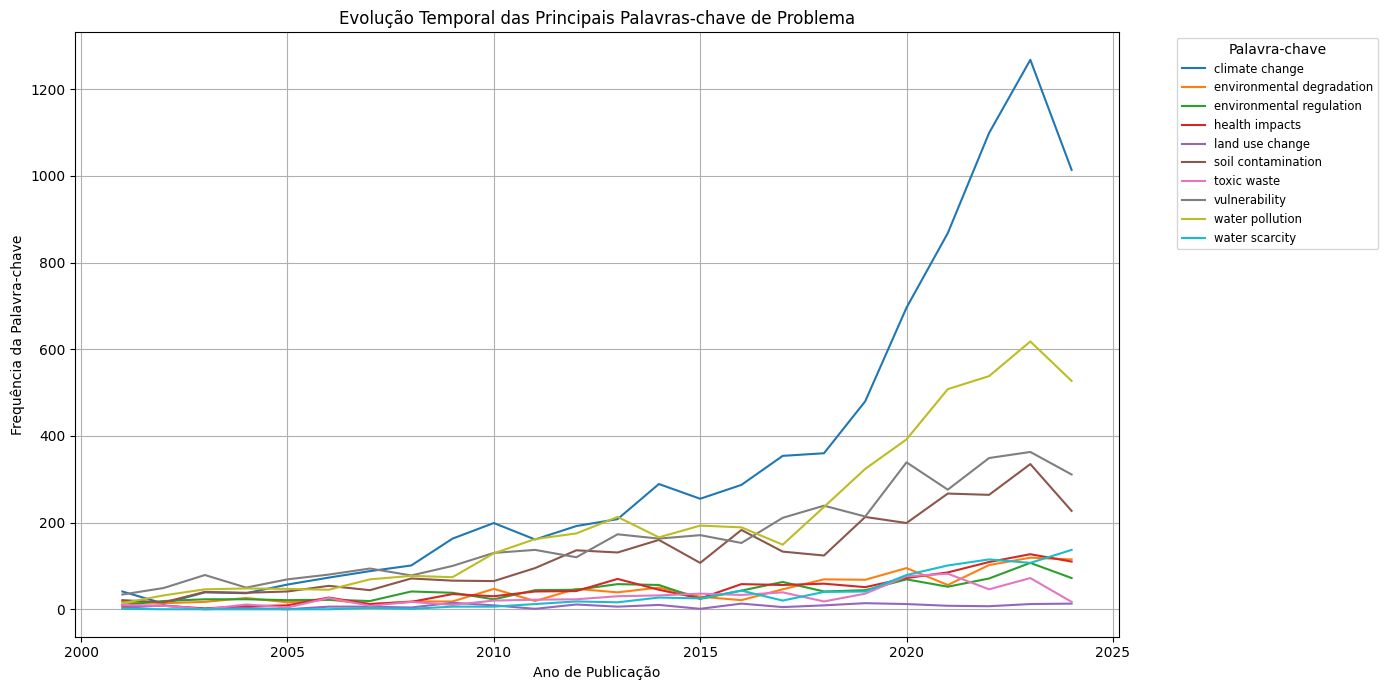

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'problem_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Problema')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Problema

In [ ]:
# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

                         keyword  count  percent
0                 climate change   8342     30.5
1                water pollution   4971     18.2
2                  vulnerability   3982     14.6
3             soil contamination   3030     11.1
4                 health impacts   1105      4.0
5      environmental degradation   1083      4.0
6       environmental regulation   1028      3.8
7                 water scarcity    798      2.9
8                    toxic waste    676      2.5
9                land use change    177      0.6
10              conflict mineral    175      0.6
11                resource curse    163      0.6
12              lithium triangle    158      0.6
13                 dispossession    149      0.5
14                financial risk    128      0.5
15             biodiversity loss    113      0.4
16        environmental conflict    111      0.4
17          public participation     95      0.3
18        human rights violation     88      0.3
19       environment

###Evolução Temporal das Principais Palavras-chave de Conceito

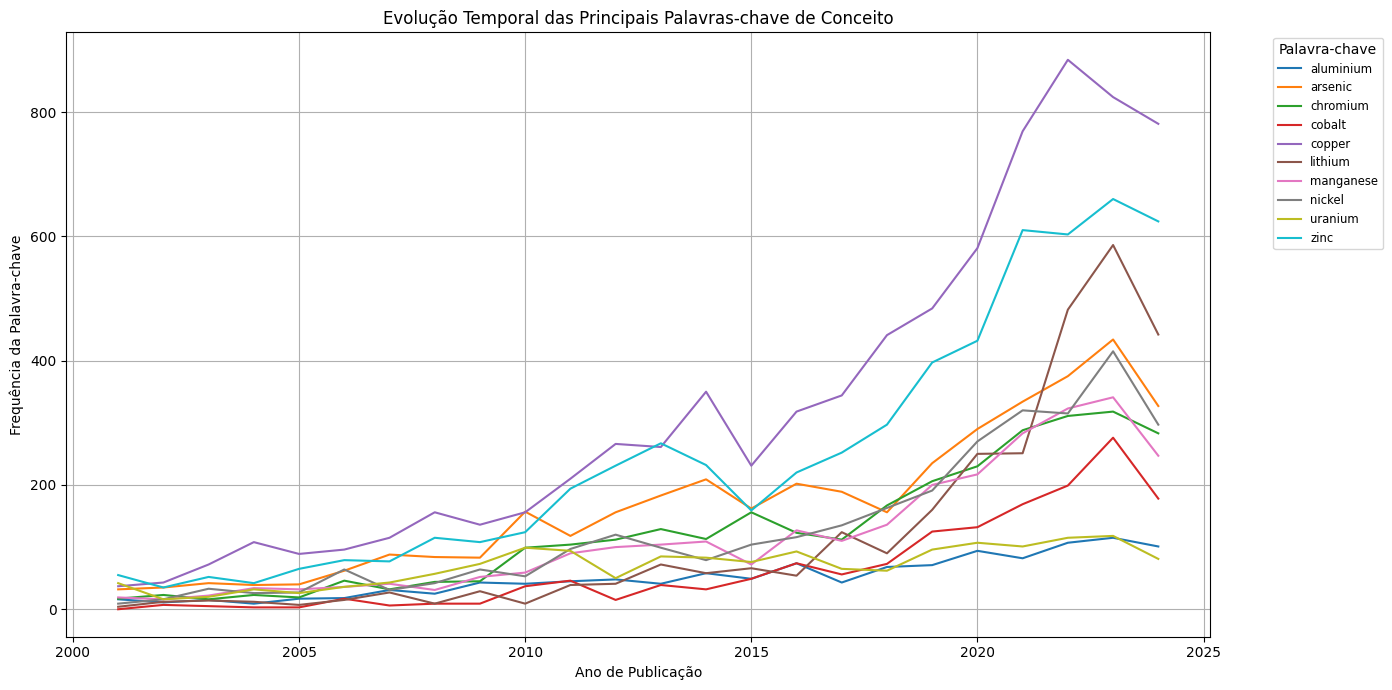

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'concept_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume de kw por área

In [ ]:
import pandas as pd

# Step 1: Calculate total count per field
field_order = (
    df_top10_3.groupby('field')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Step 2: Sort df_top10_3 by field (with custom order) and then by count descending
df_top10_3_sorted = (
    df_top10_3
    .assign(field=pd.Categorical(df_top10_3['field'], categories=field_order, ordered=True))
    .sort_values(by=['field', 'count'], ascending=[True, False])
    .reset_index(drop=True)
)

df_top10_3_sorted

### Consulta de kw para consultar artigos

In [ ]:
from collections import Counter
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Define the keyword to check
keyword_to_check = "epistemic justice"

# Ensure all_keywords is a list
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3["all_keywords"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Filter rows that include the keyword
filtered = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["all_keywords"].apply(lambda x: keyword_to_check in x)
]

# Convert list of keywords to tuple (for grouping), preserving order (or use sorted(x) if order doesn’t matter)
filtered["keyword_combination"] = filtered["all_keywords"].apply(lambda x: tuple(x))

# Group by field and keyword combination
grouped = (
    filtered.groupby(["field", "keyword_combination", "title", "abstract"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Show result
grouped


####Consulta de kw não encontradas

In [ ]:
all_found_problems = set([kw.lower() for sublist in work_ids_a_max_fs_3["problem_kw"] for kw in sublist])
all_found_concepts = set([kw.lower() for sublist in work_ids_a_max_fs_3["concept_kw"] for kw in sublist])

# Quais não foram encontradas?
problems_not_found = sorted(set(problems) - all_found_problems)
concepts_not_found = sorted(set(concepts) - all_found_concepts)

# Mostrar resultados
print("❌ Palavras-chave de 'problems' que não tiveram nenhum match:")
print(problems_not_found)

print("\n❌ Palavras-chave de 'concepts' que não tiveram nenhum match:")
print(concepts_not_found)

##Análise de publicações

###Publicações por área do conhecimento

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada field
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['field', 'count']

# Ordenar por contagem
count_by_field = count_by_field.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa
total = count_by_field['count'].sum()
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['field'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Field')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['field'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Fields e Porcentagem Cumulativa')
plt.show()


###Distribuição de publicação por área ao longo do tempo

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

# Generate distinct colors for each field using Seaborn's color palette
num_fields = len(count_by_year_field_percentage.columns)
colors = sns.color_palette("tab20", num_fields)  # Using 'tab20' for better color distinction

# Plot stacked area chart with improved color distinction
fig, ax = plt.subplots(figsize=(12, 6))
count_by_year_field_percentage.plot(kind='area', stacked=True, ax=ax, color=colors, alpha=0.7)

# Labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Percentage')
ax.set_title('Stacked Percentage of Fields Over the Years')
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

###Publicações por país

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar o número total de ocorrências por país (quantidade de vezes que aparece no dataset)
count_by_country = work_ids_a_max_fs_yr_3['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Manter apenas os 20 países mais frequentes
top_20_countries = count_by_country.head(20).copy()

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)  # Total de linhas no dataset
top_20_countries['cumulative_percentage'] = top_20_countries['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para os 20 principais países
ax1.bar(top_20_countries['country'], top_20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Número de Ocorrências', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top_20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva de porcentagem cumulativa
ax2 = ax1.twinx()
ax2.plot(top_20_countries['country'], top_20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%) em relação ao total do dataset', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais na curva de porcentagem cumulativa
for i, txt in enumerate(top_20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Ocorrências por País e Porcentagem Cumulativa em relação ao Total do Dataset')
plt.show()


###Publicações por instituições

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada institution
count_by_field = work_ids_a_max_fs_yr_3['institution'].value_counts().reset_index()
count_by_field.columns = ['institution', 'count']

# Manter somente os 20 primeiros
count_by_field = count_by_field.head(20)

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['institution'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Institution')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['institution'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['institution'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Institutions e Porcentagem Cumulativa')
plt.show()


In [ ]:
row_count = len(df)
print(f"Total rows in df: {row_count}")

In [ ]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project="insyspo")

In [ ]:
def build_like_clauses(terms, field):
    return "\n                OR ".join([f"LOWER({field}) LIKE '%{term.lower()}%'" for term in terms])

# Use your lists here (make sure `problems` and `concepts` are defined)
problem_display_clause = build_like_clauses(problems, "display_name")
concept_display_clause = build_like_clauses(concepts, "display_name")
problem_abstract_clause = build_like_clauses(problems, "abstract")
concept_abstract_clause = build_like_clauses(concepts, "abstract")

query = f"""
DROP TABLE IF EXISTS `insyspo.userdb_fernando_spolidorio.cm_work_ids_3`;

CREATE TABLE `insyspo.userdb_fernando_spolidorio.cm_work_ids_3` AS (
    SELECT DISTINCT id
    FROM (
        SELECT id
        FROM `insyspo.publicdb_openalex_2024_10_rm.works`
        WHERE (
            {problem_display_clause}
        )
        AND (
            {concept_display_clause}
        )
        UNION ALL
        SELECT id
        FROM `insyspo.projectdb_cwts_summer_school_2023.works_abstracts`
        WHERE (
            {problem_abstract_clause}
        )
        AND (
            {concept_abstract_clause}
        )
    )
);
"""

In [ ]:
# Execute the query
job = client.query(query)
job.result()  # Wait for completion
print("Query completed and table created.")

#Busca 2: Conceitos + Contexto

##Coleta de dados da OpenAlex

###Extração de IDs



In [295]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project="insyspo")

In [296]:
context = ["energy transition", "climate change"]
problems = []
problems2 = [
    "community displacement", "forced relocation", #"basic materials"
    "land use change",
    "lithium triangle", "expropriation",
    "climate vulnerability", "biodiversity loss", "water pollution", "environmental conflict",
    "mining conflict", "resource conflict", "socio-environmental conflict",
    #"energy transition",
    #"renewab", "energy justice", "decarbon",
    #"sustainable supply", "low-carbon transition", "clean energy", "green energy",
    #"sustainable energy", "carbon neutral", "net zero", "carbon reduc", "carbon mitigat",
    #"energy secur", "climate resilien", "energy resilien", "resource sustainab",
    #"sustainable develop", "resource efficien",
    "just transition", "epistemic justice", "climate coloniality", "green sacrifice zone",
    "dispossession", "neoextractivism", "environmental degradation", "governance gap",
    "extractive frontier", "resource curse", "mineral governance", "environmental injustice",
    "environmental violence", "technological dependence", "inclusion gap",
    "climate risk", "financial risk", "transition risk", "environmental liability",
    "social license to operate", "resource nationalism", "regulatory uncertainty",
    "environmental regulation", "corporate accountability", "conflict mineral",
    "human rights", "environmental activism", "indigenous territory", "land rights",
    "cultural erosion", "territorial conflict", "conflict over resources", "community resistance",
    "environmental defender", "livelihood disruption", "public participation", "prior consultation",
    "traditional knowledge", "water scarcity", "soil contamination", "toxic waste",
    "ecosystem degradation", "health impacts", "social exclusion", "regulatory capture",
    "climate injustice"
    # "displacement",
    # "territorial dispossession",
    # "land grabbing",
    # "water source",
    # "biodiversity",
    # "extractive conflict",
    # "extractive industry conflict",
    # "transition justice",
    # "social displacement",
    # "asymmetrical trade",
    # "commodity dependence",
    # "extractive dependency",
    # "carbon footprint shift",
    # "knowledge marginalization",
    # "governance failure",
    # "policy misalignment",
    # "community resistance",
    # "territorial justice",
    # "climate litigation",
    "green colonialism",
    "mineral dependency",
    #"mineral sovereignty",
    "green capitalism",
    "green finance",
    "sacrifice zone",
    "climate justice",
    "greenwashing",
    "technological dependency",
    "sustainable finance",
    "green extractivism",
    "global value chain",
    "productive chain",
    "resource gov"
]

concepts = [
    "critical mineral",
    "critical metal",
    "critical material",
    "critical raw material",
    "strategic mineral",
    "strategic material",
    "key raw material",
    "rare metal",
    "green transition mineral",
    "green transition metal",
    "green transition material",
    "green transition raw material",
    #"strategic metal",
    "rare earth element",
    "battery metal",
    #"transition metal",
    #"mineral resource",
    "raw material dependenc",
    # "high-demand mineral",
    # "high-demand metal",
    #"material scarci",
    #"resource scarci",
    # "metal sustainab",
    #"mineral sustainab",
    #"resource critical",
    #"material critical",
    "aluminium", "antimony", "arsenic", "barite", "beryllium",
    "bismuth", "cerium", "cesium", "chromium", "cobalt", "dysprosium", "erbium", "europium", "fluorspar",
    "gadolinium", "gallium", "germanium", "graphite", "hafnium", "holmium", "indium", "iridium",
    "lanthanum", "lithium", "lutetium",
    #"magnesium",
    "manganese", "neodymium", "nickel", "niobium",
    "palladium", "platinum", "praseodymium", "rhodium", "rubidium", "ruthenium", "samarium",
    "scandium", "tantalum", "tellurium", "terbium", "thulium", "titanium", "tungsten",
    "uranium", "vanadium", "ytterbium", "yttrium", "zinc", "zirconium", "copper",
    #"clean tech",
    #"critical supply chain",
    #"supply chain vulnerability",
    "rare earth",
    #"battery supply chain",
    "energy storage material"
    #"strategic resource",
    #"low-carbon technology",
    # "raw material governance",
    #"sustainable mining",
    #"circular mining",
    #"secondary sourcing",
    #"geopolitical risk",
    # "critical material recycling",
    #"resource diplomacy",
    #"local content policy",
    #"net-zero strategy",
    #"carbon-neutral technology",
    #"renewable infrastructure"
]

def build_like_clauses(terms, field):
    if not terms:
        return ""
    return "\n                OR ".join([f"LOWER({field}) LIKE '%{term.lower()}%'" for term in terms])

# Build clauses
problem_display_clause = build_like_clauses(problems, "display_name")
concept_display_clause = build_like_clauses(concepts, "display_name")
context_display_clause = build_like_clauses(context, "display_name")

problem_abstract_clause = build_like_clauses(problems, "abstract")
concept_abstract_clause = build_like_clauses(concepts, "abstract")
context_abstract_clause = build_like_clauses(context, "abstract")

def make_where_clause(problem_clause, concept_clause, context_clause):
    clauses = []
    if problem_clause:
        clauses.append(f"({problem_clause})")
    if concept_clause:
        clauses.append(f"({concept_clause})")
    if context_clause:
        clauses.append(f"({context_clause})")
    return " AND ".join(clauses) if clauses else "TRUE"

works_where = make_where_clause(problem_display_clause, concept_display_clause, context_display_clause)
abstract_where = make_where_clause(problem_abstract_clause, concept_abstract_clause, context_abstract_clause)

query = f"""
DROP TABLE IF EXISTS `insyspo.userdb_fernando_spolidorio.cm_work_ids_3`;

CREATE TABLE `insyspo.userdb_fernando_spolidorio.cm_work_ids_3` AS (
    SELECT DISTINCT id
    FROM (
        SELECT id
        FROM `insyspo.publicdb_openalex_2024_10_rm.works`
        WHERE {works_where}
        UNION ALL
        SELECT id
        FROM `insyspo.projectdb_cwts_summer_school_2023.works_abstracts`
        WHERE {abstract_where}
    )
);
"""


In [297]:
# Execute the query
job = client.query(query)
job.result()  # Wait for completion
print("Query completed and table created.")

Query completed and table created.


In [298]:
%%bigquery work_ids_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_3

Query is running:   0%|          |

Downloading:   0%|          |

In [299]:
len(work_ids_3)

6175

###Filtros

####Artigos e anos

In [300]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS (

SELECT a.id, b.doi, b.title, b.type, b.publication_year
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works AS b ON a.id = b.id
WHERE b.type = 'article' and b.publication_year > 2000 and b.publication_year < 2025
);

Query is running:   0%|          |

""


In [301]:
%%bigquery work_ids_a_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3

Query is running:   0%|          |

Downloading:   0%|          |

In [302]:
len(work_ids_a_3)

3912

####Maxscores

In [303]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS (

WITH MaxScores AS (
    SELECT a.*, MAX(b.score) AS max_score
    FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS a
    JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
    GROUP BY all
)

select * from maxscores

)


Query is running:   0%|          |

""


In [304]:
%%bigquery work_ids_a_max_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3

Query is running:   0%|          |

Downloading:   0%|          |

In [305]:
len(work_ids_a_max_3)

3888

In [306]:
work_ids_a_max_3

,id,doi,title,type,publication_year,max_score
0,1543074366,10.5860/choice.38-4218,Nuclear power: a reference handbook,article,2001,0.8770
1,2014598440,10.1097/00001648-200103000-00025,Update on World Health Organization’s Initiative to Assess Environmental Burden of Disease,article,2001,0.9905
2,2010971088,10.1063/1.1397391,Bush Sends Mixed Science Signals,article,2001,0.9064
3,1985219072,10.1088/0952-4746/21/1/614,"Meeting of the OSPAR CommissionCopenhagen, 26-30 June 2000",article,2001,0.9916
4,2188423139,None,BRAZILIAN EFFORTS TOWARDS REDUCING GREENHOUSE GAS EMISSIONS IN THE TRANSPORT SECTOR AND IN THE ENERGY INTENSIVE INDUSTRY,article,2001,0.9344
...,...,...,...,...,...,...
3883,4402140160,10.1007/s11367-024-02355-1,Cradle-to-gate life cycle assessment of cylindrical sulfide-based solid-state batteries,article,2024,1.0000
3884,4394617069,10.4271/2024-01-2670,Procedures for Experimental Characterization of Thermal Properties in Li-Ion Battery Modules and Parameters Identification for Thermal Models,article,2024,1.0000
3885,4394711243,10.1109/access.2024.3387748,Hierarchical Energy Management of Hybrid Battery Storage Systems for PV Capacity Firming and Spot Market Trading Considering Degradation Costs,article,2024,1.0000
3886,4391797216,10.1016/j.jpowsour.2024.234140,Low platinum fuel cell as enabler for the hydrogen fuel cell vehicle,article,2024,1.0000


###Fields & subfields

In [334]:
%%bigquery work_ids_a_max_fs_3 --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country, h.work_id
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [335]:
len(work_ids_a_max_fs_3)

44039

In [336]:
# Drop duplicates keeping the first row for each id
work_ids_a_max_fs_3 = work_ids_a_max_fs_3.drop_duplicates(subset=['id','topic', 'field','subfield'])

In [337]:
len(work_ids_a_max_fs_3)

7939

## Análise de palavras-chaves identificadas

###Criação de colunas

####Criação das colunas problems_kw e concept_kw

In [339]:
import pandas as pd
import re

# --- 2. Exceções para match exato ---
exact_match_words = {"tin", "lead"}

# --- 3. Função de extração robusta ---
def extract_keywords(text, keywords, exact_match_words):
    if pd.isna(text):
        return []
    text = text.lower()
    found = []
    for kw in keywords:
        kw_lc = kw.lower().strip()
        if kw_lc in exact_match_words:
            if re.search(rf'\b{re.escape(kw_lc)}\b', text):
                found.append(kw)
        else:
            if kw_lc in text:
                found.append(kw)
    return list(dict.fromkeys(found))

# --- 4. Normalizar listas ---
problems = [p.lower().strip() for p in problems]
concepts = [c.lower().strip() for c in concepts]
contexts = [c.lower().strip() for c in context]  # Adicionado para contexts

# --- 5. Aplicar no DataFrame ---
work_ids_a_max_fs_3["problem_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], problems, exact_match_words) +
                extract_keywords(row["abstract"], problems, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["concept_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], concepts, exact_match_words) +
                extract_keywords(row["abstract"], concepts, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["context_kw"] = work_ids_a_max_fs_3.apply(  # Novo para contexts
    lambda row: extract_keywords(row["title"], context, exact_match_words) +
                extract_keywords(row["abstract"], context, exact_match_words),
    axis=1
)

# --- 6. Identificar casos problemáticos ---
no_concept_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["concept_kw"].apply(lambda x: len(x) == 0)
]

no_problem_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["problem_kw"].apply(lambda x: len(x) == 0)
]

no_context_rows = work_ids_a_max_fs_3[  # Novo para contexts
    work_ids_a_max_fs_3["context_kw"].apply(lambda x: len(x) == 0)
]

print("⚠️ Registros com ZERO conceitos detectados:", len(no_concept_rows))
print("⚠️ Registros com ZERO problemas detectados:", len(no_problem_rows))
print("⚠️ Registros com ZERO contextos detectados:", len(no_context_rows))


⚠️ Registros com ZERO conceitos detectados: 0
⚠️ Registros com ZERO problemas detectados: 7939
⚠️ Registros com ZERO contextos detectados: 0


####Criação da coluna all_keywords

In [340]:
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3.apply(
    lambda row: sorted(set(row["problem_kw"] + row["concept_kw"] + row["context_kw"])),
    axis=1)

work_ids_a_max_fs_3.head()

id                            doi  \
0   4289260921    10.1016/j.egyai.2022.100194   
2   4289260921    10.1016/j.egyai.2022.100194   
4   4289260921    10.1016/j.egyai.2022.100194   
6   2897730956  10.1016/s2542-5196(18)30189-x   
13  2897730956  10.1016/s2542-5196(18)30189-x   

                                                                                                title  \
0   Hybrid data-based modeling for the prediction and diagnostics of Li-ion battery thermal behaviors   
2   Hybrid data-based modeling for the prediction and diagnostics of Li-ion battery thermal behaviors   
4   Hybrid data-based modeling for the prediction and diagnostics of Li-ion battery thermal behaviors   
6       New Initiative aims at expanding Global Burden of Disease estimates for pollution and climate   
13      New Initiative aims at expanding Global Burden of Disease estimates for pollution and climate   

       type  publication_year  max_score  \
0   article              2022     1.0000   
2   article              2022     1.0000   
4   article              2022     1.0000   
6   article              2018     0.9996   
13  article              2018     0.9996   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

###20 combinações de kw mais comuns por área do conhecimento

In [341]:
df=work_ids_a_max_fs_3
df["all_keywords"] = df["all_keywords"].apply(lambda x: tuple(x))  # Convert lists to tuples

df_grouped = (
    df.groupby(["field", "all_keywords"])
    .size()
    .reset_index(name="count")
)

# Get top 10 counts per field
df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))

df_top10_3


/tmp/ipython-input-341-3636565974.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))


,field,all_keywords,count
42,Agricultural and Biological Sciences,"(climate change, zinc)",258
14,Agricultural and Biological Sciences,"(climate change, copper)",90
0,Agricultural and Biological Sciences,"(aluminium, climate change)",48
28,Agricultural and Biological Sciences,"(climate change, manganese)",39
20,Agricultural and Biological Sciences,"(climate change, copper, manganese, zinc)",29
...,...,...,...
1681,Social Sciences,"(climate change, critical raw material, energy transition)",3
1683,Social Sciences,"(climate change, energy transition, lithium)",3
1710,Social Sciences,"(critical mineral, energy transition, rare earth, rare earth element)",3
1721,Veterinary,"(chromium, climate change)",1


###Volume e representatividade de palavras-chaves de Problema



In [342]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['problem_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

      keyword  count  percent
0         NaN      1      0.0
1         NaN      1      0.0
2         NaN      1      0.0
3         NaN      1      0.0
4         NaN      1      0.0
5         NaN      1      0.0
6         NaN      1      0.0
7         NaN      1      0.0
8         NaN      1      0.0
9         NaN      1      0.0
10        NaN      1      0.0
11        NaN      1      0.0
12        NaN      1      0.0
13        NaN      1      0.0
14        NaN      1      0.0
15        NaN      1      0.0
16        NaN      1      0.0
17        NaN      1      0.0
18        NaN      1      0.0
19        NaN      1      0.0
20        NaN      1      0.0
21        NaN      1      0.0
22        NaN      1      0.0
23        NaN      1      0.0
24        NaN      1      0.0
25        NaN      1      0.0
26        NaN      1      0.0
27        NaN      1      0.0
28        NaN      1      0.0
29        NaN      1      0.0
30        NaN      1      0.0
31        NaN      1      0.0
32        

###Evolução Temporal das Principais Palavras-chave de Problema

/tmp/ipython-input-343-3296750448.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


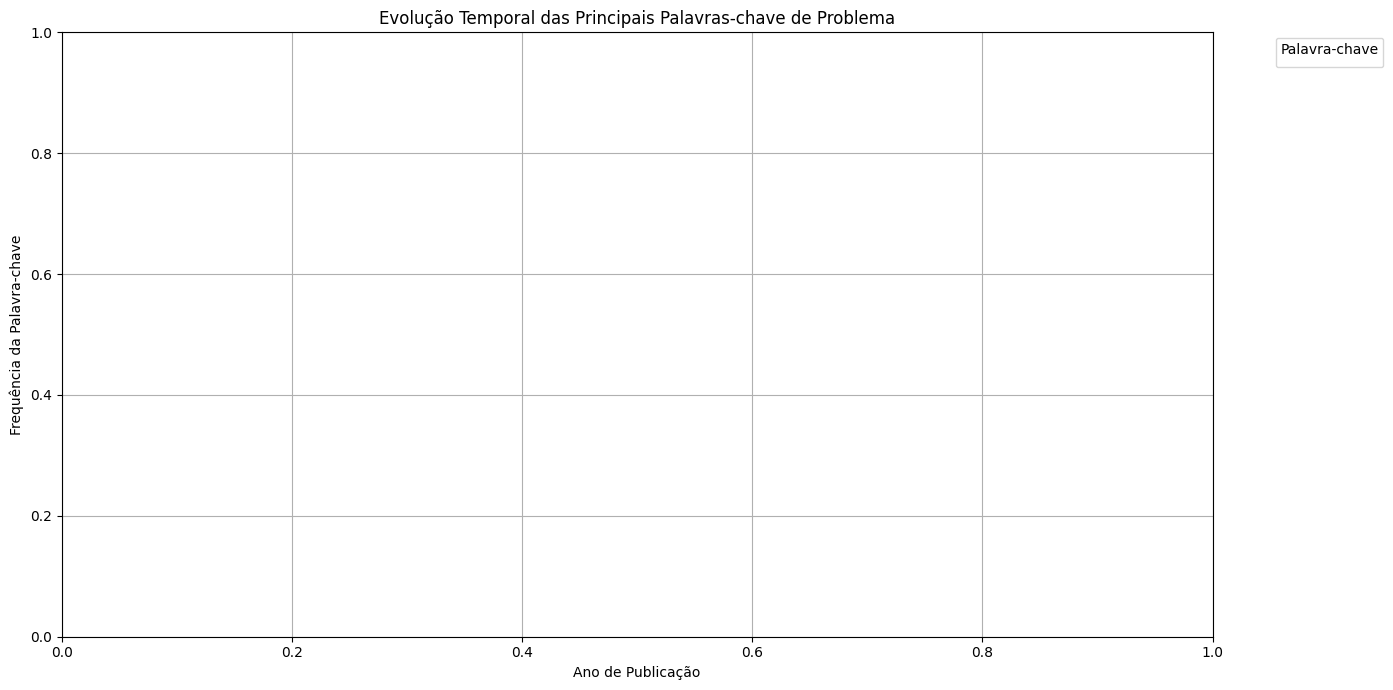

In [343]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'problem_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Problema')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Conceitos

In [344]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['concept_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

                    keyword  count  percent
0                   lithium   1895     13.3
1                    copper   1835     12.9
2                      zinc   1288      9.0
3                    nickel    837      5.9
4                 manganese    679      4.8
5                    cobalt    635      4.5
6                rare earth    587      4.1
7                   uranium    581      4.1
8                   arsenic    524      3.7
9                 aluminium    451      3.2
10                 platinum    407      2.9
11       rare earth element    392      2.7
12                 titanium    313      2.2
13         critical mineral    310      2.2
14                 graphite    301      2.1
15                 chromium    236      1.7
16                 vanadium    201      1.4
17    critical raw material    185      1.3
18           critical metal    158      1.1
19                   indium    154      1.1
20                palladium    152      1.1
21                ruthenium    1

###Evolução Temporal das Principais Palavras-chave de Conceito

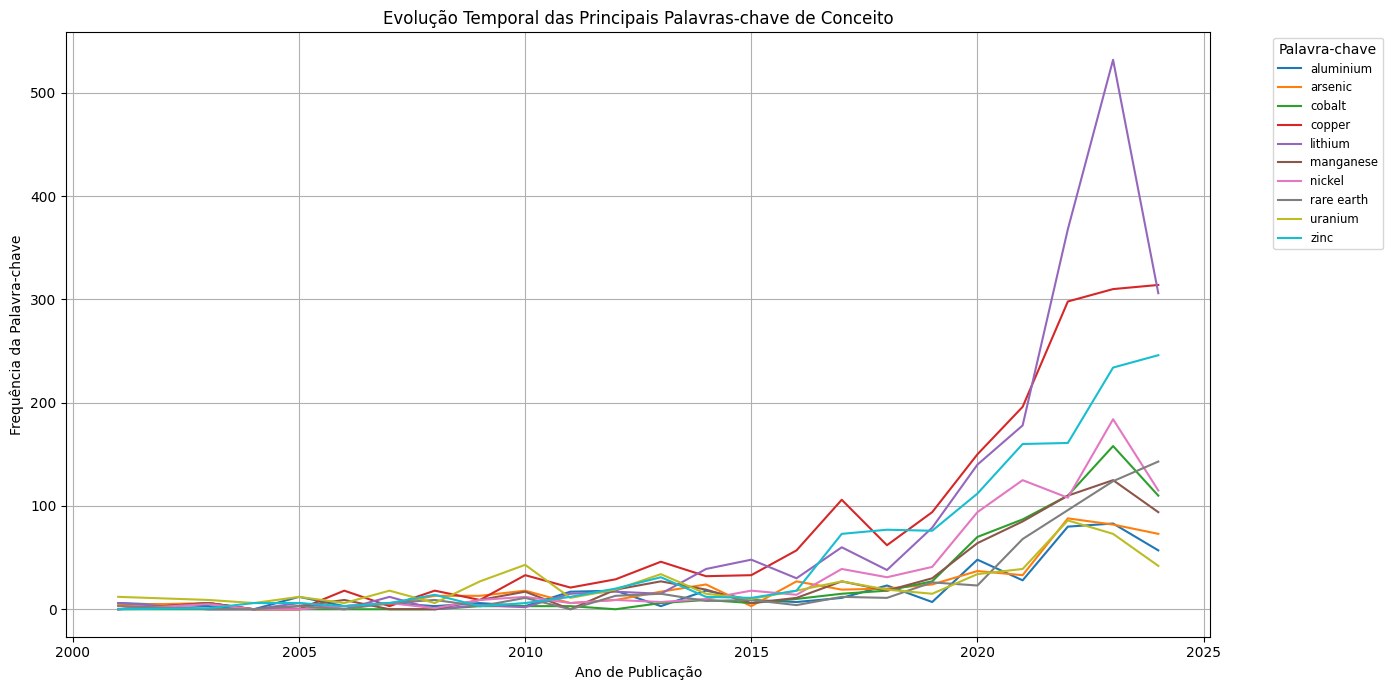

In [345]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'concept_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Contexto

In [346]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['context_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

             keyword  count  percent
0     climate change   6469     74.6
1  energy transition   2206     25.4


###Evolução Temporal das Principais Palavras-chave de Conceito

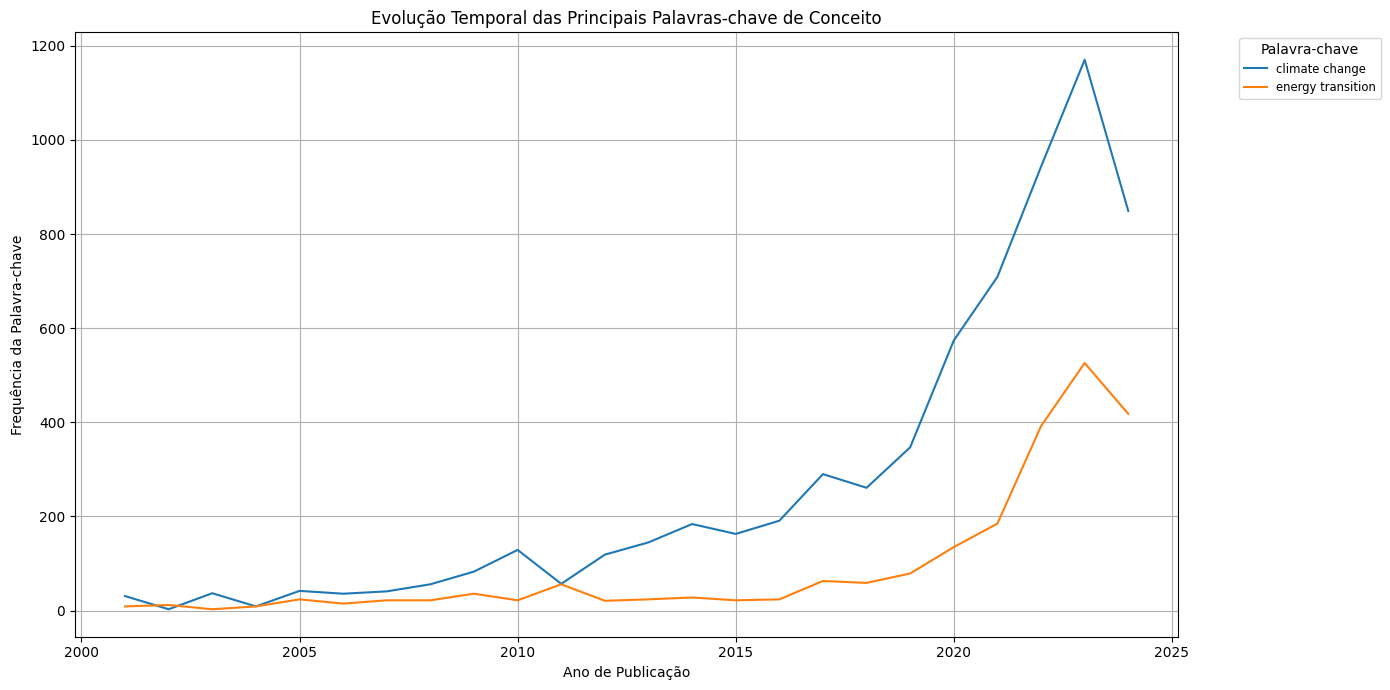

In [347]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'context_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume de kw por área

In [348]:
import pandas as pd

# Step 1: Calculate total count per field
field_order = (
    df_top10_3.groupby('field')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Step 2: Sort df_top10_3 by field (with custom order) and then by count descending
df_top10_3_sorted = (
    df_top10_3
    .assign(field=pd.Categorical(df_top10_3['field'], categories=field_order, ordered=True))
    .sort_values(by=['field', 'count'], ascending=[True, False])
    .reset_index(drop=True)
)

df_top10_3_sorted

,field,all_keywords,count
0,Engineering,"(climate change, lithium)",426
1,Engineering,"(energy transition, lithium)",176
2,Engineering,"(climate change, copper)",101
3,Engineering,"(aluminium, climate change)",69
4,Engineering,"(copper, energy transition)",47
...,...,...,...
373,Veterinary,"(climate change, platinum)",1
374,Neuroscience,"(climate change, copper, nickel)",1
375,Neuroscience,"(climate change, indium)",1
376,Dentistry,"(aluminium, climate change)",1


###Consulta de kw para consultar artigos

####Consulta de kw não encontradas

In [349]:
all_found_problems = set([kw.lower() for sublist in work_ids_a_max_fs_3["problem_kw"] for kw in sublist])
all_found_concepts = set([kw.lower() for sublist in work_ids_a_max_fs_3["concept_kw"] for kw in sublist])
all_found_context = set([kw.lower() for sublist in work_ids_a_max_fs_3["context_kw"] for kw in sublist])

# Quais não foram encontradas?
problems_not_found = sorted(set(problems) - all_found_problems)
concepts_not_found = sorted(set(concepts) - all_found_concepts)
context_not_found = sorted(set(context) - all_found_context)

# Mostrar resultados
print("❌ Palavras-chave de 'problems' que não tiveram nenhum match:")
print(problems_not_found)

print("\n❌ Palavras-chave de 'concepts' que não tiveram nenhum match:")
print(concepts_not_found)

print("\n❌ Palavras-chave de 'context' que não tiveram nenhum match:")
print(context_not_found)

❌ Palavras-chave de 'problems' que não tiveram nenhum match:
[]

❌ Palavras-chave de 'concepts' que não tiveram nenhum match:
['fluorspar', 'green transition material', 'green transition metal', 'green transition mineral', 'green transition raw material', 'holmium', 'raw material dependenc']

❌ Palavras-chave de 'context' que não tiveram nenhum match:
[]


In [350]:
from collections import Counter
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Define the keyword to check
keyword_to_check = "epistemic justice"

# Ensure all_keywords is a list
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3["all_keywords"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Filter rows that include the keyword
filtered = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["all_keywords"].apply(lambda x: keyword_to_check in x)
]

# Convert list of keywords to tuple (for grouping), preserving order (or use sorted(x) if order doesn’t matter)
filtered["keyword_combination"] = filtered["all_keywords"].apply(lambda x: tuple(x))

# Group by field and keyword combination
grouped = (
    filtered.groupby(["field", "keyword_combination", "title", "abstract"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Show result
grouped


,field,keyword_combination,title,abstract,count


##Análise de publicações

###Publicações por área do conhecimento

/tmp/ipython-input-351-3132261924.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')


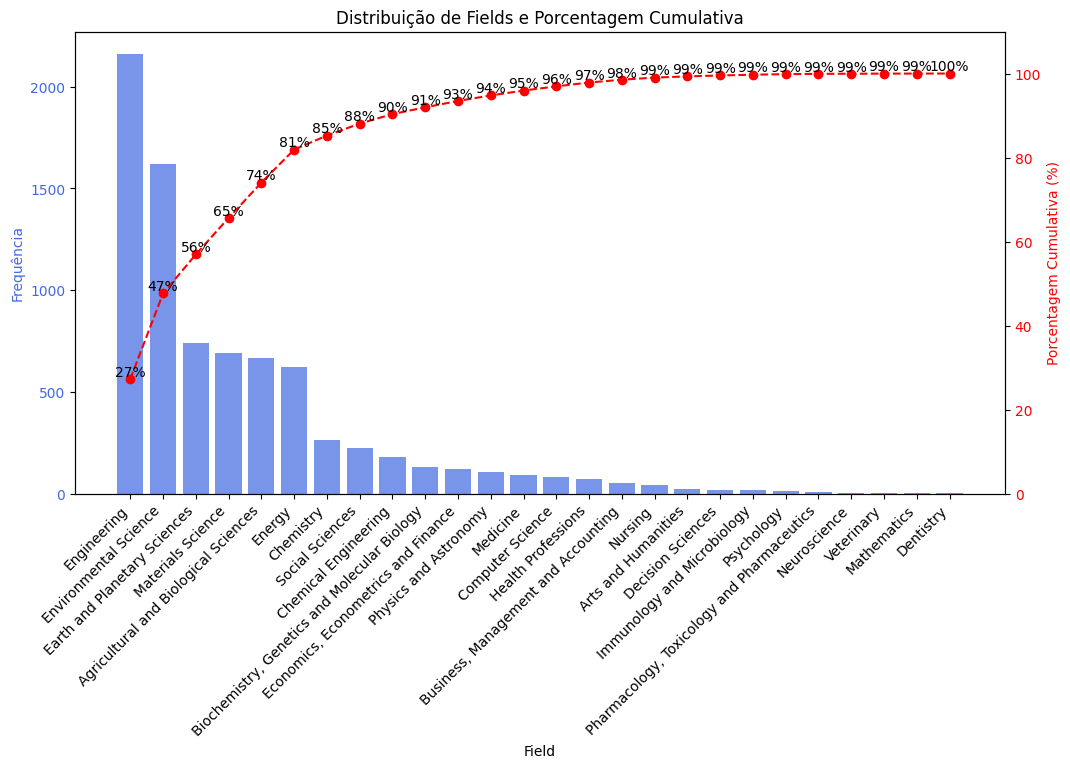

In [351]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada field
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['field', 'count']

# Ordenar por contagem
count_by_field = count_by_field.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa
total = count_by_field['count'].sum()
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['field'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Field')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['field'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Fields e Porcentagem Cumulativa')
plt.show()


####Publicações por área (df)

In [352]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['Área do conhecimento', 'Contagem']

# Exibir o DataFrame
count_by_field

,Área do conhecimento,Contagem
0,Engineering,2163
1,Environmental Science,1618
2,Earth and Planetary Sciences,738
3,Materials Science,690
4,Agricultural and Biological Sciences,668
5,Energy,624
6,Chemistry,265
7,Social Sciences,226
8,Chemical Engineering,180
9,"Biochemistry, Genetics and Molecular Biology",128


In [353]:
%%bigquery work_ids_a_max_fs_3_t --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country

FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [354]:
work_ids_a_max_fs_3_t

,id,doi,title,type,publication_year,max_score,abstract,topic,field,subfield,country
0,4318474832,10.36948/ijfmr.2023.v05i01.1468,Zinc Oxide Nanoparticles in Alleviation of Toxicity Induced by Heat Stress in Plants,article,2023,0.9439,"Climate change-related abiotic pressures have an impact on plant development and yield, which decreases the amount of food produced. High temperature (HT) stress has a large worldwide impact on plant development, metabolism, and productivity. The growth and development of plants involves numerous temperature-sensitive metabolic processes. The widespread practices of producing crops in polluted surroundings is currently environmentalists' top worry. So, in order to maintain high crop yields under HT stress, which is currently a key worry for crop production, it is vital for agriculture to develop various strategies. A current relevant technology for enhancing food production and ensuring sustainability in the pursuit of food safety is highly developed nanotechnology. Nanotechnology boosts agricultural productivity by improving input effectiveness and reducing relevant losses. This review looks at earlier studies that show how zinc oxide nanoparticles (ZnO-NPs) can mitigate the negative effects of heat stress. ZnO-NPs application is the most effective method available globally to greatly boost agricultural output in challenging settings. With the aid of a number of cutting-edge technologies for reversing the symptoms of oxidative stress brought on by heat stress, ZnO-NPs can revolutionize the agricultural and food industries. The impact of ZnO-NPs on the physiological, antioxidative and biochemical activities in different plants has also been thoroughly studied. This review summarizes the current understanding and future perspectives of plant-ZnO-NPs research.",Impacts of Elevated CO2 and Ozone on Plant Physiology,Agricultural and Biological Sciences,Plant Science,India
1,4318474832,10.36948/ijfmr.2023.v05i01.1468,Zinc Oxide Nanoparticles in Alleviation of Toxicity Induced by Heat Stress in Plants,article,2023,0.9439,"Climate change-related abiotic pressures have an impact on plant development and yield, which decreases the amount of food produced. High temperature (HT) stress has a large worldwide impact on plant development, metabolism, and productivity. The growth and development of plants involves numerous temperature-sensitive metabolic processes. The widespread practices of producing crops in polluted surroundings is currently environmentalists' top worry. So, in order to maintain high crop yields under HT stress, which is currently a key worry for crop production, it is vital for agriculture to develop various strategies. A current relevant technology for enhancing food production and ensuring sustainability in the pursuit of food safety is highly developed nanotechnology. Nanotechnology boosts agricultural productivity by improving input effectiveness and reducing relevant losses. This review looks at earlier studies that show how zinc oxide nanoparticles (ZnO-NPs) can mitigate the negative effects of heat stress. ZnO-NPs application is the most effective method available globally to greatly boost agricultural output in challenging settings. With the aid of a number of cutting-edge technologies for reversing the symptoms of oxidative stress brought on by heat stress, ZnO-NPs can revolutionize the agricultural and food industries. The impact of ZnO-NPs on the physiological, antioxidative and biochemical activities in different plants has also been thoroughly studied. This review summarizes the current understanding and future perspectives of plant-ZnO-NPs research.",Impacts of Elevated CO2 and Ozone on Plant Physiology,Agricultural and Biological Sciences,Plant Science,India
2,1975213188,10.1080/08940886.2014.952207,Experiments and Theory of In situ and Operando Soft X-ray Spectroscopy for Energy Storage,article,2014,0.9999,"Energy and environment are at the heart of modern societal concerns

/tmp/ipython-input-355-3013633053.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')


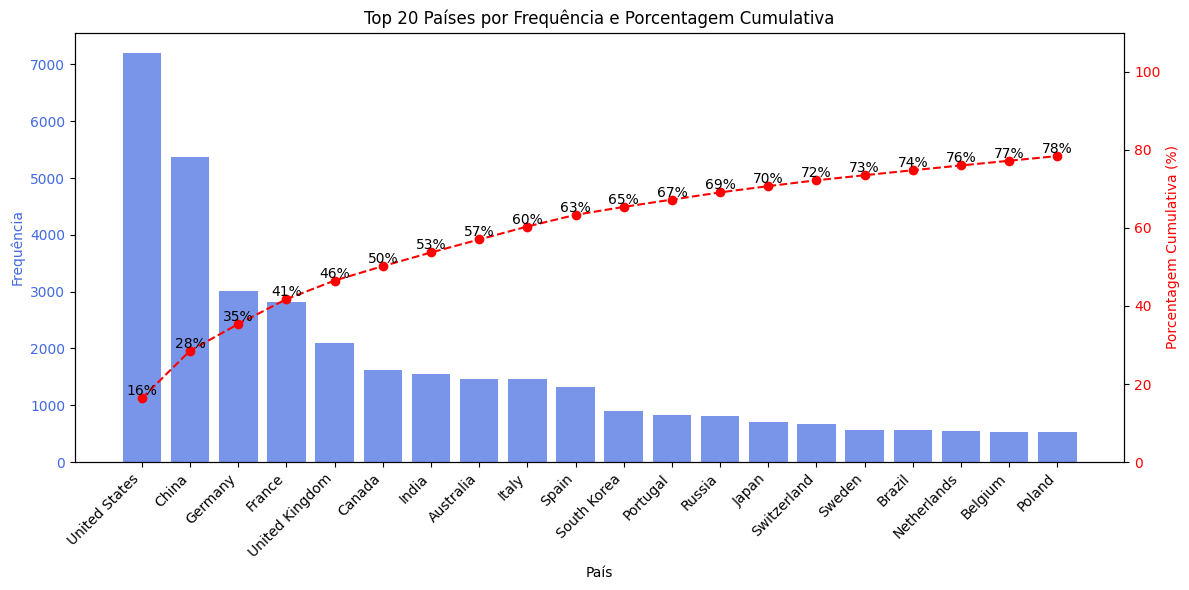

In [355]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada país
count_by_country = work_ids_a_max_fs_3_t['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']

# Ordenar por contagem
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa (baseada no total geral)
total = count_by_country['count'].sum()
count_by_country['cumulative_percentage'] = count_by_country['count'].cumsum() / total * 100

# Selecionar os 20 países com maior contagem para exibição
top20_countries = count_by_country.head(20)

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(top20_countries['country'], top20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(top20_countries['country'], top20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(top20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Top 20 Países por Frequência e Porcentagem Cumulativa')
plt.tight_layout()
plt.show()

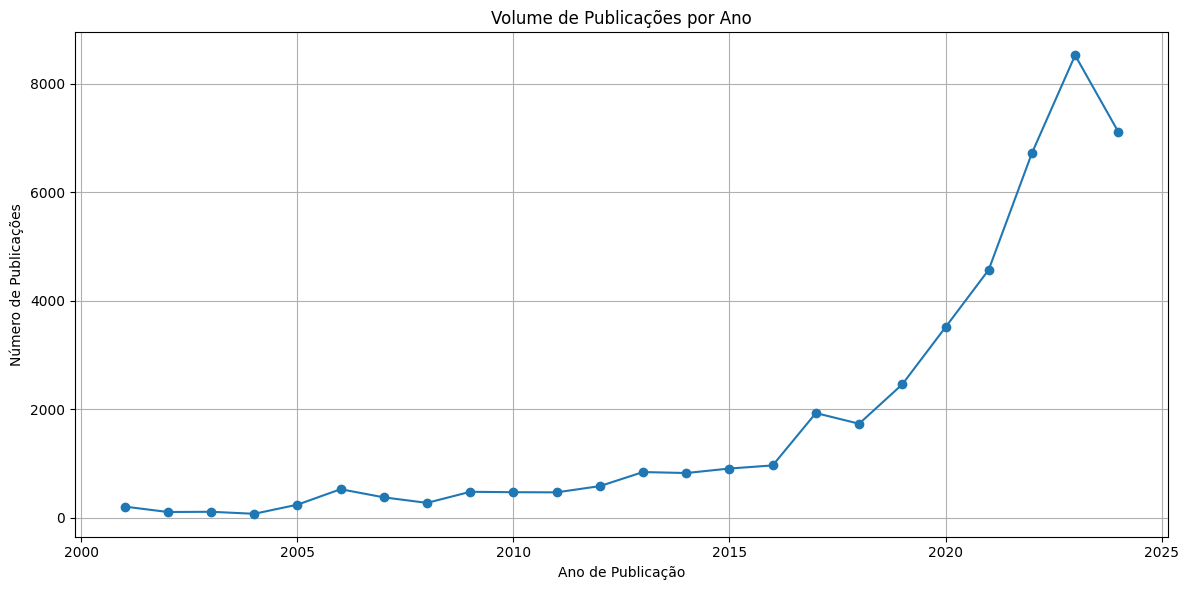

In [356]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar publicações por ano
publications_per_year = work_ids_a_max_fs_3_t['publication_year'].value_counts().reset_index()
publications_per_year.columns = ['publication_year', 'count']
publications_per_year = publications_per_year.sort_values(by='publication_year')

# Criar gráfico de linha
plt.figure(figsize=(12, 6))
plt.plot(publications_per_year['publication_year'], publications_per_year['count'], marker='o', linestyle='-')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Volume de Publicações por Ano')
plt.grid(True)
plt.tight_layout()
plt.show()

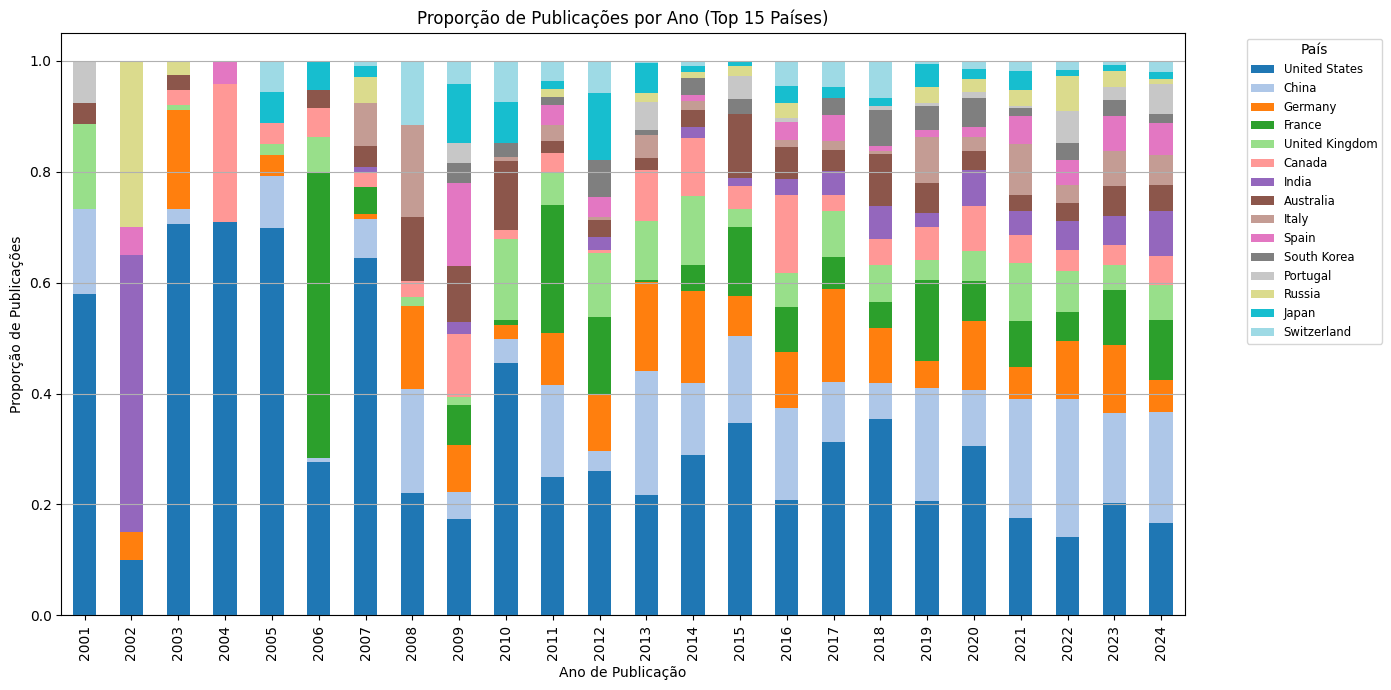

In [357]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3_t = pd.read_csv('seu_arquivo.csv')

# Agrupar por ano e país
publications_by_year_country = (
    work_ids_a_max_fs_3_t
    .groupby(['publication_year', 'country'])
    .size()
    .reset_index(name='count')
)

# Selecionar os 20 países com mais publicações no total
top_countries = (
    publications_by_year_country.groupby('country')['count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Filtrar apenas esses países
filtered_df = publications_by_year_country[publications_by_year_country['country'].isin(top_countries)]

# Pivotar: linhas = ano, colunas = país, valores = contagem
pivot_table = filtered_df.pivot(
    index='publication_year',
    columns='country',
    values='count'
).fillna(0).sort_index()

# Ordenar colunas com os países mais produtivos na base
ordered_columns = pivot_table.sum().sort_values(ascending=False).index
pivot_table = pivot_table[ordered_columns]

# Normalizar por linha para criar gráfico 100% empilhado
pivot_relative = pivot_table.div(pivot_table.sum(axis=1), axis=0)

# Plotar gráfico de barras empilhadas relativas
pivot_relative.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)

plt.xlabel('Ano de Publicação')
plt.ylabel('Proporção de Publicações')
plt.title('Proporção de Publicações por Ano (Top 15 Países)')
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [358]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['publication_year'].value_counts().reset_index()
count_by_field.columns = ['Ano de publicação', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

    Ano de publicação  Contagem
0                2023      1526
1                2022      1209
2                2024      1160
3                2021       813
4                2020       655
5                2019       384
6                2017       333
7                2018       300
8                2016       196
9                2014       191
10               2015       171
11               2013       155
12               2010       137
13               2012       134
14               2009       118
15               2011       107
16               2008        75
17               2007        60
18               2005        57
19               2006        51
20               2003        40
21               2001        34
22               2004        18
23               2002        15


###Distribuição de publicação por área ao longo do tempo

In [359]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

# Generate distinct colors for each field using Seaborn's color palette
num_fields = len(count_by_year_field_percentage.columns)
colors = sns.color_palette("tab20", num_fields)  # Using 'tab20' for better color distinction

# Plot stacked area chart with improved color distinction
fig, ax = plt.subplots(figsize=(12, 6))
count_by_year_field_percentage.plot(kind='area', stacked=True, ax=ax, color=colors, alpha=0.7)

# Labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Percentage')
ax.set_title('Stacked Percentage of Fields Over the Years')
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

NameError: name 'count_by_year_field_percentage' is not defined

###Publicações por país

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar o número total de ocorrências por país (quantidade de vezes que aparece no dataset)
count_by_country = work_ids_a_max_fs_3['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Manter apenas os 20 países mais frequentes
top_20_countries = count_by_country.head(20).copy()

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_3)  # Total de linhas no dataset
top_20_countries['cumulative_percentage'] = top_20_countries['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para os 20 principais países
ax1.bar(top_20_countries['country'], top_20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Número de Ocorrências', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top_20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva de porcentagem cumulativa
ax2 = ax1.twinx()
ax2.plot(top_20_countries['country'], top_20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%) em relação ao total do dataset', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais na curva de porcentagem cumulativa
for i, txt in enumerate(top_20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Ocorrências por País e Porcentagem Cumulativa em relação ao Total do Dataset')
plt.show()


###Publicações por instituições

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada institution
count_by_field = work_ids_a_max_fs_yr_3['institution'].value_counts().reset_index()
count_by_field.columns = ['institution', 'count']

# Manter somente os 20 primeiros
count_by_field = count_by_field.head(20)

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['institution'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Institution')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['institution'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['institution'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Institutions e Porcentagem Cumulativa')
plt.show()


## Análise de tópicos (BERTopic)

In [ ]:
%%bigquery bertopic --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field--, d.display_name as subfield-- g.country,
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id



Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(bertopic)

653

###Seleção de área e export de .csv

In [ ]:
bertopic_df = bertopic[['title', 'abstract', 'publication_year','topic', 'field']]
df = bertopic_df[
    (bertopic_df['field'] == 'Social Sciences')
]
df

title  \
6                                                                                                                    Title Pending 5660   
7                                                                                                                     Buchbesprechungen   
14                                                                                                                Nor any drop to drink   
22                                                                                                                    Buchbesprechungen   
30                                                                              The Facts of Science &amp; the Values of Social Justice   
..                                                                                                                                  ...   
628                                                          Balance moderado del Pacto Verde Europeo: ¿vaso medio vacío o medio lleno?   
641                                                                                The ‘Geopolitical Commission’: An End of Term Review   
642                                                                                The ‘Geopolitical Commission’: An End of Term Review   
643                                                                                The ‘Geopolitical Commission’: An End of Term Review   
648  Climate and Energy Transitions in Times of Environmental Backlash? The European Union ‘Green Deal’ From Adoption to Implementation   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [ ]:
len(df)

114

In [ ]:
df.to_csv(folder + '/ANPOCS (Social Sciences)/bertopic_social_sciences.csv', index=False)

### Compilador de tópicos a partir de .csv do Drive

In [ ]:
import pandas as pd
import os
from google.colab import drive

# Define folder path
folder_path = '/content/drive/MyDrive/cientometria_resultados/Tópicos compilados'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Load and merge all CSVs, tagging with source filename
df_list = []
for file in csv_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df['source_file'] = file  # Add a column with the file name
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)

# Save merged DataFrame to CSV
output_path = os.path.join(folder_path, 'merged_result.csv')
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")


Merged CSV saved to: /content/drive/MyDrive/cientometria_resultados/Tópicos compilados/merged_result.csv


#Busca 3: Problemas + Conceitos + Contexto

##Coleta de dados da OpenAlex

###Extração de IDs



In [204]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project="insyspo")

In [205]:
context = ["energy transition", "climate change"]

problems = [
    "community displacement", "forced relocation", #"basic materials"
    "land use change",
    "lithium triangle", "expropriation",
    "climate vulnerability", "biodiversity loss", "water pollution", "environmental conflict",
    "mining conflict", "resource conflict", "socio-environmental conflict",
    #"energy transition",
    #"renewab", "energy justice", "decarbon",
    #"sustainable supply", "low-carbon transition", "clean energy", "green energy",
    #"sustainable energy", "carbon neutral", "net zero", "carbon reduc", "carbon mitigat",
    #"energy secur", "climate resilien", "energy resilien", "resource sustainab",
    #"sustainable develop", "resource efficien",
    "just transition", "epistemic justice", "climate coloniality", "green sacrifice zone",
    "dispossession", "neoextractivism", "environmental degradation", "governance gap",
    "extractive frontier", "resource curse", "mineral governance", "environmental injustice",
    "environmental violence", "technological dependence", "inclusion gap",
    "climate risk", "financial risk", "transition risk", "environmental liability",
    "social license to operate", "resource nationalism", "regulatory uncertainty",
    "environmental regulation", "corporate accountability", "conflict mineral",
    "human rights", "environmental activism", "indigenous territory", "land rights",
    "cultural erosion", "territorial conflict", "conflict over resources", "community resistance",
    "environmental defender", "livelihood disruption", "public participation", "prior consultation",
    "traditional knowledge", "water scarcity", "soil contamination", "toxic waste",
    "ecosystem degradation", "health impacts", "social exclusion", "regulatory capture",
    "climate injustice"
    # "displacement",
    # "territorial dispossession",
    # "land grabbing",
    # "water source",
    # "biodiversity",
    # "extractive conflict",
    # "extractive industry conflict",
    # "transition justice",
    # "social displacement",
    # "asymmetrical trade",
    # "commodity dependence",
    # "extractive dependency",
    # "carbon footprint shift",
    # "knowledge marginalization",
    # "governance failure",
    # "policy misalignment",
    # "community resistance",
    # "territorial justice",
    # "climate litigation",
    "green colonialism",
    "mineral dependency",
    #"mineral sovereignty",
    "green capitalism",
    "green finance",
    "sacrifice zone",
    "climate justice",
    "greenwashing",
    "technological dependency",
    "sustainable finance",
    "green extractivism",
    "global value chain",
    "productive chain",
    "resource gov"
]

problems1 = []

concepts = [
    "critical mineral",
    "critical metal",
    "critical material",
    "critical raw material",
    "strategic mineral",
    "strategic material",
    "key raw material",
    "rare metal",
    "green transition mineral",
    "green transition metal",
    "green transition material",
    "green transition raw material",
    #"strategic metal",
    "rare earth element",
    "battery metal",
    #"transition metal",
    #"mineral resource",
    "raw material dependenc",
    # "high-demand mineral",
    # "high-demand metal",
    #"material scarci",
    #"resource scarci",
    # "metal sustainab",
    #"mineral sustainab",
    #"resource critical",
    #"material critical",
    "aluminium", "antimony", "arsenic", "barite", "beryllium",
    "bismuth", "cerium", "cesium", "chromium", "cobalt", "dysprosium", "erbium", "europium", "fluorspar",
    "gadolinium", "gallium", "germanium", "graphite", "hafnium", "holmium", "indium", "iridium",
    "lanthanum", "lithium", "lutetium",
    #"magnesium",
    "manganese", "neodymium", "nickel", "niobium",
    "palladium", "platinum", "praseodymium", "rhodium", "rubidium", "ruthenium", "samarium",
    "scandium", "tantalum", "tellurium", "terbium", "thulium", "titanium", "tungsten",
    "uranium", "vanadium", "ytterbium", "yttrium", "zinc", "zirconium", "copper",
    #"clean tech",
    #"critical supply chain",
    #"supply chain vulnerability",
    "rare earth",
    #"battery supply chain",
    "energy storage material"
    #"strategic resource",
    #"low-carbon technology",
    # "raw material governance",           # ❌ nenhum match
    #"sustainable mining",
    #"circular mining",
    #"secondary sourcing",
    #"geopolitical risk",
    # "critical material recycling",       # ❌ nenhum match
    #"resource diplomacy",
    #"local content policy",
    #"net-zero strategy",
    #"carbon-neutral technology",
    #"renewable infrastructure"
]

def build_like_clauses(terms, field):
    if not terms:
        return ""
    return "\n                OR ".join([f"LOWER({field}) LIKE '%{term.lower()}%'" for term in terms])

# Build clauses
problem_display_clause = build_like_clauses(problems, "display_name")
concept_display_clause = build_like_clauses(concepts, "display_name")
context_display_clause = build_like_clauses(context, "display_name")

problem_abstract_clause = build_like_clauses(problems, "abstract")
concept_abstract_clause = build_like_clauses(concepts, "abstract")
context_abstract_clause = build_like_clauses(context, "abstract")

def make_where_clause(problem_clause, concept_clause, context_clause):
    clauses = []
    if problem_clause:
        clauses.append(f"({problem_clause})")
    if concept_clause:
        clauses.append(f"({concept_clause})")
    if context_clause:
        clauses.append(f"({context_clause})")
    return " AND ".join(clauses) if clauses else "TRUE"

works_where = make_where_clause(problem_display_clause, concept_display_clause, context_display_clause)
abstract_where = make_where_clause(problem_abstract_clause, concept_abstract_clause, context_abstract_clause)

query = f"""
DROP TABLE IF EXISTS `insyspo.userdb_fernando_spolidorio.cm_work_ids_3`;

CREATE TABLE `insyspo.userdb_fernando_spolidorio.cm_work_ids_3` AS (
    SELECT DISTINCT id
    FROM (
        SELECT id
        FROM `insyspo.publicdb_openalex_2024_10_rm.works`
        WHERE {works_where}
        UNION ALL
        SELECT id
        FROM `insyspo.projectdb_cwts_summer_school_2023.works_abstracts`
        WHERE {abstract_where}
    )
);
"""


In [206]:
# Execute the query
job = client.query(query)
job.result()  # Wait for completion
print("Query completed and table created.")

Query completed and table created.


In [207]:
%%bigquery work_ids_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_3

Query is running:   0%|          |

Downloading:   0%|          |

In [208]:
len(work_ids_3)

473

###Filtros

####Artigos e anos

In [209]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS (

SELECT a.id, b.doi, b.title, b.type, b.publication_year
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works AS b ON a.id = b.id
WHERE b.type = 'article' and b.publication_year > 2000 and b.publication_year < 2025
);

Query is running:   0%|          |

""


In [210]:
%%bigquery work_ids_a_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3

Query is running:   0%|          |

Downloading:   0%|          |

In [211]:
len(work_ids_a_3)

285

####Maxscores

In [212]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS (

WITH MaxScores AS (
    SELECT a.*, MAX(b.score) AS max_score
    FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS a
    JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
    GROUP BY all
)

select * from maxscores

)


Query is running:   0%|          |

""


In [213]:
%%bigquery work_ids_a_max_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3

Query is running:   0%|          |

Downloading:   0%|          |

In [214]:
len(work_ids_a_max_3)

281

In [215]:
work_ids_a_max_3

,id,doi,title,type,publication_year,max_score
0,4236390552,10.1016/s0140-6736(01)06231-6,Nor any drop to drink,article,2001,0.4571
1,2014598440,10.1097/00001648-200103000-00025,Update on World Health Organization’s Initiative to Assess Environmental Burden of Disease,article,2001,0.9905
2,1524893127,10.1108/ijhcqa.2002.06215bae.003,Geographies of Health: An Introduction,article,2002,0.8128
3,143386596,None,Overview: Globalization And Environmental Harm,article,2002,0.3280
4,3122569723,None,"Of Borders, Fences, and Global Environmentalism",article,2003,0.7029
...,...,...,...,...,...,...
276,4399291485,10.58628/jae-2418-104,Leafy chenopods: a nutritional powerhouse,article,2024,0.9644
277,4400584134,10.3390/su16145951,Gold Production and the Global Energy Transition—A Perspective,article,2024,0.9987
278,4402116834,10.47467/reslaj.v6i9.2739,Implementasi Smart Mining dan Teknologi Hijau dalam Mitigasi Dampak Pertambangan Nikel Terhadap Lingkungan di PT. Sulawesi Cahaya Mineral,article,2024,0.9039
279,4392530006,10.2166/wcc.2024.392,"Recent and future exposure of water, sanitation, and hygiene systems to climate-related hazards in Zambia",article,2024,0.9960


###Fields & subfields

In [216]:
%%bigquery work_ids_a_max_fs_3 --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country, h.work_id
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [217]:
len(work_ids_a_max_fs_3)

2230

In [248]:
# Drop duplicates keeping the first row for each id
work_ids_a_max_fs_3 = work_ids_a_max_fs_3.drop_duplicates(subset=['id','topic', 'field','subfield'])

In [273]:
len(work_ids_a_max_fs_3)

480

## Análise de palavras-chaves identificadas

###Criação de colunas

####Criação das colunas problems_kw e concept_kw

In [274]:
import pandas as pd
import re

# --- 2. Exceções para match exato ---
exact_match_words = {"tin", "lead"}

# --- 3. Função de extração robusta ---
def extract_keywords(text, keywords, exact_match_words):
    if pd.isna(text):
        return []
    text = text.lower()
    found = []
    for kw in keywords:
        kw_lc = kw.lower().strip()
        if kw_lc in exact_match_words:
            if re.search(rf'\b{re.escape(kw_lc)}\b', text):
                found.append(kw)
        else:
            if kw_lc in text:
                found.append(kw)
    return list(dict.fromkeys(found))

# --- 4. Normalizar listas ---
problems = [p.lower().strip() for p in problems]
concepts = [c.lower().strip() for c in concepts]
contexts = [c.lower().strip() for c in context]  # Adicionado para contexts

# --- 5. Aplicar no DataFrame ---
work_ids_a_max_fs_3["problem_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], problems, exact_match_words) +
                extract_keywords(row["abstract"], problems, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["concept_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], concepts, exact_match_words) +
                extract_keywords(row["abstract"], concepts, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["context_kw"] = work_ids_a_max_fs_3.apply(  # Novo para contexts
    lambda row: extract_keywords(row["title"], context, exact_match_words) +
                extract_keywords(row["abstract"], context, exact_match_words),
    axis=1
)

# --- 6. Identificar casos problemáticos ---
no_concept_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["concept_kw"].apply(lambda x: len(x) == 0)
]

no_problem_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["problem_kw"].apply(lambda x: len(x) == 0)
]

no_context_rows = work_ids_a_max_fs_3[  # Novo para contexts
    work_ids_a_max_fs_3["context_kw"].apply(lambda x: len(x) == 0)
]

print("⚠️ Registros com ZERO conceitos detectados:", len(no_concept_rows))
print("⚠️ Registros com ZERO problemas detectados:", len(no_problem_rows))
print("⚠️ Registros com ZERO contextos detectados:", len(no_context_rows))


⚠️ Registros com ZERO conceitos detectados: 0
⚠️ Registros com ZERO problemas detectados: 0
⚠️ Registros com ZERO contextos detectados: 0


####Criação da coluna all_keywords

In [275]:
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3.apply(
    lambda row: sorted(set(row["problem_kw"] + row["concept_kw"] + row["context_kw"])),
    axis=1)

work_ids_a_max_fs_3.head()

id                                 doi  \
0   2888027426                10.33063/diva-355993   
1   2318602534  10.1097/01.cot.0000290754.63910.1b   
2   2948233626                    10.17076/eco1083   
6   2948233626                    10.17076/eco1083   
10  2948233626                    10.17076/eco1083   

                                                                                                              title  \
0                                                                                  The Travels of Protean Biologies   
1                    ‘WHEN SMOKE RAN LIKE WATER: Tales of Environmental Deception and the Battle Against Pollution’   
2   PATTERNS OF HEAVY METALS ACCUMULATION IN FISH IN LAKES OF THE FENNOSCANDIAN GREEN BELT (IN THE MURMANSK REGION)   
6   PATTERNS OF HEAVY METALS ACCUMULATION IN FISH IN LAKES OF THE FENNOSCANDIAN GREEN BELT (IN THE MURMANSK REGION)   
10  PATTERNS OF HEAVY METALS ACCUMULATION IN FISH IN LAKES OF THE FENNOSCANDIAN GREEN BELT (IN THE MURMANSK REGION)   

       type  publication_year  max_score  \
0   article              2018     0.9984   
1   article              2003     0.2778   
2   article              2019     0.8621   
6   article              2019     0.8621   
10  article              2019     0.8621   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

###20 combinações de kw mais comuns por área do conhecimento

In [276]:
df=work_ids_a_max_fs_3
df["all_keywords"] = df["all_keywords"].apply(lambda x: tuple(x))  # Convert lists to tuples

df_grouped = (
    df.groupby(["field", "all_keywords"])
    .size()
    .reset_index(name="count")
)

# Get top 10 counts per field
df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))

df_top10_3


/tmp/ipython-input-276-3636565974.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))


,field,all_keywords,count
9,Agricultural and Biological Sciences,"(climate change, copper, soil contamination)",7
16,Agricultural and Biological Sciences,"(climate change, water pollution, zinc)",3
14,Agricultural and Biological Sciences,"(climate change, soil contamination, zinc)",3
11,Agricultural and Biological Sciences,"(climate change, health impacts, zinc)",3
12,Agricultural and Biological Sciences,"(climate change, manganese, water scarcity, zinc)",3
...,...,...,...
270,Social Sciences,"(arsenic, climate change, copper, nickel, water pollution)",1
272,Social Sciences,"(arsenic, climate change, health impacts)",1
273,Social Sciences,"(arsenic, energy transition, just transition, nickel)",1
274,Social Sciences,"(biodiversity loss, chromium, climate change, copper, nickel, tungsten)",1


###Volume e representatividade de palavras-chaves de Problema



In [277]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['problem_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

                      keyword  count  percent
0             water pollution     87     12.9
1              water scarcity     68     10.1
2   environmental degradation     49      7.3
3              health impacts     46      6.8
4                human rights     45      6.7
5           biodiversity loss     32      4.7
6             just transition     31      4.6
7          soil contamination     30      4.4
8            lithium triangle     25      3.7
9                resource gov     24      3.6
10         green extractivism     19      2.8
11   environmental regulation     18      2.7
12       public participation     17      2.5
13            land use change     14      2.1
14              dispossession     14      2.1
15               climate risk     12      1.8
16                land rights     12      1.8
17             sacrifice zone     11      1.6
18     environmental conflict      9      1.3
19              green finance      9      1.3
20         global value chain     

###Evolução Temporal das Principais Palavras-chave de Problema

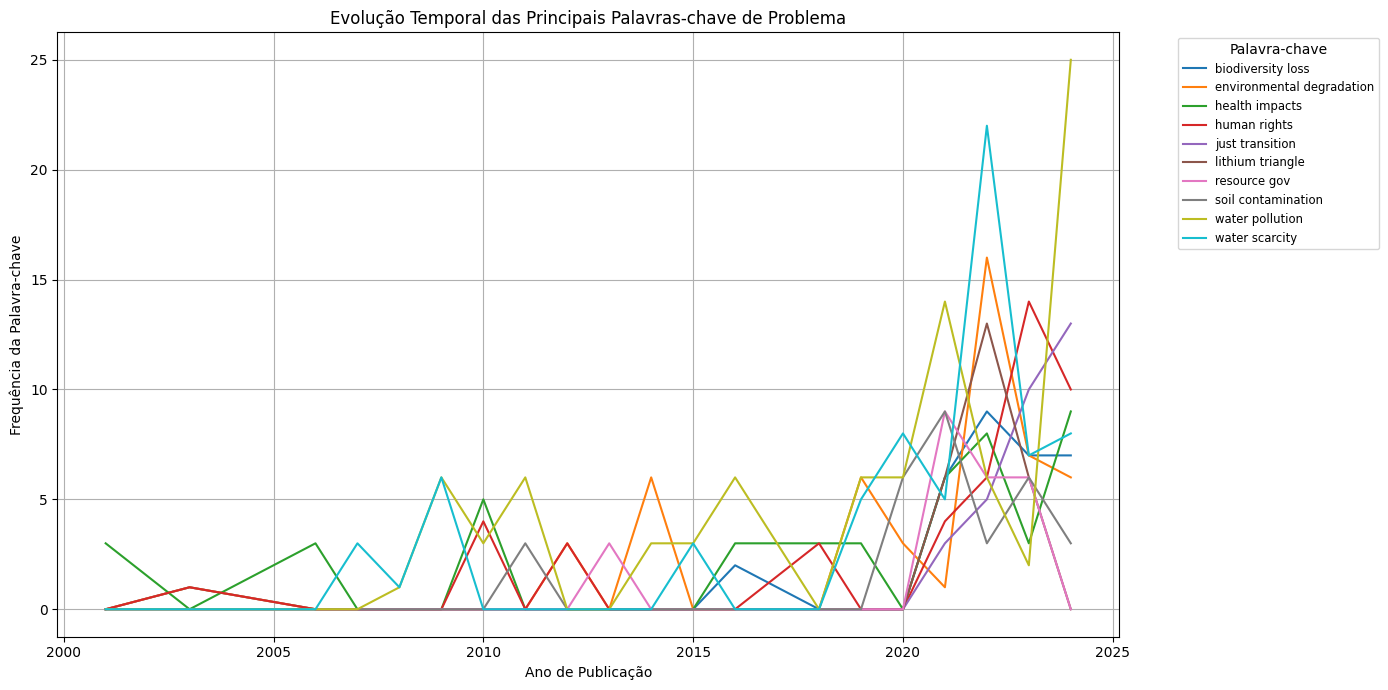

In [278]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'problem_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Problema')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Conceitos

In [279]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['concept_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

                    keyword  count  percent
0                   lithium    144     15.3
1                    copper    134     14.2
2                      zinc     93      9.9
3                   arsenic     78      8.3
4                    nickel     70      7.4
5          critical mineral     60      6.4
6                rare earth     51      5.4
7                    cobalt     44      4.7
8                   uranium     38      4.0
9                 manganese     31      3.3
10                 chromium     31      3.3
11       rare earth element     21      2.2
12    critical raw material     20      2.1
13                 titanium     19      2.0
14                aluminium     17      1.8
15           critical metal     11      1.2
16                 platinum     10      1.1
17                 graphite      9      1.0
18                 tungsten      7      0.7
19                  gallium      7      0.7
20        critical material      6      0.6
21                   cesium     

###Evolução Temporal das Principais Palavras-chave de Conceito

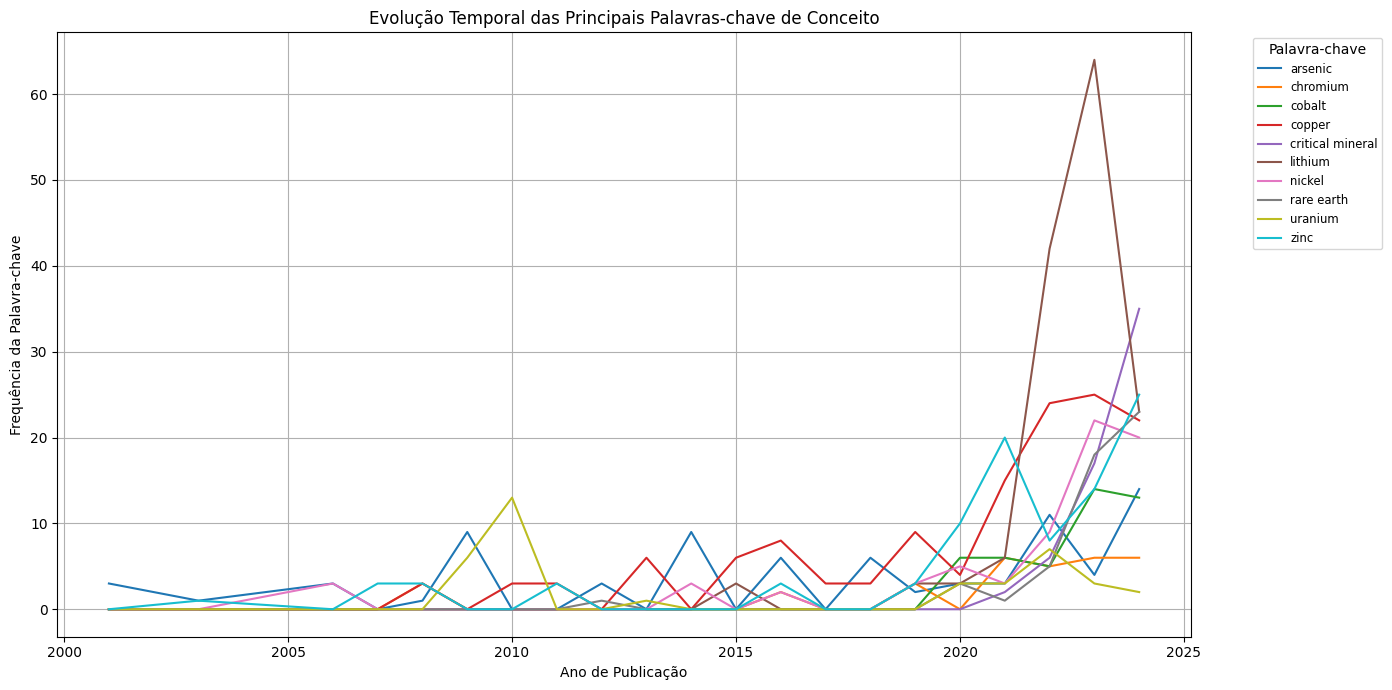

In [280]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'concept_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Contexto

In [281]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['context_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

             keyword  count  percent
0     climate change    427     76.5
1  energy transition    131     23.5


###Evolução Temporal das Principais Palavras-chave de Conceito

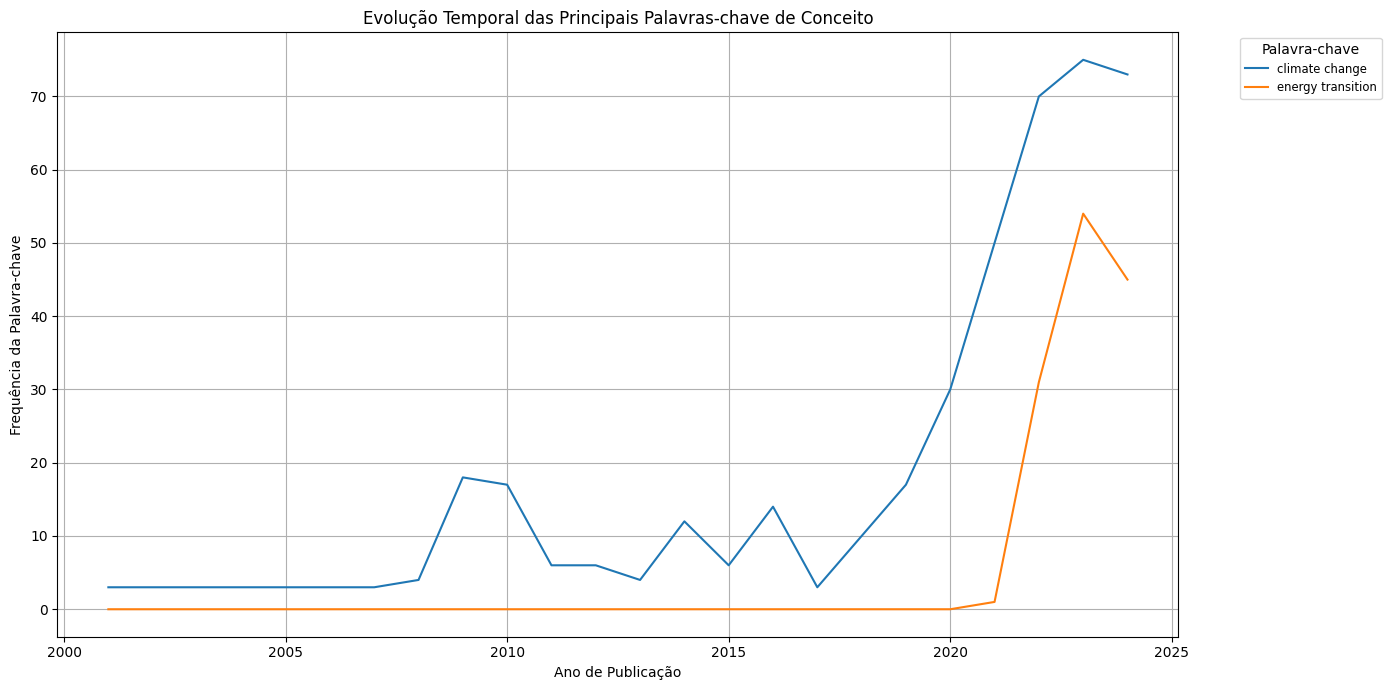

In [282]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'context_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume de kw por área

In [283]:
import pandas as pd

# Step 1: Calculate total count per field
field_order = (
    df_top10_3.groupby('field')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Step 2: Sort df_top10_3 by field (with custom order) and then by count descending
df_top10_3_sorted = (
    df_top10_3
    .assign(field=pd.Categorical(df_top10_3['field'], categories=field_order, ordered=True))
    .sort_values(by=['field', 'count'], ascending=[True, False])
    .reset_index(drop=True)
)

df_top10_3_sorted

,field,all_keywords,count
0,Environmental Science,"(arsenic, climate change, health impacts)",9
1,Environmental Science,"(climate change, copper, water scarcity)",9
2,Environmental Science,"(arsenic, climate change, water scarcity)",6
3,Environmental Science,"(climate change, copper, soil contamination)",5
4,Environmental Science,"(climate change, copper, water pollution)",5
...,...,...,...
183,Physics and Astronomy,"(climate change, cobalt, environmental regulation, manganese, public participation)",1
184,Physics and Astronomy,"(climate change, cobalt, human rights, lithium, nickel)",1
185,Arts and Humanities,"(climate change, environmental violence, uranium)",1
186,Immunology and Microbiology,"(climate change, health impacts, zinc)",1


###Consulta de kw para consultar artigos

####Consulta de kw não encontradas

In [284]:
all_found_problems = set([kw.lower() for sublist in work_ids_a_max_fs_3["problem_kw"] for kw in sublist])
all_found_concepts = set([kw.lower() for sublist in work_ids_a_max_fs_3["concept_kw"] for kw in sublist])
all_found_context = set([kw.lower() for sublist in work_ids_a_max_fs_3["context_kw"] for kw in sublist])

# Quais não foram encontradas?
problems_not_found = sorted(set(problems) - all_found_problems)
concepts_not_found = sorted(set(concepts) - all_found_concepts)
context_not_found = sorted(set(context) - all_found_context)

# Mostrar resultados
print("❌ Palavras-chave de 'problems' que não tiveram nenhum match:")
print(problems_not_found)

print("\n❌ Palavras-chave de 'concepts' que não tiveram nenhum match:")
print(concepts_not_found)

print("\n❌ Palavras-chave de 'context' que não tiveram nenhum match:")
print(context_not_found)

❌ Palavras-chave de 'problems' que não tiveram nenhum match:
['climate injusticegreen colonialism', 'climate vulnerability', 'community resistance', 'conflict over resources', 'corporate accountability', 'cultural erosion', 'environmental defender', 'environmental liability', 'extractive frontier', 'forced relocation', 'governance gap', 'green capitalism', 'inclusion gap', 'livelihood disruption', 'mineral governance', 'mining conflict', 'neoextractivism', 'prior consultation', 'productive chain', 'regulatory capture', 'regulatory uncertainty', 'resource conflict', 'socio-environmental conflict', 'sustainable finance', 'technological dependence', 'technological dependency', 'territorial conflict']

❌ Palavras-chave de 'concepts' que não tiveram nenhum match:
['barite', 'battery metal', 'beryllium', 'bismuth', 'erbium', 'europium', 'fluorspar', 'gadolinium', 'green transition material', 'green transition metal', 'green transition mineral', 'green transition raw material', 'hafnium', 'ho

In [285]:
from collections import Counter
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Define the keyword to check
keyword_to_check = "epistemic justice"

# Ensure all_keywords is a list
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3["all_keywords"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Filter rows that include the keyword
filtered = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["all_keywords"].apply(lambda x: keyword_to_check in x)
]

# Convert list of keywords to tuple (for grouping), preserving order (or use sorted(x) if order doesn’t matter)
filtered["keyword_combination"] = filtered["all_keywords"].apply(lambda x: tuple(x))

# Group by field and keyword combination
grouped = (
    filtered.groupby(["field", "keyword_combination", "title", "abstract"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Show result
grouped


,field,keyword_combination,title,abstract,count


##Análise de publicações

###Publicações por área do conhecimento

/tmp/ipython-input-286-3132261924.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')


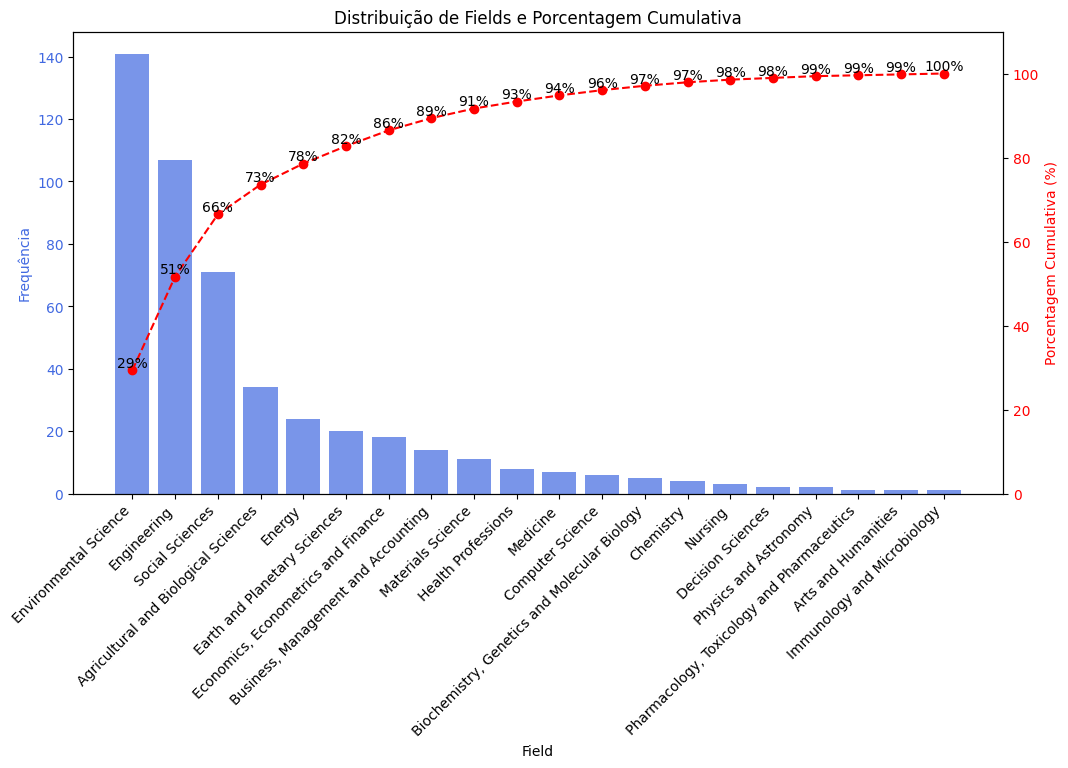

In [286]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada field
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['field', 'count']

# Ordenar por contagem
count_by_field = count_by_field.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa
total = count_by_field['count'].sum()
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['field'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Field')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['field'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Fields e Porcentagem Cumulativa')
plt.show()


####Publicações por área (df)

In [287]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['Área do conhecimento', 'Contagem']

# Exibir o DataFrame
count_by_field

,Área do conhecimento,Contagem
0,Environmental Science,141
1,Engineering,107
2,Social Sciences,71
3,Agricultural and Biological Sciences,34
4,Energy,24
5,Earth and Planetary Sciences,20
6,"Economics, Econometrics and Finance",18
7,"Business, Management and Accounting",14
8,Materials Science,11
9,Health Professions,8


In [288]:
%%bigquery work_ids_a_max_fs_3_t --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country

FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [289]:
work_ids_a_max_fs_3_t

id                      doi  \
0     2793677392  10.15252/embr.201745658   
1     2793677392  10.15252/embr.201745658   
2     2793677392  10.15252/embr.201745658   
3     2793677392  10.15252/embr.201745658   
4     2793677392  10.15252/embr.201745658   
...          ...                      ...   
2225  3044598606       10.3390/su12155967   
2226  3044598606       10.3390/su12155967   
2227   774727978                     None   
2228   774727978                     None   
2229   774727978                     None   

                                                                                                                      title  \
0                                       The power of synthetic biology for bioproduction, remediation and pollution control   
1                                       The power of synthetic biology for bioproduction, remediation and pollution control   
2                                       The power of synthetic biology for bioproduction, remediation and pollution control   
3                                       The power of synthetic biology for bioproduction, remediation and pollution control   
4                                       The power of synthetic biology for bioproduction, remediation and pollution control   
...                                                                                                                     ...   
2225  Spatial Compatibility of Implementing Nature-Based Solutions for Reducing Urban Heat Islands and Stormwater Pollution   
2226  Spatial Compatibility of Implementing Nature-Based Solutions for Reducing Urban Heat Islands and Stormwater Pollution   
2227                                    A Regulatory Framework for Carbon Sequestration: Liability and Financial Mechanisms   
2228                                    A Regulatory Framework for Carbon Sequestration: Liability and Financial Mechanisms   
2229                                    A Regulatory Framework for Carbon Sequestration: Liability and Financial Mechanisms   

         type  publication_year  max_score  \
0     article              2018     0.9744   
1     article              2018     0.9744   
2     article              2018     0.9744   
3     article              2018     0.9744   
4     article              2018     0.9744   
...       ...               ...        ...   
2225  article              2020     0.9995   
2226  article              2020     0.9995   
2227  article              2009     0.9994   
2228  article              2009     0.9994   
2229  article              2009     0.9994   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

/tmp/ipython-input-290-3013633053.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')


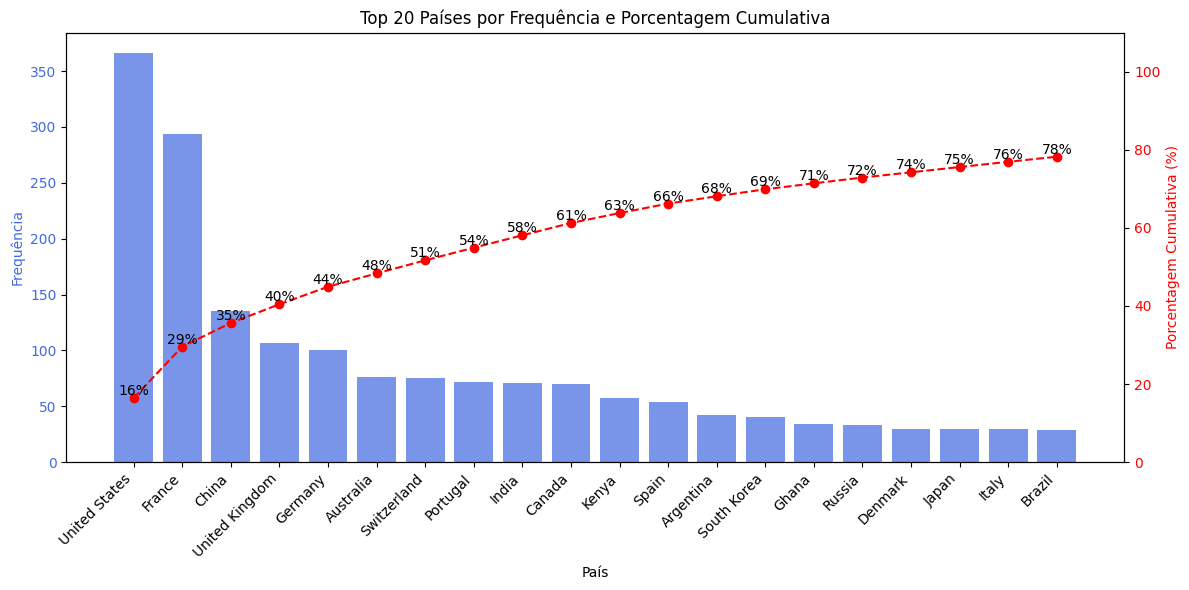

In [290]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada país
count_by_country = work_ids_a_max_fs_3_t['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']

# Ordenar por contagem
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa (baseada no total geral)
total = count_by_country['count'].sum()
count_by_country['cumulative_percentage'] = count_by_country['count'].cumsum() / total * 100

# Selecionar os 20 países com maior contagem para exibição
top20_countries = count_by_country.head(20)

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(top20_countries['country'], top20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(top20_countries['country'], top20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(top20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Top 20 Países por Frequência e Porcentagem Cumulativa')
plt.tight_layout()
plt.show()

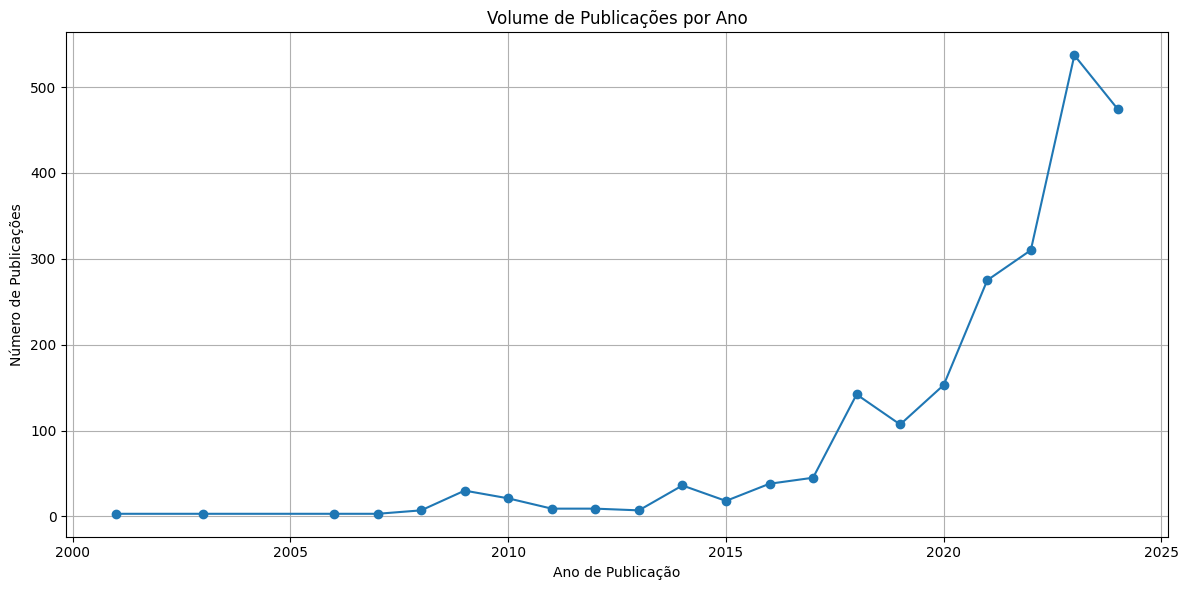

In [291]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar publicações por ano
publications_per_year = work_ids_a_max_fs_3_t['publication_year'].value_counts().reset_index()
publications_per_year.columns = ['publication_year', 'count']
publications_per_year = publications_per_year.sort_values(by='publication_year')

# Criar gráfico de linha
plt.figure(figsize=(12, 6))
plt.plot(publications_per_year['publication_year'], publications_per_year['count'], marker='o', linestyle='-')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Volume de Publicações por Ano')
plt.grid(True)
plt.tight_layout()
plt.show()

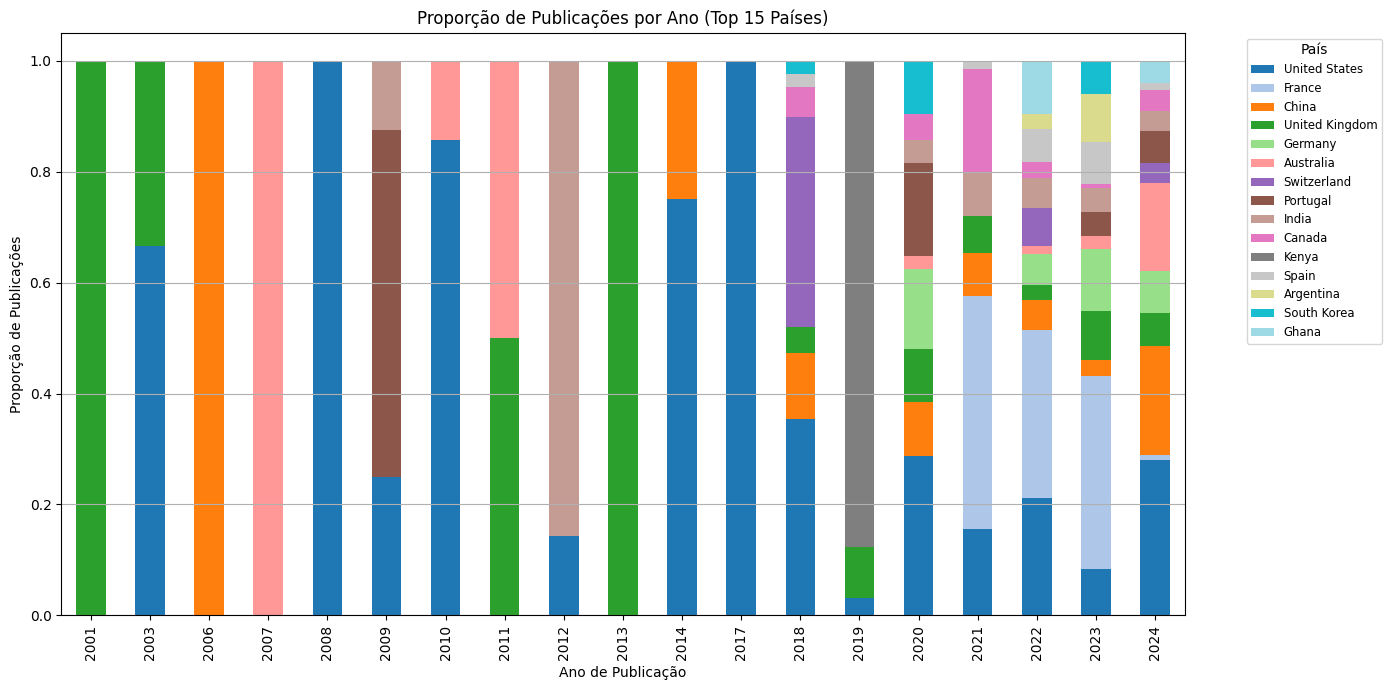

In [292]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3_t = pd.read_csv('seu_arquivo.csv')

# Agrupar por ano e país
publications_by_year_country = (
    work_ids_a_max_fs_3_t
    .groupby(['publication_year', 'country'])
    .size()
    .reset_index(name='count')
)

# Selecionar os 20 países com mais publicações no total
top_countries = (
    publications_by_year_country.groupby('country')['count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Filtrar apenas esses países
filtered_df = publications_by_year_country[publications_by_year_country['country'].isin(top_countries)]

# Pivotar: linhas = ano, colunas = país, valores = contagem
pivot_table = filtered_df.pivot(
    index='publication_year',
    columns='country',
    values='count'
).fillna(0).sort_index()

# Ordenar colunas com os países mais produtivos na base
ordered_columns = pivot_table.sum().sort_values(ascending=False).index
pivot_table = pivot_table[ordered_columns]

# Normalizar por linha para criar gráfico 100% empilhado
pivot_relative = pivot_table.div(pivot_table.sum(axis=1), axis=0)

# Plotar gráfico de barras empilhadas relativas
pivot_relative.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)

plt.xlabel('Ano de Publicação')
plt.ylabel('Proporção de Publicações')
plt.title('Proporção de Publicações por Ano (Top 15 Países)')
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [293]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['publication_year'].value_counts().reset_index()
count_by_field.columns = ['Ano de publicação', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

    Ano de publicação  Contagem
0                2023       100
1                2024        96
2                2022        86
3                2021        47
4                2020        29
5                2009        18
6                2019        17
7                2010        13
8                2014        12
9                2016        11
10               2018        10
11               2015         6
12               2012         6
13               2011         6
14               2013         4
15               2008         4
16               2003         3
17               2007         3
18               2006         3
19               2001         3
20               2017         3


###Distribuição de publicação por área ao longo do tempo

In [294]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

# Generate distinct colors for each field using Seaborn's color palette
num_fields = len(count_by_year_field_percentage.columns)
colors = sns.color_palette("tab20", num_fields)  # Using 'tab20' for better color distinction

# Plot stacked area chart with improved color distinction
fig, ax = plt.subplots(figsize=(12, 6))
count_by_year_field_percentage.plot(kind='area', stacked=True, ax=ax, color=colors, alpha=0.7)

# Labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Percentage')
ax.set_title('Stacked Percentage of Fields Over the Years')
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

NameError: name 'count_by_year_field_percentage' is not defined

###Publicações por país

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar o número total de ocorrências por país (quantidade de vezes que aparece no dataset)
count_by_country = work_ids_a_max_fs_3['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Manter apenas os 20 países mais frequentes
top_20_countries = count_by_country.head(20).copy()

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_3)  # Total de linhas no dataset
top_20_countries['cumulative_percentage'] = top_20_countries['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para os 20 principais países
ax1.bar(top_20_countries['country'], top_20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Número de Ocorrências', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top_20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva de porcentagem cumulativa
ax2 = ax1.twinx()
ax2.plot(top_20_countries['country'], top_20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%) em relação ao total do dataset', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais na curva de porcentagem cumulativa
for i, txt in enumerate(top_20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Ocorrências por País e Porcentagem Cumulativa em relação ao Total do Dataset')
plt.show()


###Publicações por instituições

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada institution
count_by_field = work_ids_a_max_fs_yr_3['institution'].value_counts().reset_index()
count_by_field.columns = ['institution', 'count']

# Manter somente os 20 primeiros
count_by_field = count_by_field.head(20)

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['institution'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Institution')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['institution'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['institution'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Institutions e Porcentagem Cumulativa')
plt.show()


## Análise de tópicos (BERTopic)

In [ ]:
%%bigquery bertopic --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field--, d.display_name as subfield-- g.country,
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id



In [ ]:
len(bertopic)

###Seleção de área e export de .csv

In [ ]:
bertopic_df = bertopic[['title', 'abstract', 'publication_year','topic', 'field']]
df = bertopic_df[
    (bertopic_df['field'] == 'Social Sciences')
]
df

In [ ]:
len(df)

In [ ]:
df.to_csv(folder + '/ANPOCS (Social Sciences)/bertopic_social_sciences.csv', index=False)

### Compilador de tópicos a partir de .csv do Drive

In [ ]:
import pandas as pd
import os
from google.colab import drive

# Define folder path
folder_path = '/content/drive/MyDrive/cientometria_resultados/Tópicos compilados'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Load and merge all CSVs, tagging with source filename
df_list = []
for file in csv_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df['source_file'] = file  # Add a column with the file name
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)

# Save merged DataFrame to CSV
output_path = os.path.join(folder_path, 'merged_result.csv')
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")


#Exercício Projeto Letícia: Problemas + Conceitos + Contexto

##Coleta de dados da OpenAlex

###Extração de IDs



In [360]:
from google.cloud import bigquery
from google.colab import auth
import re
auth.authenticate_user()

client = bigquery.Client(project="insyspo")

In [361]:
context = [
    # "Cannabis research", "Cannabinoids research", "Cannabis consumption",
    # "Cannabis impact", "Cannabinoids impact", "Cannabis regulation",
    # "Regulatory challenges", "Pharmacokinetics", "Cannabis legislation",
    # "Cannabis legalization", "Cannabis pharmacology", "Public health",
    # "Therapeutic cannabis", "Cannabis effects", "Therapeutic cannabinoids",
    # "Medical cannabis", "Pharmacodynamics", "Marijuana dispensaries", "Marijuana use",
    # "Cannabinoid-based medicine", "Cannabis-based medicine", "Marijuana treatment",
    # "Medicinal marijuana", "Cannabis therapy", "Cannabis use", "Cannabis usage",
    # "Dose-response", "Safety", "Efficacy", "Cannabinoid therapy", "Bioavailability",
    # "Oral administration", "Inhalation", "Vaporization", "Smoking", "Sublingual administration",
    # "Topical application", "Encapsulated delivery", "Intravenous administration", "Endocannabinoid system",
    # "CB1 receptor", "CB2 receptor", "International regulations", "Prescription guidelines",
    # "Randomized controlled trials", "In vitro study", "In vivo study"]
    "public health", "therapeutic", "effects", "medical", "cannabinoid based medicine",
    "cannabis based medicine", "treatment", "therapy", "usage", "safety", "efficacy",
    "bioavailability", "oral administration", "inhalation", "topical application",
    "intravenous administration", "endocannabinoid system", "randomized controlled trials",
    "in vitro study", "in vivo study", "preclinical research", "clinical efficacy",
    "case reports", "meta-analyses", "evidence-based medicine", "double-blind trials",
    "clinical trial", "clinical use", "dentistry", "oral health", "health", "medicine"
]

# problems = []

# concepts = []

problems = [
    # "adverse effects", "drug interactions", "cannabis Addiction", "cannabis harm",
    # "cannabis paradigm", "cannabis stigma", "cannabis allergy", "cannabis abuse",
    # "cannabis dependence", "cannabis toxicity", "chronic pain", "epilepsy", "seizure control",
    # "anxiety disorders", "multiple sclerosis", "chronic inflammation",
    # "inflammatory diseases", "arthritis", "neurodegenerative diseases",
    # "neuropathic pain", "dravet syndrom", "addiction potential",
    # "psychoactive effects", "sleep disorders", "spasticity", "autism spectrum disorder",
    # "depression", "glaucoma", "fibromyalgia", "ulcerative colitis",
    # "skin conditions", "bone regeneration", "osteoarthritis", "migraine", "endometriosis",
    # "psychosis", "inflammatory bowel Disease", "pain Control", "palliative care",
    # "migraine", "oncologic Pain","COVID-19"] #"Crohn’s disease", #"Parkinson's disease", #"Lennox-Gastaut syndrome", "alzheimer's disease","tics"]
    "adverse effects", "drug interactions", "addiction", "harm", "allergy", "toxicity",
    "chronic pain", "epilepsy", "seizure control", "anxiety", "multiple sclerosis",
    "chronic inflammation", "parkinson", "alzheimer", "inflammatory",
    "arthritis", "neurodegenerative", "neuropathic pain", "dravet syndrome",
    "lennox-gastaut syndrome", "psychoactive effects", "sleep disorders", "spasticity",
    "autism spectrum disorder", "depression", "glaucoma", "fibromyalgia", "crohn",
    "ulcerative colitis", "skin conditions", "bone regeneration", "osteoarthritis", "migraine",
    "endometriosis", "psychosis", "inflammatory bowel", "pain control", "palliative care",
    "oncologic pain", "covid-19"

]

concepts = [
    # "cannabis", "cannabaceae", "cannabis sativa", "cannabis indica",
    # "cannabis ruderalis", "cannabis hybrid", "cannabis plant", "cannabis cultivation",
    # "cannabis constituents", "cannabis componentes", "cannabis oil", "cannabis extraction",
    # "full-spectrum cannabis", "cannabis sativa l. extract", "hemp", "marijuana", "sativex",
    # "epidiolex", "phytocannabinoids", "cannabis products", "cannabinoid receptors",
    # "cannabinoid receptor antagonists", "cannabinoid receptor agonists", "cannabinoids",
    # "cannabinoid receptor modulators", "receptor cannabinoid cb1", "receptor cannabinoid cb2",
    # "oral cannabinoids", "cannabidiol", "cannabigerol", "cannabinol", "cannabichromene",
    # "cannabidivarin", "cannabinodiol", "flavonoids", "terpenes", "δ⁹-tetrahydrocannabinol",
    # "δ8-tetrahydrocannabinol", "tetrahydrocannabinolic acid", "cannabidiolic acid",
    # "cannabichromenic acid", "cbd", "thc", "cbg", "cbc", "cbn", "thca", "cbca", "cbda",
    # "anandamide", "aea", "2-arachidonoylgl"
    "cannabis", "full-spectrum", "marijuana", "sativex", "epidiolex", "phytocannabinoids",
    "cannabinoid receptors", "cannabinoid receptor antagonists", "cannabinoid receptor agonists",
    "cannabinoids", "cannabinoid receptor modulators", "cb1", "cb2", "oral cannabinoids",
    "cannabidiol", "cannabigerol", "cannabinol", "cannabichromene", "cannabidivarin",
    "cannabinodiol", "δ⁹-tetrahydrocannabinol", "δ8-tetrahydrocannabinol",
    "tetrahydrocannabinolic acid", "cannabidiolic acid", "cannabichromenic acid",
    "cbd", "cbg", "cbc", "cbn", "cbca", "cbda", "anandamide", "aea",
    "2-arachidonoylglycerol", "2-ag", "hemp", "hashish", "ganja", "bhang"
]#, "flavonoids"

# === Words that must match as full words ===
exact_match_words = {"thc", "cbd", "cbg", "cbn", "thca", "cbca", "cbda", "aea", "cbc", "bhang"}

# === Clause builder using full-word regex for exact matches ===
def build_like_clauses(terms, field):
    if not terms:
        return ""
    clauses = []
    for term in terms:
        term_lc = term.lower().strip()
        if term_lc in exact_match_words:
            # Match full word using BigQuery REGEXP_CONTAINS
            pattern = rf"'(^|[^a-z0-9]){re.escape(term_lc)}([^a-z0-9]|$)'"
            clauses.append(f"REGEXP_CONTAINS(LOWER({field}), {pattern})")
        else:
            clauses.append(f"LOWER({field}) LIKE '%{term_lc}%'")
    return "\n                OR ".join(clauses)

# === Build clause blocks ===
problem_display_clause = build_like_clauses(problems, "display_name")
concept_display_clause = build_like_clauses(concepts, "display_name")
context_display_clause = build_like_clauses(context, "display_name")

problem_abstract_clause = build_like_clauses(problems, "abstract")
concept_abstract_clause = build_like_clauses(concepts, "abstract")
context_abstract_clause = build_like_clauses(context, "abstract")

# === Combine where clauses ===
def make_where_clause(problem_clause, concept_clause, context_clause):
    clauses = []
    if problem_clause:
        clauses.append(f"({problem_clause})")
    if concept_clause:
        clauses.append(f"({concept_clause})")
    if context_clause:
        clauses.append(f"({context_clause})")
    return " AND ".join(clauses) if clauses else "TRUE"

works_where = make_where_clause(problem_display_clause, concept_display_clause, context_display_clause)
abstract_where = make_where_clause(problem_abstract_clause, concept_abstract_clause, context_abstract_clause)

# === Final SQL query ===
query = f"""
DROP TABLE IF EXISTS `insyspo.userdb_fernando_spolidorio.cm_work_ids_3`;

CREATE TABLE `insyspo.userdb_fernando_spolidorio.cm_work_ids_3` AS (
    SELECT DISTINCT id
    FROM (
        SELECT id
        FROM `insyspo.publicdb_openalex_2024_10_rm.works`
        WHERE {works_where}
        UNION ALL
        SELECT id
        FROM `insyspo.projectdb_cwts_summer_school_2023.works_abstracts`
        WHERE {abstract_where}
    )
);
"""

In [362]:
# Execute the query
job = client.query(query)
job.result()  # Wait for completion
print("Query completed and table created.")

Query completed and table created.


In [363]:
%%bigquery work_ids_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_3

Query is running:   0%|          |

Downloading:   0%|          |

In [364]:
len(work_ids_3)

45279

###Filtros

####Artigos e anos

In [365]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS (

SELECT a.id, b.doi, b.title, b.type, b.publication_year
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works AS b ON a.id = b.id
WHERE b.type = 'article' and b.publication_year > 2015 and b.publication_year < 2025
);

Query is running:   0%|          |

""


In [366]:
%%bigquery work_ids_a_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3

Query is running:   0%|          |

Downloading:   0%|          |

In [367]:
len(work_ids_a_3)

18756

####Maxscores

In [368]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS (

WITH MaxScores AS (
    SELECT a.*, MAX(b.score) AS max_score
    FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS a
    JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
    GROUP BY all
)

select * from maxscores

)


Query is running:   0%|          |

""


In [369]:
%%bigquery work_ids_a_max_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3

Query is running:   0%|          |

Downloading:   0%|          |

In [370]:
len(work_ids_a_max_3)

18689

In [371]:
work_ids_a_max_3

,id,doi,title,type,publication_year,max_score
0,3202192363,10.1002/ueg2.12143,UEG Week 2021 Moderated Posters,article,2021,0.0349
1,4392125053,10.15173/m.v1i39.3298,MedBulletin,article,2022,0.0430
2,2953560592,10.1249/01.mss.0000561047.50301.5f,Perplexing Presentation- Preserving Function,article,2019,0.0464
3,4394751489,10.17579/abstractbookdualdisorders-p-265,EVALUACIÓN DEL USO DE PALMITATO DE PALIPERIDONA TRIMESTRAL EN EL ESM DE LLERENA-ZAFRA.,article,2024,0.0485
4,4394751055,10.17579/abstractbookdualdisorders-p-125,COMORBILIDAD DEL TDAH CON EL TUS; A PROPÓSITO DE UN CASO.,article,2024,0.0485
...,...,...,...,...,...,...
18684,4401991852,10.3390/vaccines12090984,Immune Cell Profiles of Patients with Sickle Cell Disease during Parvovirus B19–Induced Transient Red Cell Aplasia,article,2024,1.0000
18685,4396916820,10.26828/cannabis/2024/000239,"Medical Cannabis for Patients Over Age 50: A Multi-site, Prospective Study of Patterns of Use and Health Outcomes",article,2024,1.0000
18686,4391614773,10.1111/adb.13372,"Differential cannabinoid‐like effects and pharmacokinetics of ADB‐BICA, ADB‐BINACA, ADB‐4en‐PINACA and MDMB‐4en‐PINACA in mice: A comparative study",article,2024,1.0000
18687,4392167140,10.3389/fphar.2024.1352939,NeuroPredict: study of the predictive value of ABCB1 genetic polymorphisms and associated clinical factors in chronic chemotherapy-induced peripheral neuropathy (CIPN),article,2024,1.0000


###Fields & subfields

In [372]:
%%bigquery work_ids_a_max_fs_3 --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield--, i.country, h.work_id
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
# JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
# JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
# JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [373]:
len(work_ids_a_max_fs_3)

49502

In [374]:
# Drop duplicates keeping the first row for each id
work_ids_a_max_fs_3 = work_ids_a_max_fs_3.drop_duplicates(subset=['id','topic', 'field','subfield'])

## Análise de palavras-chaves identificadas

###Criação de colunas

####Criação das colunas problems_kw e concept_kw

In [375]:
import pandas as pd
import re

# --- 2. Exceções para match exato ---
exact_match_words = {"thc", "cbd", "cbg", "cbn", "thca", "cbca", "cbda", "aea"}

# --- 3. Função de extração robusta ---
def extract_keywords(text, keywords, exact_match_words):
    if pd.isna(text):
        return []
    text = text.lower()
    found = []
    for kw in keywords:
        kw_lc = kw.lower().strip()
        if kw_lc in exact_match_words:
            if re.search(rf'\b{re.escape(kw_lc)}\b', text):
                found.append(kw)
        else:
            if kw_lc in text:
                found.append(kw)
    return list(dict.fromkeys(found))

# --- 4. Normalizar listas ---
problems = [p.lower().strip() for p in problems]
concepts = [c.lower().strip() for c in concepts]
contexts = [c.lower().strip() for c in context]  # Adicionado para contexts

# --- 5. Aplicar no DataFrame ---
work_ids_a_max_fs_3["problem_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], problems, exact_match_words) +
                extract_keywords(row["abstract"], problems, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["concept_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], concepts, exact_match_words) +
                extract_keywords(row["abstract"], concepts, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["context_kw"] = work_ids_a_max_fs_3.apply(  # Novo para contexts
    lambda row: extract_keywords(row["title"], context, exact_match_words) +
                extract_keywords(row["abstract"], context, exact_match_words),
    axis=1
)

# --- 6. Identificar casos problemáticos ---
no_concept_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["concept_kw"].apply(lambda x: len(x) == 0)
]

no_problem_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["problem_kw"].apply(lambda x: len(x) == 0)
]

no_context_rows = work_ids_a_max_fs_3[  # Novo para contexts
    work_ids_a_max_fs_3["context_kw"].apply(lambda x: len(x) == 0)
]

print("⚠️ Registros com ZERO conceitos detectados:", len(no_concept_rows))
print("⚠️ Registros com ZERO problemas detectados:", len(no_problem_rows))
print("⚠️ Registros com ZERO contextos detectados:", len(no_context_rows))


⚠️ Registros com ZERO conceitos detectados: 3
⚠️ Registros com ZERO problemas detectados: 0
⚠️ Registros com ZERO contextos detectados: 0


####Criação da coluna all_keywords

In [376]:
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3.apply(
    lambda row: sorted(set(row["problem_kw"] + row["concept_kw"] + row["context_kw"])),
    axis=1)

work_ids_a_max_fs_3.head()

,id,doi,title,type,publication_year,max_score,abstract,topic,field,subfield,problem_kw,concept_kw,context_kw,all_keywords
0,3015538561,10.18632/oncotarget.27528,Synergistic cytotoxic activity of cannabinoids from<i>cannabis sativa</i>against cutaneous T-cell lymphoma (CTCL)<i>in-vitro</i>and<i>ex-vivo</i>,article,2020,0.9965,"// Moran Mazuz 1 , * , Amir Tiroler 1 , 2 , * , Lilach Moyal 3 , 4 , Emmilia Hodak 3 , 4 , Stalin Nadarajan 1 , Ajjampura C. Vinayaka 1 , Batia Gorovitz-Haris 4 , Ido Lubin 5 , Avi Drori 6 , Guy Drori 6 , Owen Van Cauwenberghe 7 , Adi Faigenboim 1 , Dvora Namdar 1 , Iris Amitay-Laish 3 , 4 , # and Hinanit Koltai 1 , # 1 Agricultural Research Organization (ARO), Volcani Center, Rishon LeZion, Israel 2 The Mina and Everard Goodman Faculty of Life Sciences, Bar-Ilan University, Ramat Gan, Israel 3 Division of Dermatology, Rabin Medical Center, Petach Tikva, and Sackler Faculty of Medicine, Tel Aviv University, Tel Aviv, Israel 4 Laboratory for Molecular Dermatology, Felsenstein Medical Research Center, Rabin Medical Center, Petach Tikva, and Sackler Faculty of Medicine, Tel Aviv University, Tel Aviv, Israel 5 Core Facility, Felsenstein Medical Research Center, Rabin Medical Center, Petach Tikva, and Sackler Faculty of Medicine, Tel Aviv University, Tel Aviv, Israel 6 MedC Biopharma Corporation, Ontario, Canada 7 AgMedica Bioscience Inc., Chatham-Kent, Canada * These authors equally contributed as the first author # These authors equally contributed as the last author Correspondence to: Hinanit Koltai, email: hkoltai@agri.gov.il Keywords: cutaneous T-cell lymphoma; cannabis; cannabinoids; peripheral blood lymphocytes; CTCL cell lines Received: July 15, 2019 Accepted: March 03, 2020 Published: March 31, 2020 ABSTRACT Cannabis sativa produces hundreds of phytocannabinoids and terpenes. Mycosis fungoides (MF) is the most common type of cutaneous T-cell lymphoma (CTCL), characterized by patches, plaques and tumors. Sézary is a leukemic stage of CTCL presenting with erythroderma and the presence of neoplastic Sézary T-cells in peripheral blood. This study aimed to identify active compounds from whole cannabis extracts and their synergistic mixtures, and to assess respective cytotoxic activity against CTCL cells. Ethanol extracts of C. sativa were analyzed by high-performance liquid chromatography (HPLC) and gas chromatography/mass spectrometry (GC/MS). Cytotoxic activity was determined using the XTT assay on My-La and HuT-78 cell lines as well as peripheral blood lymphocytes from Sézary patients (SPBL). Annexin V assay and fluorescence-activated cell sorting (FACS) were used to determine apoptosis and cell cycle. RNA sequencing and quantitative PCR were used to determine gene expression. Active cannabis compounds presenting high cytotoxic activity on My-La and HuT-78 cell lines were identified in crude extract fractions designated S4 and S5, and their synergistic mixture was specified. This mixture induced cell cycle arrest and cell apoptosis; a relatively selective apoptosis was also recorded on the malignant CD4 + CD26 - SPBL cells. Significant cytotoxic activity of the corresponding mixture of pure phytocannabinoids further verified genuine interaction between S4 and S5. The gene expression profile was distinct in My-La and HuT-78 cells treated with the S4 and S5 synergistic mixture. We suggest that specifying formulations of synergistic active cannabis compounds and unraveling their modes of action may lead to new cannabis-based therapies.",Production of Recombinant Pharmaceuticals in Plants,"Biochemistry, Genetics and Molecular Biology",Biotechnology,[harm],"[cannabis, cannabinoids, cannabis, phytocannabinoids, cannabinoids]","[medical, medicine]","[cannabinoids, cannabis, harm, medical, medicine, phytocannabinoids]"
1,3015538561,10.18632/oncotarget.27528,Synergistic cytotoxic activity of cannabinoids from<i>cannabis sativa</i>against cutaneous T-cell lymphoma (CTCL)<i>in-vitro</i>and<i>ex-vivo</i>,article,20

In [377]:
pd.set_option('display.max_colwidth', None)

In [378]:
target_keywords = ["Efficacy", "bone regeneration", "cbc"]

filtered_df = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["all_keywords"].apply(lambda x: sorted(x) == sorted(target_keywords))
]
filtered_df

,id,doi,title,type,publication_year,max_score,abstract,topic,field,subfield,problem_kw,concept_kw,context_kw,all_keywords


###20 combinações de kw mais comuns por área do conhecimento

In [379]:
df=work_ids_a_max_fs_3
df["all_keywords"] = df["all_keywords"].apply(lambda x: tuple(x))  # Convert lists to tuples

df_grouped = (
    df.groupby(["field", "all_keywords"])
    .size()
    .reset_index(name="count")
)

# Get top 10 counts per field
df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))

df_top10_3


/tmp/ipython-input-379-3636565974.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))


,field,all_keywords,count
138,Agricultural and Biological Sciences,"(adverse effects, effects, hemp)",12
824,Agricultural and Biological Sciences,"(cb1, effects, harm, treatment)",9
978,Agricultural and Biological Sciences,"(effects, hemp, toxicity)",9
832,Agricultural and Biological Sciences,"(cb1, effects, toxicity, treatment)",8
279,Agricultural and Biological Sciences,"(anxiety, cannabis, chronic pain, depression, harm, health, psychosis, safety, treatment)",7
...,...,...,...
24693,Veterinary,"(arthritis, cannabidiol, cbd, chronic pain, effects, efficacy, osteoarthritis, treatment)",2
24697,Veterinary,"(arthritis, cannabidiol, effects, efficacy, inflammatory, osteoarthritis, treatment)",2
24703,Veterinary,"(cannabidiol, cannabinol, cbd, depression, effects, harm, health, therapeutic, treatment)",2
24725,Veterinary,"(cbc, depression, treatment)",2


In [380]:
df_top10_3[df_top10_3["field"]=="Dentistry"]

,field,all_keywords,count
4092,Dentistry,"(cbg, in vitro study, toxicity, treatment)",3
4057,Dentistry,"(addiction, ganja, health, oral health, treatment)",2
4058,Dentistry,"(addiction, hashish, health, oral health, therapy)",2
4069,Dentistry,"(anxiety, health, marijuana, medical, treatment)",2
4072,Dentistry,"(arthritis, cbc, chronic inflammation, inflammatory, medical, treatment)",2
4073,Dentistry,"(bone regeneration, cbc, clinical trial, treatment)",2
4087,Dentistry,"(cbc, health, inflammatory)",2
4088,Dentistry,"(cbc, health, inflammatory, therapy, treatment)",2
4091,Dentistry,"(cbd, effects, therapeutic, toxicity, treatment)",2
4093,Dentistry,"(chronic inflammation, marijuana, medical, treatment)",2


###Volume e representatividade de palavras-chaves de Problema



In [381]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['problem_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

keyword_df

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

,keyword,count,percent
0,harm,22349,22.9
1,inflammatory,10921,11.2
2,anxiety,8014,8.2
3,depression,7061,7.2
4,toxicity,6221,6.4
5,covid-19,5181,5.3
6,addiction,4834,4.9
7,psychosis,4175,4.3
8,chronic pain,3739,3.8
9,adverse effects,3528,3.6


###Evolução Temporal das Principais Palavras-chave de Problema

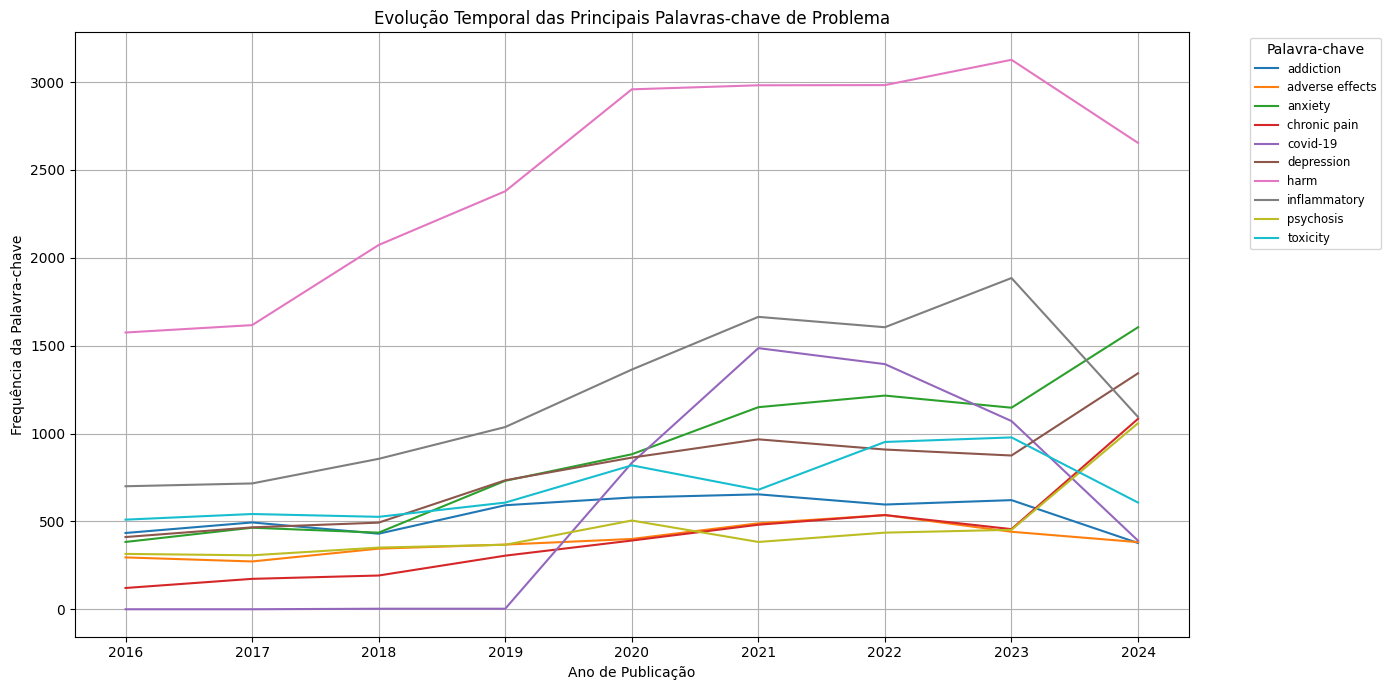

In [382]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'problem_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Problema')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Conceitos

In [383]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['concept_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
keyword_df

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

,keyword,count,percent
0,cannabis,29147,27.8
1,cannabidiol,10477,10.0
2,cb1,9849,9.4
3,cannabinoids,9572,9.1
4,cbd,8325,7.9
5,marijuana,7544,7.2
6,cannabinol,5463,5.2
7,cbc,4865,4.6
8,cb2,3653,3.5
9,hemp,2794,2.7


###Evolução Temporal das Principais Palavras-chave de Conceito

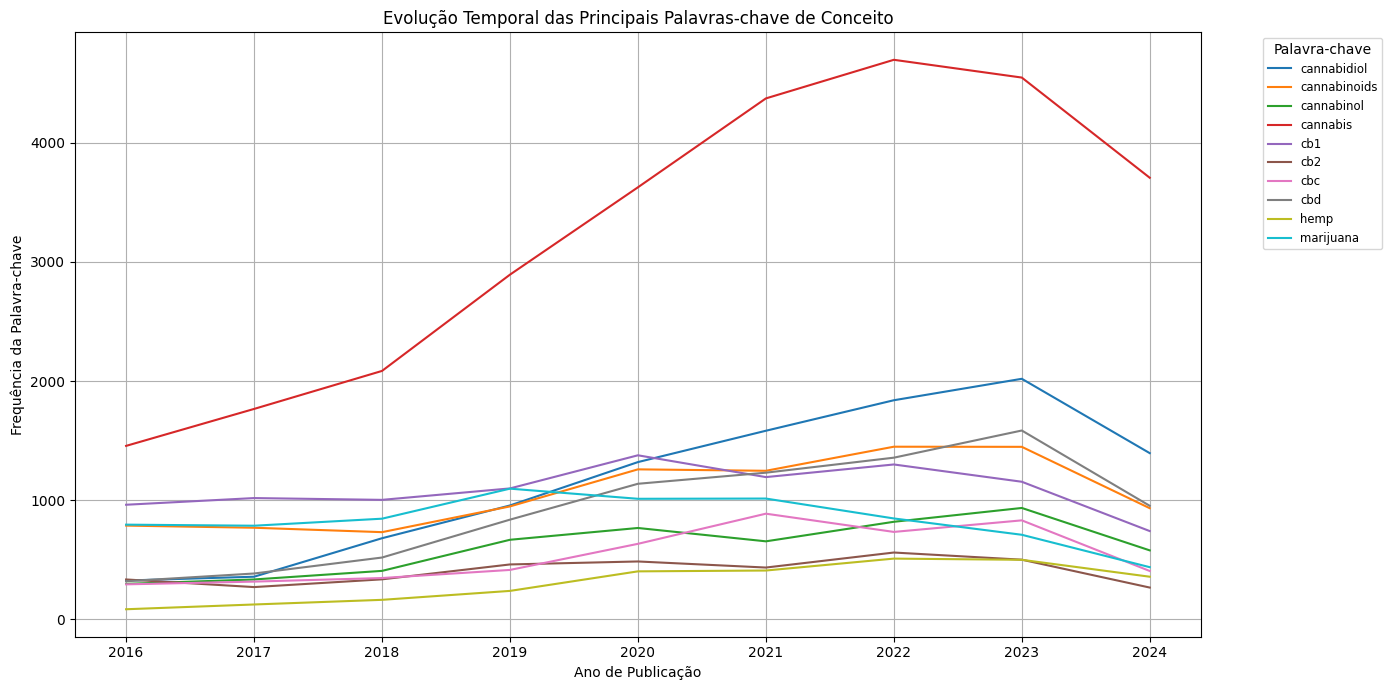

In [384]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'concept_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Contexto

In [385]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['context_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
keyword_df

#keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

,keyword,count,percent
0,treatment,26572,19.2
1,effects,23705,17.2
2,health,21881,15.8
3,medical,13390,9.7
4,therapy,10415,7.5
5,therapeutic,10081,7.3
6,efficacy,6656,4.8
7,safety,6049,4.4
8,medicine,4835,3.5
9,public health,2971,2.2


###Evolução Temporal das Principais Palavras-chave de Conceito

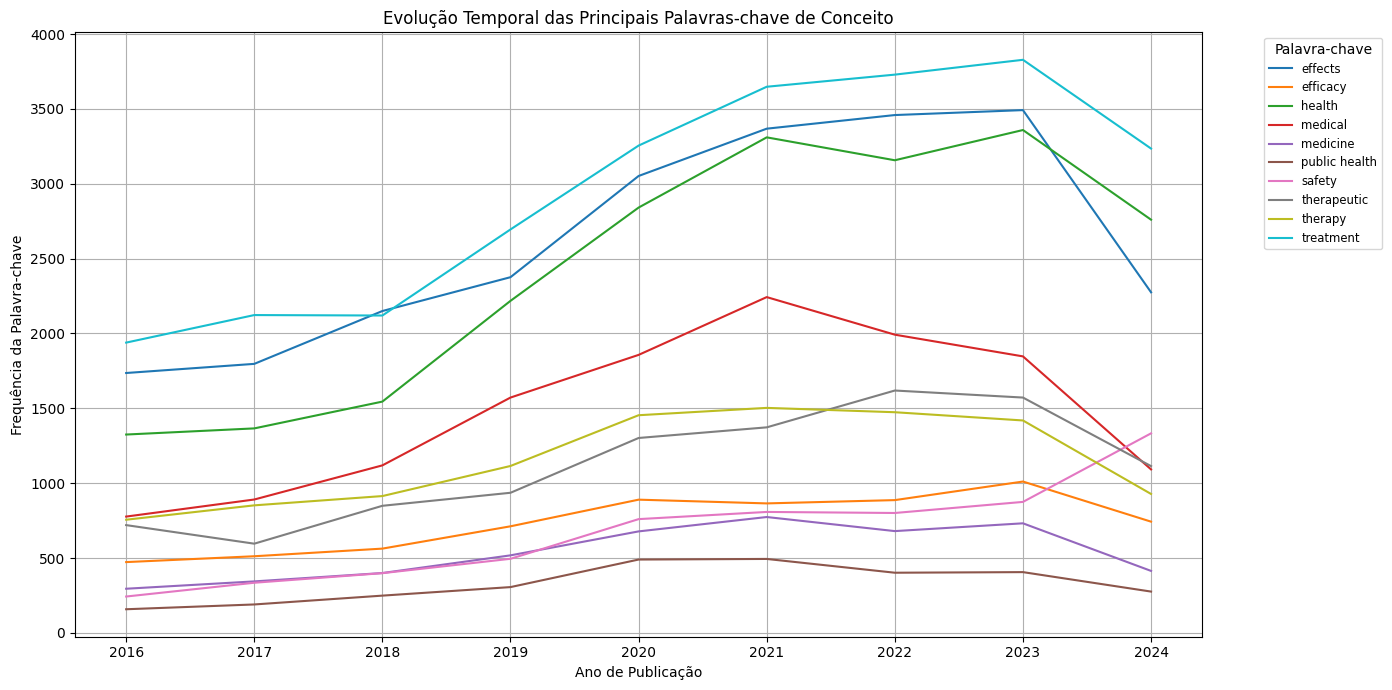

In [386]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'context_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume de kw por área

In [387]:
import pandas as pd

# Step 1: Calculate total count per field
field_order = (
    df_top10_3.groupby('field')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Step 2: Sort df_top10_3 by field (with custom order) and then by count descending
df_top10_3_sorted = (
    df_top10_3
    .assign(field=pd.Categorical(df_top10_3['field'], categories=field_order, ordered=True))
    .sort_values(by=['field', 'count'], ascending=[True, False])
    .reset_index(drop=True)
)

df_top10_3_sorted

,field,all_keywords,count
0,Medicine,"(anxiety, cannabis, chronic pain, depression, harm, health, psychosis, safety, treatment)",276
1,Medicine,"(cbc, health, inflammatory)",233
2,Medicine,"(cannabis, harm, health)",160
3,Medicine,"(cbc, covid-19, health)",116
4,Medicine,"(cbc, inflammatory, treatment)",110
...,...,...,...
496,Chemical Engineering,"(cannabis, harm, medical)",1
497,Chemical Engineering,"(cb2, effects, toxicity)",1
498,Chemical Engineering,"(cb2, harm, usage)",1
499,Chemical Engineering,"(effects, hemp, toxicity)",1


In [388]:
df_top10_3_sorted[df_top10_3_sorted["field"]=="Dentistry"]

,field,all_keywords,count
360,Dentistry,"(cbg, in vitro study, toxicity, treatment)",3
361,Dentistry,"(addiction, ganja, health, oral health, treatment)",2
362,Dentistry,"(addiction, hashish, health, oral health, therapy)",2
363,Dentistry,"(anxiety, health, marijuana, medical, treatment)",2
364,Dentistry,"(arthritis, cbc, chronic inflammation, inflammatory, medical, treatment)",2
365,Dentistry,"(bone regeneration, cbc, clinical trial, treatment)",2
366,Dentistry,"(cbc, health, inflammatory)",2
367,Dentistry,"(cbc, health, inflammatory, therapy, treatment)",2
368,Dentistry,"(cbd, effects, therapeutic, toxicity, treatment)",2
369,Dentistry,"(chronic inflammation, marijuana, medical, treatment)",2


###Consulta de kw para consultar artigos

####Consulta de kw não encontradas

In [389]:
all_found_problems = set([kw.lower() for sublist in work_ids_a_max_fs_3["problem_kw"] for kw in sublist])
all_found_concepts = set([kw.lower() for sublist in work_ids_a_max_fs_3["concept_kw"] for kw in sublist])
all_found_context = set([kw.lower() for sublist in work_ids_a_max_fs_3["context_kw"] for kw in sublist])

# Quais não foram encontradas?
problems_not_found = sorted(set(problems) - all_found_problems)
concepts_not_found = sorted(set(concepts) - all_found_concepts)
context_not_found = sorted(set(context) - all_found_context)

# Mostrar resultados
print("❌ Palavras-chave de 'problems' que não tiveram nenhum match:")
print(problems_not_found)

print("\n❌ Palavras-chave de 'concepts' que não tiveram nenhum match:")
print(concepts_not_found)

print("\n❌ Palavras-chave de 'context' que não tiveram nenhum match:")
print(context_not_found)

❌ Palavras-chave de 'problems' que não tiveram nenhum match:
[]

❌ Palavras-chave de 'concepts' que não tiveram nenhum match:
[]

❌ Palavras-chave de 'context' que não tiveram nenhum match:
['double-blind trials']


In [390]:
from collections import Counter
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Define the keyword to check
keyword_to_check = "epistemic justice"

# Ensure all_keywords is a list
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3["all_keywords"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Filter rows that include the keyword
filtered = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["all_keywords"].apply(lambda x: keyword_to_check in x)
]

# Convert list of keywords to tuple (for grouping), preserving order (or use sorted(x) if order doesn’t matter)
filtered["keyword_combination"] = filtered["all_keywords"].apply(lambda x: tuple(x))

# Group by field and keyword combination
grouped = (
    filtered.groupby(["field", "keyword_combination", "title", "abstract"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Show result
grouped


,field,keyword_combination,title,abstract,count


##Análise de publicações

###Publicações por área do conhecimento

/tmp/ipython-input-391-3132261924.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')


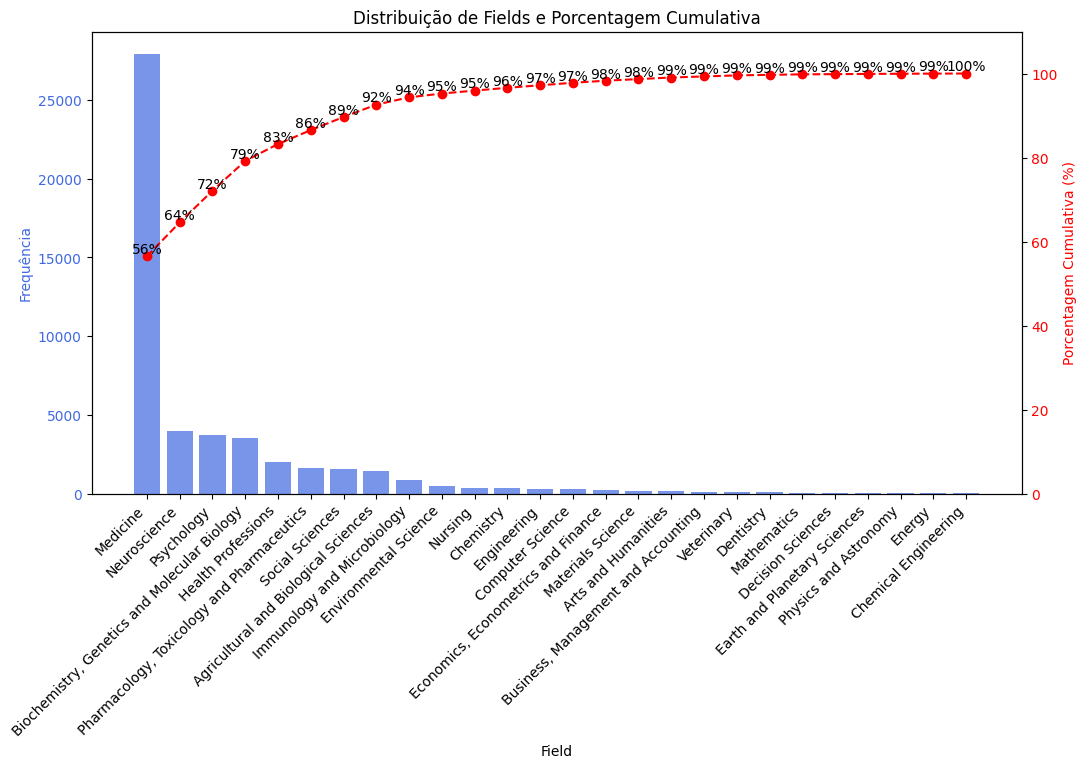

In [391]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada field
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['field', 'count']

# Ordenar por contagem
count_by_field = count_by_field.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa
total = count_by_field['count'].sum()
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['field'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Field')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['field'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Fields e Porcentagem Cumulativa')
plt.show()


####Publicações por área (df)

In [392]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['Área do conhecimento', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

                            Área do conhecimento  Contagem
0                                       Medicine     27959
1                                   Neuroscience      3993
2                                     Psychology      3726
3   Biochemistry, Genetics and Molecular Biology      3522
4                             Health Professions      1988
5     Pharmacology, Toxicology and Pharmaceutics      1644
6                                Social Sciences      1541
7           Agricultural and Biological Sciences      1459
8                    Immunology and Microbiology       863
9                          Environmental Science       448
10                                       Nursing       347
11                                     Chemistry       330
12                                   Engineering       297
13                              Computer Science       295
14           Economics, Econometrics and Finance       243
15                             Materials Science       1

In [393]:
%%bigquery work_ids_a_max_fs_3_t --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country

FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [394]:
work_ids_a_max_fs_3_t

id                            doi  \
0       2943062626             10.1111/acer.14075   
1       4401862105           10.4103/jms.jms_2_24   
2       2587002756       10.3389/fnins.2017.00042   
3       2587002756       10.3389/fnins.2017.00042   
4       3041787290  10.1016/s0140-6736(20)31494-x   
...            ...                            ...   
351703  2903891151        10.1124/jpet.118.254425   
351704  4392505209   10.1016/j.ejphar.2024.176486   
351705  2943817004       10.1177/1078155219843161   
351706  2943817004       10.1177/1078155219843161   
351707  2943817004       10.1177/1078155219843161   

                                                                                                                                                            title  \
0       Are Co‐users of Alcohol and Marijuana More Willing to Experience Consequences From Drinking? A Longitudinal Examination Among First‐Year College Students   
1                                                              Patterns of psychiatric morbidity among tribal patients in a tertiary referral hospital of Manipur   
2                         A Pulsed Electromagnetic Field Protects against Glutamate-Induced Excitotoxicity by Modulating the Endocannabinoid System in HT22 Cells   
3                         A Pulsed Electromagnetic Field Protects against Glutamate-Induced Excitotoxicity by Modulating the Endocannabinoid System in HT22 Cells   
4                                                                                                                                  The Lancet COVID-19 Commission   
...                                                                                                                                                           ...   
351703                                                             Synthetic Cannabinoid Hydroxypentyl Metabolites Retain Efficacy at Human Cannabinoid Receptors   
351704             5-HT2A receptors are involved in the pharmaco-toxicological effects of the synthetic cannabinoids JWH-018 and 5F-PB22: In vivo studies in mice   
351705                  What cancer patients actually know regarding medical cannabis? A cross-sectional survey with a critical analysis of the current attitudes   
351706                  What cancer patients actually know regarding medical cannabis? A cross-sectional survey with a critical analysis of the current attitudes   
351707                  What cancer patients actually know regarding medical cannabis? A cross-sectional survey with a critical analysis of the current attitudes   

           type  publication_year  max_score  \
0       article              2019     0.9997   
1       article              2024     0.9477   
2       article              2017     0.9858   
3       article              2017     0.9858   
4       article              2020     0.9960   
...         ...               ...        ...   
351703  article              2018     1.0000   
351704  article              2024     1.0000   
351705  article              2019     1.0000   
351706  article              2019     1.0000   
351707  article              2019     1.0000   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

/tmp/ipython-input-395-3013633053.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')


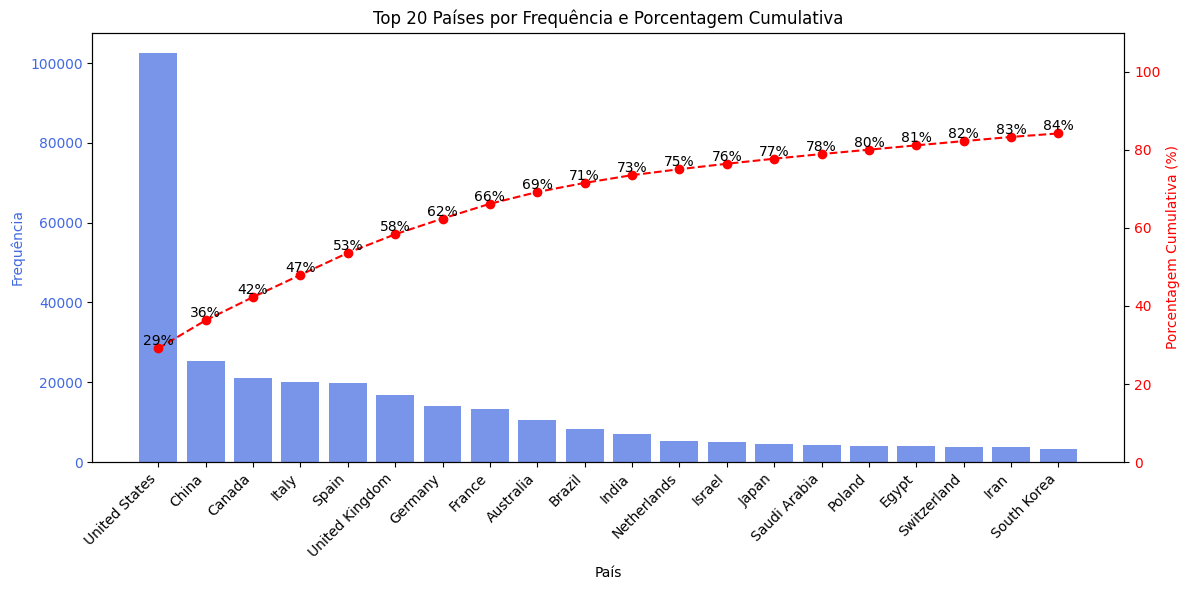

In [395]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada país
count_by_country = work_ids_a_max_fs_3_t['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']

# Ordenar por contagem
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa (baseada no total geral)
total = count_by_country['count'].sum()
count_by_country['cumulative_percentage'] = count_by_country['count'].cumsum() / total * 100

# Selecionar os 20 países com maior contagem para exibição
top20_countries = count_by_country.head(20)

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(top20_countries['country'], top20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(top20_countries['country'], top20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(top20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Top 20 Países por Frequência e Porcentagem Cumulativa')
plt.tight_layout()
plt.show()

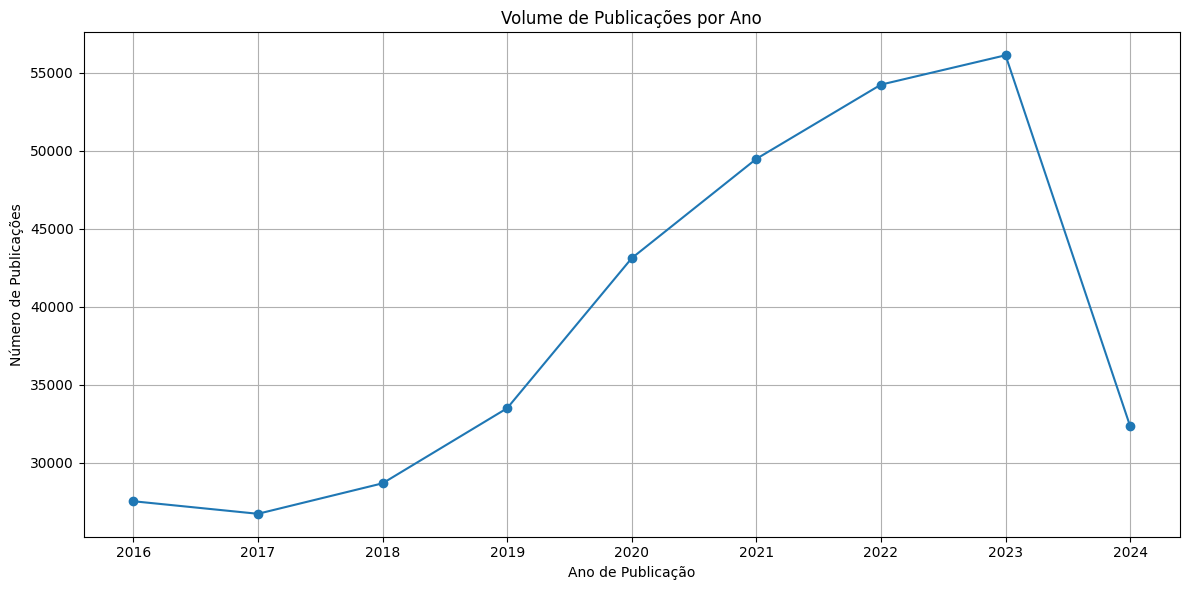

In [396]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar publicações por ano
publications_per_year = work_ids_a_max_fs_3_t['publication_year'].value_counts().reset_index()
publications_per_year.columns = ['publication_year', 'count']
publications_per_year = publications_per_year.sort_values(by='publication_year')

# Criar gráfico de linha
plt.figure(figsize=(12, 6))
plt.plot(publications_per_year['publication_year'], publications_per_year['count'], marker='o', linestyle='-')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Volume de Publicações por Ano')
plt.grid(True)
plt.tight_layout()
plt.show()

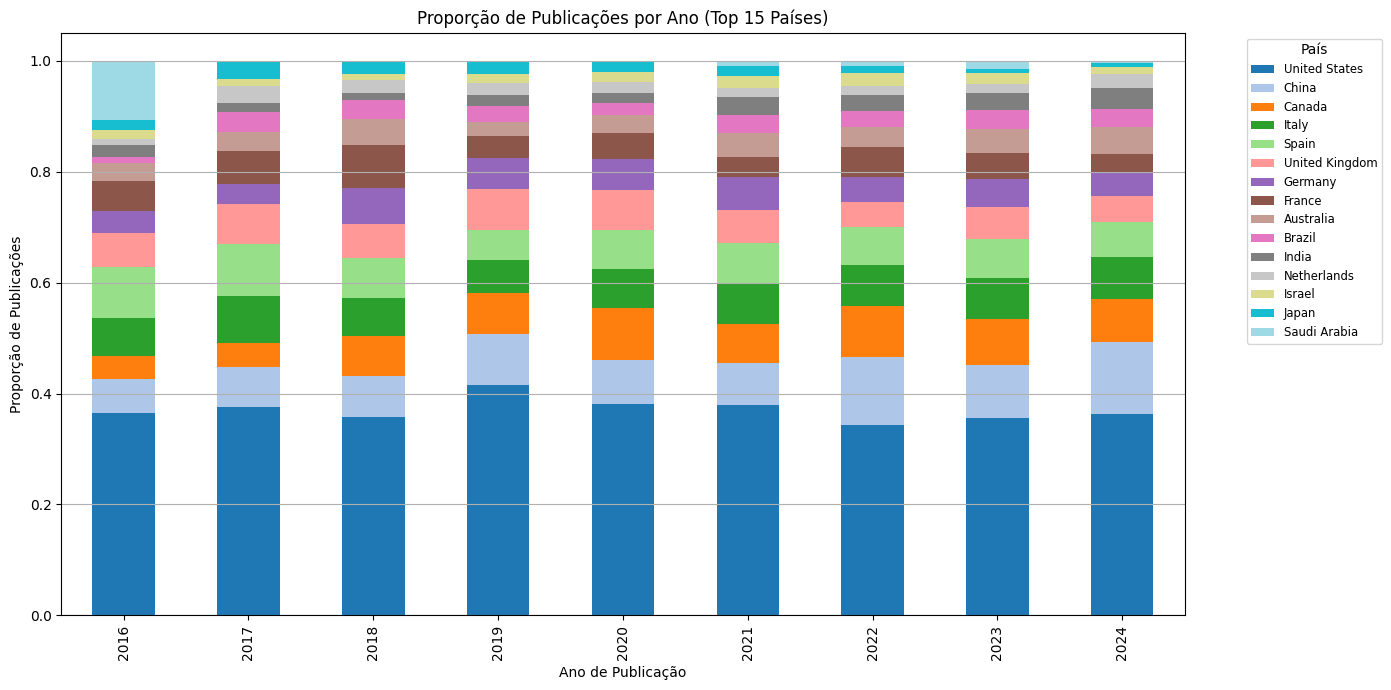

In [397]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3_t = pd.read_csv('seu_arquivo.csv')

# Agrupar por ano e país
publications_by_year_country = (
    work_ids_a_max_fs_3_t
    .groupby(['publication_year', 'country'])
    .size()
    .reset_index(name='count')
)

# Selecionar os 20 países com mais publicações no total
top_countries = (
    publications_by_year_country.groupby('country')['count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Filtrar apenas esses países
filtered_df = publications_by_year_country[publications_by_year_country['country'].isin(top_countries)]

# Pivotar: linhas = ano, colunas = país, valores = contagem
pivot_table = filtered_df.pivot(
    index='publication_year',
    columns='country',
    values='count'
).fillna(0).sort_index()

# Ordenar colunas com os países mais produtivos na base
ordered_columns = pivot_table.sum().sort_values(ascending=False).index
pivot_table = pivot_table[ordered_columns]

# Normalizar por linha para criar gráfico 100% empilhado
pivot_relative = pivot_table.div(pivot_table.sum(axis=1), axis=0)

# Plotar gráfico de barras empilhadas relativas
pivot_relative.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)

plt.xlabel('Ano de Publicação')
plt.ylabel('Proporção de Publicações')
plt.title('Proporção de Publicações por Ano (Top 15 Países)')
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [398]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['publication_year'].value_counts().reset_index()
count_by_field.columns = ['Ano de publicação', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

   Ano de publicação  Contagem
0               2022      7254
1               2023      7174
2               2021      7096
3               2020      6383
4               2024      5188
5               2019      5079
6               2018      4116
7               2017      3685
8               2016      3527


###Distribuição de publicação por área ao longo do tempo

In [399]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

# Generate distinct colors for each field using Seaborn's color palette
num_fields = len(count_by_year_field_percentage.columns)
colors = sns.color_palette("tab20", num_fields)  # Using 'tab20' for better color distinction

# Plot stacked area chart with improved color distinction
fig, ax = plt.subplots(figsize=(12, 6))
count_by_year_field_percentage.plot(kind='area', stacked=True, ax=ax, color=colors, alpha=0.7)

# Labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Percentage')
ax.set_title('Stacked Percentage of Fields Over the Years')
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

NameError: name 'count_by_year_field_percentage' is not defined

###Publicações por país

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar o número total de ocorrências por país (quantidade de vezes que aparece no dataset)
count_by_country = work_ids_a_max_fs_3['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Manter apenas os 20 países mais frequentes
top_20_countries = count_by_country.head(20).copy()

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_3)  # Total de linhas no dataset
top_20_countries['cumulative_percentage'] = top_20_countries['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para os 20 principais países
ax1.bar(top_20_countries['country'], top_20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Número de Ocorrências', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top_20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva de porcentagem cumulativa
ax2 = ax1.twinx()
ax2.plot(top_20_countries['country'], top_20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%) em relação ao total do dataset', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais na curva de porcentagem cumulativa
for i, txt in enumerate(top_20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Ocorrências por País e Porcentagem Cumulativa em relação ao Total do Dataset')
plt.show()


###Publicações por instituições

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada institution
count_by_field = work_ids_a_max_fs_yr_3['institution'].value_counts().reset_index()
count_by_field.columns = ['institution', 'count']

# Manter somente os 20 primeiros
count_by_field = count_by_field.head(20)

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['institution'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Institution')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['institution'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['institution'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Institutions e Porcentagem Cumulativa')
plt.show()


## Análise de tópicos (BERTopic)

In [ ]:
%%bigquery bertopic --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field--, d.display_name as subfield-- g.country,
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id



In [ ]:
len(bertopic)

###Seleção de área e export de .csv

In [ ]:
bertopic_df = bertopic[['title', 'abstract', 'publication_year','topic', 'field']]
df = bertopic_df[
    (bertopic_df['field'] == 'Dentistry')
]
len(df)

In [ ]:
len(df)

In [ ]:
df.to_csv(folder + '/Leticia/bertopic_leticia_dentistry.csv', index=False)

### Compilador de tópicos a partir de .csv do Drive

In [ ]:
import pandas as pd
import os
from google.colab import drive

# Define folder path
folder_path = '/content/drive/MyDrive/cientometria_resultados/Tópicos compilados'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Load and merge all CSVs, tagging with source filename
df_list = []
for file in csv_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df['source_file'] = file  # Add a column with the file name
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)

# Save merged DataFrame to CSV
output_path = os.path.join(folder_path, 'merged_result.csv')
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")


#ANPEC

##Coleta de dados da OpenAlex

###Extração de IDs



In [ ]:
from google.cloud import bigquery
from google.colab import auth
auth.authenticate_user()

client = bigquery.Client(project="insyspo")

In [ ]:
problems = [
    "green colonialism",
    "mineral dependency",
    "mineral sovereignty",
    "neoextractivism",
    "green capitalism",
    "green finance",
    "sacrifice zones",
    "climate justice",
    "greenwashing",
    "just transition",
    "technological dependency",
    "sustainable finance",
    "green bonds",
    "green extractivism",
    "global value chain",
    "productive chain",
    "resource governance"
]

problems1 = []

concepts = [
    "critical mineral",
    "critical metal",
    "critical material",
    "critical raw material",
    "strategic mineral",
    "strategic material",
    "key raw material",
    "rare metal",
    "green transition mineral",
    "green transition metal",
    "green transition material",
    "green transition raw material",
    "rare earth element",
    "battery metal",
    "raw material dependenc",
    "aluminium", "antimony", "arsenic", "barite", "beryllium",
    "bismuth", "cerium", "cesium", "chromium", "cobalt", "dysprosium", "erbium", "europium", "fluorspar",
    "gadolinium", "gallium", "germanium", "graphite", "hafnium", "holmium", "indium", "iridium",
    "lanthanum", "lithium", "lutetium",
    "manganese", "neodymium", "nickel", "niobium",
    "palladium", "platinum", "praseodymium", "rhodium", "rubidium", "ruthenium", "samarium",
    "scandium", "tantalum", "tellurium", "terbium", "thulium", "titanium", "tungsten",
    "uranium", "vanadium", "ytterbium", "yttrium", "zinc", "zirconium", "copper",
    "rare earth",
    "energy storage material"
]

def build_like_clauses(terms, field):
    if not terms:
        return ""  # Return empty string if no terms
    return "\n                OR ".join([f"LOWER({field}) LIKE '%{term.lower()}%'" for term in terms])

# Build clauses
problem_display_clause = build_like_clauses(problems, "display_name")
concept_display_clause = build_like_clauses(concepts, "display_name")
problem_abstract_clause = build_like_clauses(problems, "abstract")
concept_abstract_clause = build_like_clauses(concepts, "abstract")

# Compose WHERE conditions with safeguards
def make_where_clause(problem_clause, concept_clause):
    clauses = []
    if problem_clause:
        clauses.append(f"({problem_clause})")
    if concept_clause:
        clauses.append(f"({concept_clause})")
    return " AND ".join(clauses) if clauses else "TRUE"  # fallback so the query is always valid

works_where = make_where_clause(problem_display_clause, concept_display_clause)
abstract_where = make_where_clause(problem_abstract_clause, concept_abstract_clause)

# Final query
query = f"""
DROP TABLE IF EXISTS `insyspo.userdb_fernando_spolidorio.cm_work_ids_3`;

CREATE TABLE `insyspo.userdb_fernando_spolidorio.cm_work_ids_3` AS (
    SELECT DISTINCT id
    FROM (
        SELECT id
        FROM `insyspo.publicdb_openalex_2024_10_rm.works`
        WHERE {works_where}
        UNION ALL
        SELECT id
        FROM `insyspo.projectdb_cwts_summer_school_2023.works_abstracts`
        WHERE {abstract_where}
    )
);
"""

In [ ]:
# Execute the query
job = client.query(query)
job.result()  # Wait for completion
print("Query completed and table created.")

Query completed and table created.


In [ ]:
%%bigquery work_ids_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_3

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_3)

235

###Filtros

####Artigos e anos

In [ ]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS (

SELECT a.id, b.doi, b.title, b.type, b.publication_year
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works AS b ON a.id = b.id
WHERE b.type = 'article' and b.publication_year > 2000 and b.publication_year < 2025
);

Query is running:   0%|          |

""


In [ ]:
%%bigquery work_ids_a_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_a_3)

170

####Maxscores

In [ ]:
%%bigquery --project insyspo

DROP TABLE IF EXISTS insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3;
CREATE TABLE insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS (

WITH MaxScores AS (
    SELECT a.*, MAX(b.score) AS max_score
    FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_3 AS a
    JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
    GROUP BY all
)

select * from maxscores

)


Query is running:   0%|          |

""


In [ ]:
%%bigquery work_ids_a_max_3 --project insyspo
select * from insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_a_max_3)

167

In [ ]:
work_ids_a_max_3

,id,doi,title,type,publication_year,max_score
0,1987696208,10.5380/geo.v53i0.4218,A EXPLORAÇÃO MINERAL E O DESENVOLVIMENTO PARANAENSE: O SETOR DE CALCÁRIO NA REGIÃO METROPOLITANA DE CURITIBA,article,2003,0.7310
1,491184957,None,Küresel değer zincirleri içerisinde Türk gıda sektörünün konumu [Status of Turkish food sector within global value chains],article,2008,0.9823
2,2010318133,10.1080/09654310802682131,Suppliers and Strategies for Upgrading in Global Production Networks: The Case of a Supplier to the Global Automotive Industry in a High-cost Location,article,2009,0.9970
3,2380512553,None,Industry Analysis Based on the Global Value Chain Perspective of Baotou Rare Earth,article,2009,0.9078
4,3123427986,None,Reconstituting the Neostructuralist State: The Political Economy of Continuity with Change in Chilean Mining Policy,article,2010,0.9957
...,...,...,...,...,...,...
162,4399647416,10.1051/e3sconf/202453707007,Problems and prospects of green energy,article,2024,0.9700
163,4393965382,10.1016/j.erss.2024.103529,People of the sun: Local resistance and solar energy (in)justice in southern Portugal,article,2024,0.9934
164,4401777155,10.1111/jcms.13675,Climate and Energy Transitions in Times of Environmental Backlash? The European Union ‘Green Deal’ From Adoption to Implementation,article,2024,0.9767
165,4402099345,10.1093/yel/yeae004,"The European Green Deal: climate action, social impacts and just transition safeguards",article,2024,0.3765


###Fields & subfields

In [ ]:
%%bigquery work_ids_a_max_fs_3 --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield--, i.country, h.work_id
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
--JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
--JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
--JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON f.institution_id = i.id


Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(work_ids_a_max_fs_3)

348

In [ ]:
work_ids_a_max_fs_3.head()

,id,doi,title,type,publication_year,max_score,abstract,topic,field,subfield,problem_kw,concept_kw,all_keywords,has_critico
0,4383909041,10.1177/02637758231183719,From copper mining to data extractivism? Data worth making at Chile’s Data Observatory Foundation,article,2023,0.9747,"The public–private initiative Data Observatory Foundation was created to make large databases, such as those of astronomical observatories, available to expand and transfer of so-called “data-centric tasks” to various domains and thereby boost the development of the digital economy, data science and artificial intelligence in the country. However, in this article, we argue that data-centric initiatives like the Data Observatory Foundation may prove to be defuturing or enacting exhausted futures that reproduce the historical extractivism and coloniality of power in Latin America. Through a qualitative case study, we analyze the narrative and economic technologies of justification deployed by the Data Observatory Foundation to justify the value of its data and the organization itself. We discuss how the narratives and economic relationships developed by the Data Observatory Foundation manifest national wounds and technological dependency that enact a data-centric coloniality. Whether by attempting to define data as the copper of the future or establishing cloud computing credits as new salary tokens in the development of artificial intelligence, the Data Observatory Foundation reproduces past mentalities within innovation circuits. Rather than replicating futures based on modern colonial extractivist logics, we propose expanding possible engagements with data and speculating alternative designs.",Ethical Implications of Artificial Intelligence,Social Sciences,Safety Research,[technological dependency],"[copper, copper]",[],False
1,4383909041,10.1177/02637758231183719,From copper mining to data extractivism? Data worth making at Chile’s Data Observatory Foundation,article,2023,0.9747,"The public–private initiative Data Observatory Foundation was created to make large databases, such as those of astronomical observatories, available to expand and transfer of so-called “data-centric tasks” to various domains and thereby boost the development of the digital economy, data science and artificial intelligence in the country. However, in this article, we argue that data-centric initiatives like the Data Observatory Foundation may prove to be defuturing or enacting exhausted futures that reproduce the historical extractivism and coloniality of power in Latin America. Through a qualitative case study, we analyze the narrative and economic technologies of justification deployed by the Data Observatory Foundation to justify the value of its data and the organization itself. We discuss how the narratives and economic relationships developed by the Data Observatory Foundation manifest national wounds and technological dependency that enact a data-centric coloniality. Whether by attempting to define data as the copper of the future or establishing cloud computing credits as new salary tokens in the development of artificial intelligence, the Data Observatory Foundation reproduces past mentalities within innovation circuits. Rather than replicating futures based on modern colonial extractivist logics, we propose expanding possible engagements with data and speculating alternative designs.",Ethical Implications of Neuroenhancement Technologies,Neuroscience,Cognitive Neuroscience,[technological dependency],"[copper, copper]",[],False
2,4387843330,10.1016/j.heliyon.2023.e21348,"Evaluation of the effect of physical and chemical factors in the recovery of Cu, Pb and Fe from waste PCB through acid leaching",article,2023,1.0000,"Electronic waste recycling is a strategy that contributes to implement a circular economy model which include reuse, component and raw material recovery and minimum final deposition. Given the importance of reincorporating the components of electronic

In [ ]:
work_ids_a_max_fs_3[work_ids_a_max_fs_3['field'] == "Economics, Econometrics and Finance"].to_csv(folder + '/ANPEC (Economics)/articles.csv', index=False)

In [ ]:
work_ids_a_max_fs_3[
    work_ids_a_max_fs_3['field'] == "Economics, Econometrics and Finance"
]['id'].nunique()

52

In [ ]:
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field

,field,count
0,Engineering,100
1,Social Sciences,72
2,"Economics, Econometrics and Finance",66
3,Environmental Science,36
4,"Business, Management and Accounting",30
5,Energy,15
6,Agricultural and Biological Sciences,8
7,Arts and Humanities,6
8,Chemistry,3
9,Materials Science,3


## Análise de palavras-chaves identificadas

###Criação de colunas

####Criação das colunas problems_kw e concept_kw

In [ ]:
import pandas as pd
import re


# --- 2. Exceções para match exato ---
exact_match_words = {"tin", "lead"}

# --- 3. Função de extração robusta ---
def extract_keywords(text, keywords, exact_match_words):
    if pd.isna(text):
        return []
    text = text.lower()
    found = []
    for kw in keywords:
        kw_lc = kw.lower().strip()
        if kw_lc in exact_match_words:
            if re.search(rf'\b{re.escape(kw_lc)}\b', text):
                found.append(kw)
        else:
            if kw_lc in text:
                found.append(kw)
    return list(dict.fromkeys(found))

# --- 4. Normalizar listas ---
problems = [p.lower().strip() for p in problems]
concepts = [c.lower().strip() for c in concepts]

# --- 5. Aplicar no DataFrame ---
work_ids_a_max_fs_3["problem_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], problems, exact_match_words) +
                extract_keywords(row["abstract"], problems, exact_match_words),
    axis=1
)

work_ids_a_max_fs_3["concept_kw"] = work_ids_a_max_fs_3.apply(
    lambda row: extract_keywords(row["title"], concepts, exact_match_words) +
                extract_keywords(row["abstract"], concepts, exact_match_words),
    axis=1
)

# --- 6. Identificar casos problemáticos ---
no_concept_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["concept_kw"].apply(lambda x: len(x) == 0)
]

no_problem_rows = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["problem_kw"].apply(lambda x: len(x) == 0)
]

print("⚠️ Registros com ZERO conceitos detectados:", len(no_concept_rows))
print("⚠️ Registros com ZERO problemas detectados:", len(no_problem_rows))


⚠️ Registros com ZERO conceitos detectados: 0
⚠️ Registros com ZERO problemas detectados: 0


####Criação da coluna all_keywords

In [ ]:
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3.apply(
    lambda row: sorted(set(row["problem_kw"] + row["concept_kw"])),
    axis=1
)

work_ids_a_max_fs_3.head()

,id,doi,title,type,publication_year,max_score,abstract,topic,field,subfield,problem_kw,concept_kw,all_keywords
0,4383909041,10.1177/02637758231183719,From copper mining to data extractivism? Data worth making at Chile’s Data Observatory Foundation,article,2023,0.9747,"The public–private initiative Data Observatory Foundation was created to make large databases, such as those of astronomical observatories, available to expand and transfer of so-called “data-centric tasks” to various domains and thereby boost the development of the digital economy, data science and artificial intelligence in the country. However, in this article, we argue that data-centric initiatives like the Data Observatory Foundation may prove to be defuturing or enacting exhausted futures that reproduce the historical extractivism and coloniality of power in Latin America. Through a qualitative case study, we analyze the narrative and economic technologies of justification deployed by the Data Observatory Foundation to justify the value of its data and the organization itself. We discuss how the narratives and economic relationships developed by the Data Observatory Foundation manifest national wounds and technological dependency that enact a data-centric coloniality. Whether by attempting to define data as the copper of the future or establishing cloud computing credits as new salary tokens in the development of artificial intelligence, the Data Observatory Foundation reproduces past mentalities within innovation circuits. Rather than replicating futures based on modern colonial extractivist logics, we propose expanding possible engagements with data and speculating alternative designs.",Ethical Implications of Artificial Intelligence,Social Sciences,Safety Research,[technological dependency],"[copper, copper]","[copper, technological dependency]"
1,4383909041,10.1177/02637758231183719,From copper mining to data extractivism? Data worth making at Chile’s Data Observatory Foundation,article,2023,0.9747,"The public–private initiative Data Observatory Foundation was created to make large databases, such as those of astronomical observatories, available to expand and transfer of so-called “data-centric tasks” to various domains and thereby boost the development of the digital economy, data science and artificial intelligence in the country. However, in this article, we argue that data-centric initiatives like the Data Observatory Foundation may prove to be defuturing or enacting exhausted futures that reproduce the historical extractivism and coloniality of power in Latin America. Through a qualitative case study, we analyze the narrative and economic technologies of justification deployed by the Data Observatory Foundation to justify the value of its data and the organization itself. We discuss how the narratives and economic relationships developed by the Data Observatory Foundation manifest national wounds and technological dependency that enact a data-centric coloniality. Whether by attempting to define data as the copper of the future or establishing cloud computing credits as new salary tokens in the development of artificial intelligence, the Data Observatory Foundation reproduces past mentalities within innovation circuits. Rather than replicating futures based on modern colonial extractivist logics, we propose expanding possible engagements with data and speculating alternative designs.",Ethical Implications of Neuroenhancement Technologies,Neuroscience,Cognitive Neuroscience,[technological dependency],"[copper, copper]","[copper, technological dependency]"
2,4387843330,10.1016/j.heliyon.2023.e21348,"Evaluation of the effect of physical and chemical factors in the recovery of Cu, Pb and Fe from waste PCB through acid leaching",article,2023,1.0000,"Electronic waste recycling is a strategy that contributes to implement a circular economy model which include reuse, component and raw material recovery and minimum final deposition. Given the importance of 

In [ ]:
# Function to check if any item in the list contains 'critico' (case-insensitive)
def contains_critico(word_list):
    if isinstance(word_list, list):
        return any('material' in word.lower() for word in word_list if isinstance(word, str))
    return False

# Apply the filter
work_ids_a_max_fs_3['has_critico'] = work_ids_a_max_fs_3['all_keywords'].apply(contains_critico)

# Count total rows per year (no filter)
total_by_year = work_ids_a_max_fs_3['publication_year'].value_counts().reset_index()
total_by_year.columns = ['publication_year', 'total_count']

# Count only rows that contain 'critico'
filtered_by_year = (
    work_ids_a_max_fs_3[work_ids_a_max_fs_3['has_critico']]
    ['publication_year'].value_counts().reset_index()
)
filtered_by_year.columns = ['publication_year', 'critico_count']

# Merge both counts
merged = pd.merge(total_by_year, filtered_by_year, on='publication_year', how='left')

# Fill NaN in critico_count with 0 (in case some years have no matches)
merged['critico_count'] = merged['critico_count'].fillna(0).astype(int)

# Add percentage column
merged['percent_critico'] = (merged['critico_count'] / merged['total_count'] * 100).round(1)

# Sort by year
merged = merged.sort_values(by='publication_year')

# Show the final DataFrame
print(merged)


    publication_year  total_count  critico_count  percent_critico
16              2003            3              0              0.0
17              2008            3              0              0.0
14              2009            4              0              0.0
13              2010            4              0              0.0
10              2011            7              0              0.0
8               2012            9              0              0.0
15              2013            4              0              0.0
11              2014            6              0              0.0
6               2015           11              0              0.0
9               2016            9              0              0.0
12              2017            5              0              0.0
7               2018           10              0              0.0
5               2019           20              1              5.0
4               2020           21              2              9.5
3         

###20 combinações de kw mais comuns por área do conhecimento

In [ ]:
df=work_ids_a_max_fs_3
df["all_keywords"] = df["all_keywords"].apply(lambda x: tuple(x))  # Convert lists to tuples

df_grouped = (
    df.groupby(["field", "all_keywords"])
    .size()
    .reset_index(name="count")
)

# Get top 10 counts per field
df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))

df_top10_3


/tmp/ipython-input-61-3636565974.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top10_3 = df_grouped.groupby("field", group_keys=False).apply(lambda x: x.nlargest(20, "count"))


,field,all_keywords,count
5,Agricultural and Biological Sciences,"(global value chain, zinc)",2
1,Agricultural and Biological Sciences,"(copper, resource governance)",1
0,Agricultural and Biological Sciences,"(climate justice, copper)",1
2,Agricultural and Biological Sciences,"(critical metal, sacrifice zones)",1
3,Agricultural and Biological Sciences,"(critical mineral, just transition, lithium, sacrifice zones)",1
...,...,...,...
196,Social Sciences,"(critical raw material, lithium, rare earth, sacrifice zones)",2
203,Social Sciences,"(green extractivism, lithium, resource governance)",2
211,Social Sciences,"(nickel, resource governance)",2
167,Social Sciences,"(arsenic, just transition, nickel)",1


###Volume e representatividade de palavras-chaves de Problema



In [ ]:
from collections import Counter
import pandas as pd

# Flatten all lists of keywords into one big list
all_keywords_flat = work_ids_a_max_fs_3['problem_kw'].dropna().explode()

# Count keyword frequencies
keyword_counts = Counter(all_keywords_flat)

# Convert to DataFrame
keyword_df = pd.DataFrame(keyword_counts.items(), columns=['keyword', 'count'])

# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Sort by most common
keyword_df = keyword_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

keyword_df.to_csv(folder + 'problems_kw_distr.csv', index=False)

                     keyword  count  percent
0         global value chain    155     36.2
1        resource governance     51     11.9
2         green extractivism     47     11.0
3            just transition     44     10.3
4            sacrifice zones     36      8.4
5           productive chain     21      4.9
6            climate justice     21      4.9
7              green finance     13      3.0
8               greenwashing     10      2.3
9           green capitalism      7      1.6
10         green colonialism      7      1.6
11           neoextractivism      6      1.4
12       sustainable finance      4      0.9
13        mineral dependency      4      0.9
14  technological dependency      2      0.5


###Evolução Temporal das Principais Palavras-chave de Problema

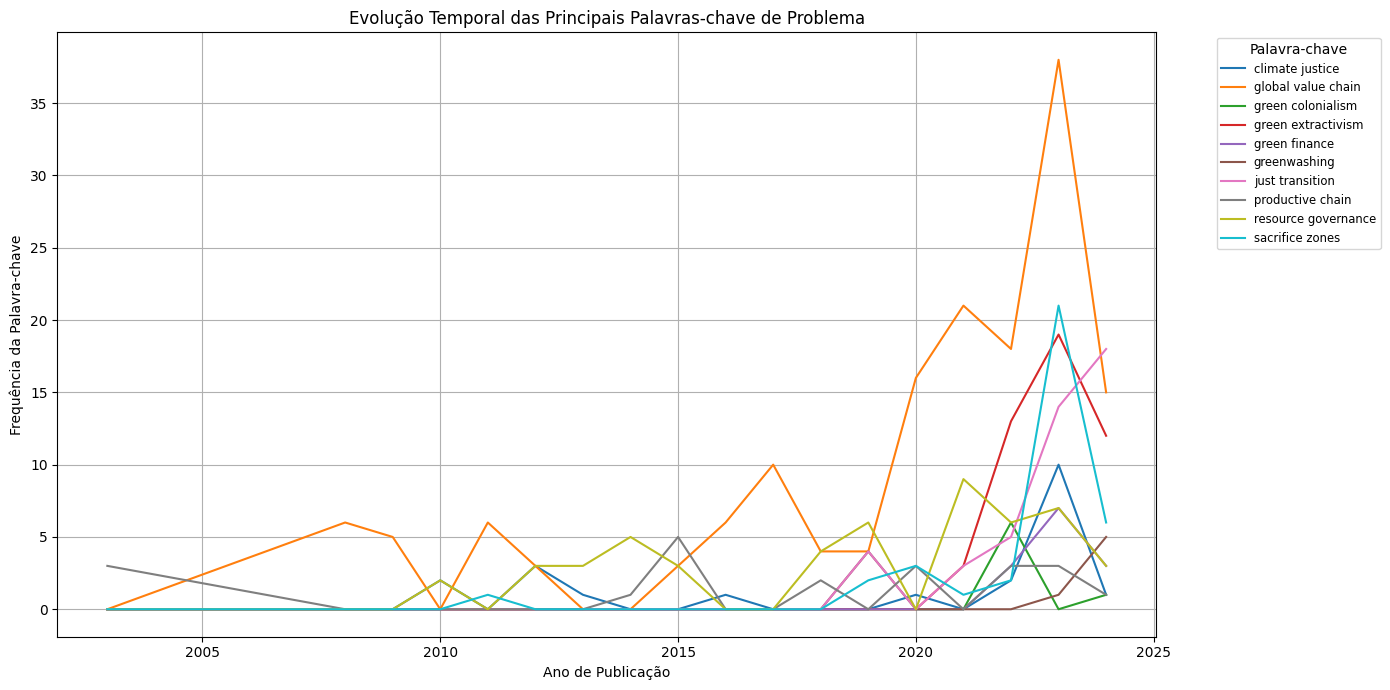

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'problem_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Problema')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume e representatividade de palavras-chaves de Problema

In [ ]:
# Compute total count of all keywords
total_keywords = keyword_df['count'].sum()

# Add percentage column
keyword_df['percent'] = (keyword_df['count'] / total_keywords * 100).round(1)

# Show full result without truncation
with pd.option_context('display.max_rows', None):
    print(keyword_df)

                     keyword  count  percent
0         global value chain    155     36.2
1        resource governance     51     11.9
2         green extractivism     47     11.0
3            just transition     44     10.3
4            sacrifice zones     36      8.4
5           productive chain     21      4.9
6            climate justice     21      4.9
7              green finance     13      3.0
8               greenwashing     10      2.3
9           green capitalism      7      1.6
10         green colonialism      7      1.6
11           neoextractivism      6      1.4
12       sustainable finance      4      0.9
13        mineral dependency      4      0.9
14  technological dependency      2      0.5


###Evolução Temporal das Principais Palavras-chave de Conceito

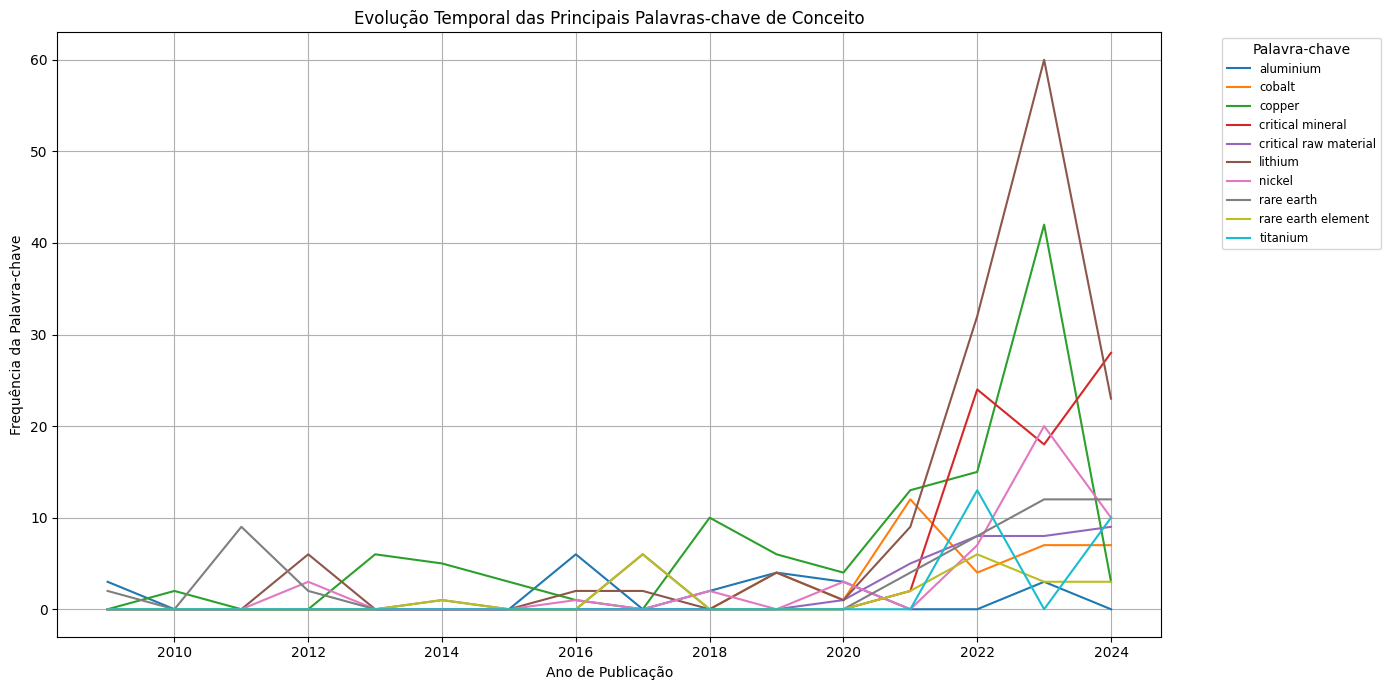

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Nome da coluna com as palavras-chave
keyword_col = 'concept_kw'  # você pode trocar por outro nome como 'keywords_list', etc.

# Explodir a coluna de palavras-chave
exploded_df = work_ids_a_max_fs_3[['publication_year', keyword_col]].explode(keyword_col).dropna()

# Contar quantas vezes cada palavra aparece por ano
keyword_year_counts = (
    exploded_df
    .groupby(['publication_year', keyword_col])
    .size()
    .reset_index(name='count')
)

# Selecionar as top 10 palavras mais frequentes
top_keywords = (
    keyword_year_counts
    .groupby(keyword_col)['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtrar apenas essas palavras
filtered_df = keyword_year_counts[keyword_year_counts[keyword_col].isin(top_keywords)]

# Pivotar a tabela: linhas = ano, colunas = palavra-chave, valores = contagem
pivot = filtered_df.pivot(index='publication_year', columns=keyword_col, values='count').fillna(0).sort_index()

# Plotar gráfico de linhas
plt.figure(figsize=(14, 7))
for keyword in pivot.columns:
    plt.plot(pivot.index, pivot[keyword], label=keyword)

plt.xlabel('Ano de Publicação')
plt.ylabel('Frequência da Palavra-chave')
plt.title('Evolução Temporal das Principais Palavras-chave de Conceito')
plt.legend(title='Palavra-chave', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


###Volume de kw por área

In [ ]:
import pandas as pd

# Step 1: Calculate total count per field
field_order = (
    df_top10_3.groupby('field')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

# Step 2: Sort df_top10_3 by field (with custom order) and then by count descending
df_top10_3_sorted = (
    df_top10_3
    .assign(field=pd.Categorical(df_top10_3['field'], categories=field_order, ordered=True))
    .sort_values(by=['field', 'count'], ascending=[True, False])
    .reset_index(drop=True)
)

df_top10_3_sorted

,field,all_keywords,count
0,Engineering,"(copper, resource governance)",9
1,Engineering,"(copper, global value chain)",4
2,Engineering,"(critical mineral, gallium, germanium, global value chain, rare earth, titanium)",4
3,Engineering,"(critical mineral, global value chain, rare earth, rare earth element)",4
4,Engineering,"(copper, productive chain)",3
...,...,...,...
124,Psychology,"(productive chain, rare earth)",1
125,Psychology,"(sacrifice zones, uranium)",1
126,Earth and Planetary Sciences,"(global value chain, rare earth)",1
127,Neuroscience,"(copper, technological dependency)",1


###Consulta de kw para consultar artigos

####Consulta de kw não encontradas

In [ ]:
all_found_problems = set([kw.lower() for sublist in work_ids_a_max_fs_3["problem_kw"] for kw in sublist])
all_found_concepts = set([kw.lower() for sublist in work_ids_a_max_fs_3["concept_kw"] for kw in sublist])

# Quais não foram encontradas?
problems_not_found = sorted(set(problems) - all_found_problems)
concepts_not_found = sorted(set(concepts) - all_found_concepts)

# Mostrar resultados
print("❌ Palavras-chave de 'problems' que não tiveram nenhum match:")
print(problems_not_found)

print("\n❌ Palavras-chave de 'concepts' que não tiveram nenhum match:")
print(concepts_not_found)

❌ Palavras-chave de 'problems' que não tiveram nenhum match:
['green\xa0bonds', 'mineral sovereignty']

❌ Palavras-chave de 'concepts' que não tiveram nenhum match:
['barite', 'battery metal', 'beryllium', 'cerium', 'energy storage material', 'erbium', 'europium', 'gadolinium', 'green transition material', 'green transition metal', 'green transition mineral', 'green transition raw material', 'hafnium', 'holmium', 'iridium', 'lanthanum', 'lutetium', 'praseodymium', 'raw material dependenc', 'rhodium', 'rubidium', 'ruthenium', 'samarium', 'scandium', 'strategic material', 'tellurium', 'terbium', 'thulium', 'vanadium', 'ytterbium', 'yttrium', 'zirconium']


In [ ]:
from collections import Counter
import pandas as pd
pd.set_option('display.max_colwidth', None)

# Define the keyword to check
keyword_to_check = "epistemic justice"

# Ensure all_keywords is a list
work_ids_a_max_fs_3["all_keywords"] = work_ids_a_max_fs_3["all_keywords"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Filter rows that include the keyword
filtered = work_ids_a_max_fs_3[
    work_ids_a_max_fs_3["all_keywords"].apply(lambda x: keyword_to_check in x)
]

# Convert list of keywords to tuple (for grouping), preserving order (or use sorted(x) if order doesn’t matter)
filtered["keyword_combination"] = filtered["all_keywords"].apply(lambda x: tuple(x))

# Group by field and keyword combination
grouped = (
    filtered.groupby(["field", "keyword_combination", "title", "abstract"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Show result
grouped


,field,keyword_combination,title,abstract,count


##Análise de publicações

###Publicações por área do conhecimento

/tmp/ipython-input-103-3132261924.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')


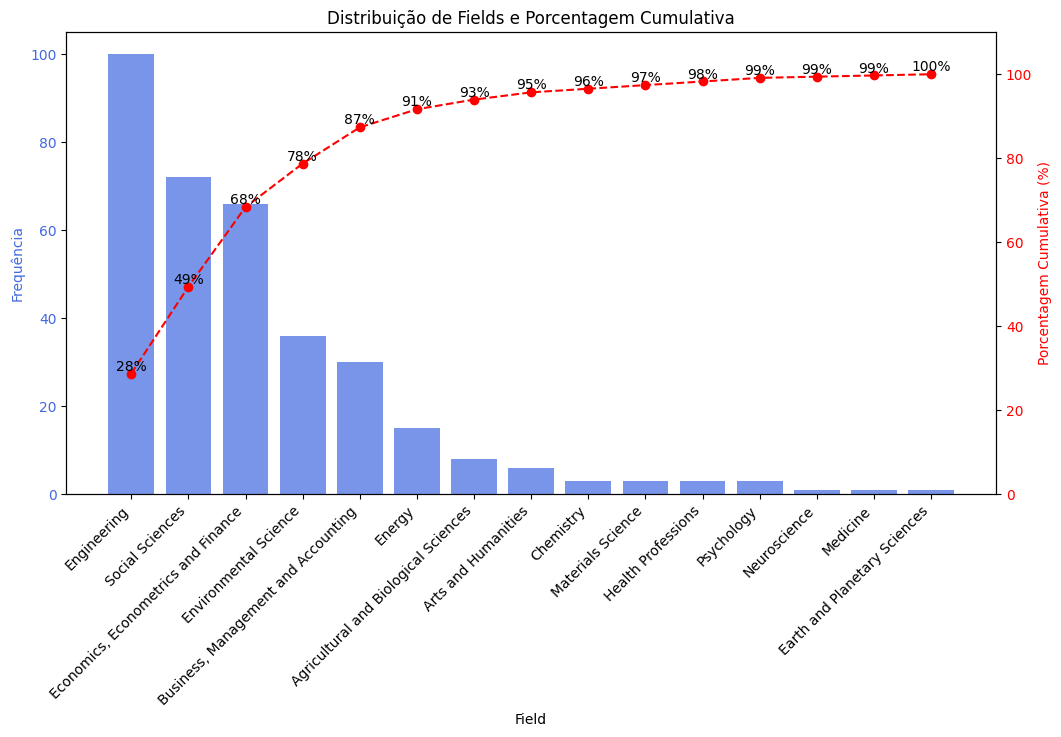

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada field
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['field', 'count']

# Ordenar por contagem
count_by_field = count_by_field.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa
total = count_by_field['count'].sum()
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['field'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Field')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['field'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['field'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Fields e Porcentagem Cumulativa')
plt.show()


####Publicações por área (df)

In [ ]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['field'].value_counts().reset_index()
count_by_field.columns = ['Área do conhecimento', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

                    Área do conhecimento  Contagem
0                            Engineering       100
1                        Social Sciences        72
2    Economics, Econometrics and Finance        66
3                  Environmental Science        36
4    Business, Management and Accounting        30
5                                 Energy        15
6   Agricultural and Biological Sciences         8
7                    Arts and Humanities         6
8                              Chemistry         3
9                      Materials Science         3
10                    Health Professions         3
11                            Psychology         3
12                          Neuroscience         1
13                              Medicine         1
14          Earth and Planetary Sciences         1


In [ ]:
%%bigquery work_ids_a_max_fs_3_t --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field, d.display_name as subfield, i.country

FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
work_ids_a_max_fs_3_t

id                            doi  \
0    4402099345            10.1093/yel/yeae004   
1    4402099345            10.1093/yel/yeae004   
2    4367681901  10.1080/02646811.2023.2190689   
3    4367681901  10.1080/02646811.2023.2190689   
4    4367681901  10.1080/02646811.2023.2190689   
..          ...                            ...   
254  4311963606          10.32992/erlacs.10939   
255  4311963606          10.32992/erlacs.10939   
256  4386810104      10.1017/s1060150323000360   
257  4386810104      10.1017/s1060150323000360   
258  4386810104      10.1017/s1060150323000360   

                                                                                                  title  \
0                The European Green Deal: climate action, social impacts and just transition safeguards   
1                The European Green Deal: climate action, social impacts and just transition safeguards   
2                                    Pathways of scholarship for energy justice and the social contract   
3                                    Pathways of scholarship for energy justice and the social contract   
4                                    Pathways of scholarship for energy justice and the social contract   
..                                                                                                  ...   
254  Green colonialism in Latin America? Towards a new research agenda for the global energy transition   
255  Green colonialism in Latin America? Towards a new research agenda for the global energy transition   
256                                                                                          Extraction   
257                                                                                          Extraction   
258                                                                                          Extraction   

        type  publication_year  max_score  \
0    article              2024     0.3765   
1    article              2024     0.3765   
2    article              2023     0.9048   
3    article              2023     0.9048   
4    article              2023     0.9048   
..       ...               ...        ...   
254  article              2022     0.9324   
255  article              2022     0.9324   
256  article              2023     0.9215   
257  article              2023     0.9215   
258  article              2023     0.9215   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

/tmp/ipython-input-37-3013633053.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')


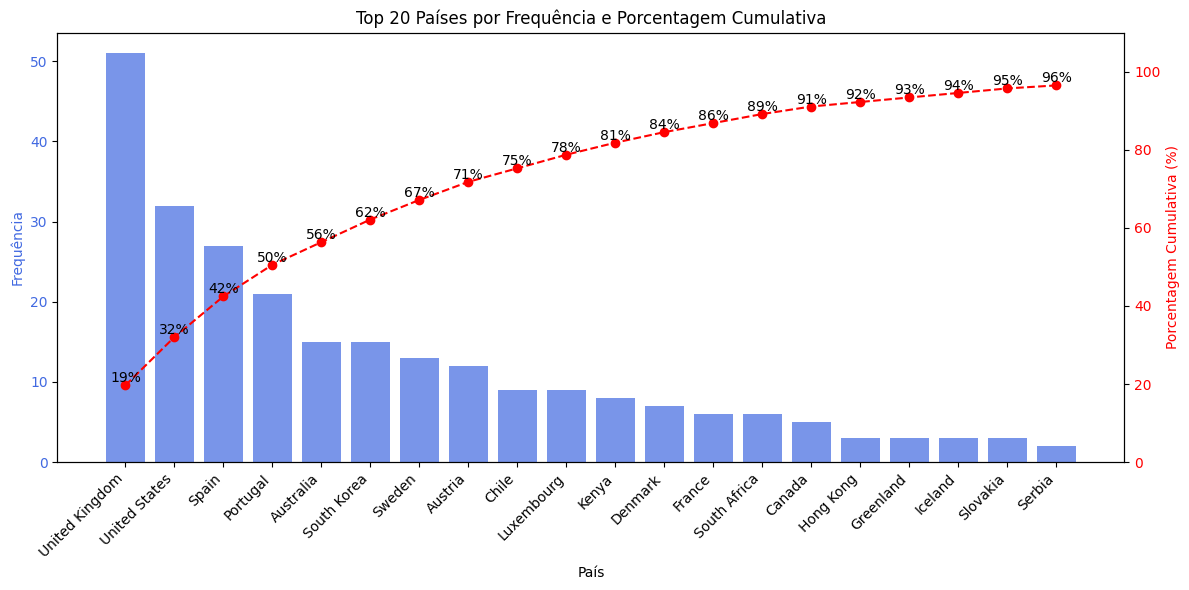

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada país
count_by_country = work_ids_a_max_fs_3_t['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']

# Ordenar por contagem
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Calcular a porcentagem cumulativa (baseada no total geral)
total = count_by_country['count'].sum()
count_by_country['cumulative_percentage'] = count_by_country['count'].cumsum() / total * 100

# Selecionar os 20 países com maior contagem para exibição
top20_countries = count_by_country.head(20)

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(top20_countries['country'], top20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(top20_countries['country'], top20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(top20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Top 20 Países por Frequência e Porcentagem Cumulativa')
plt.tight_layout()
plt.show()

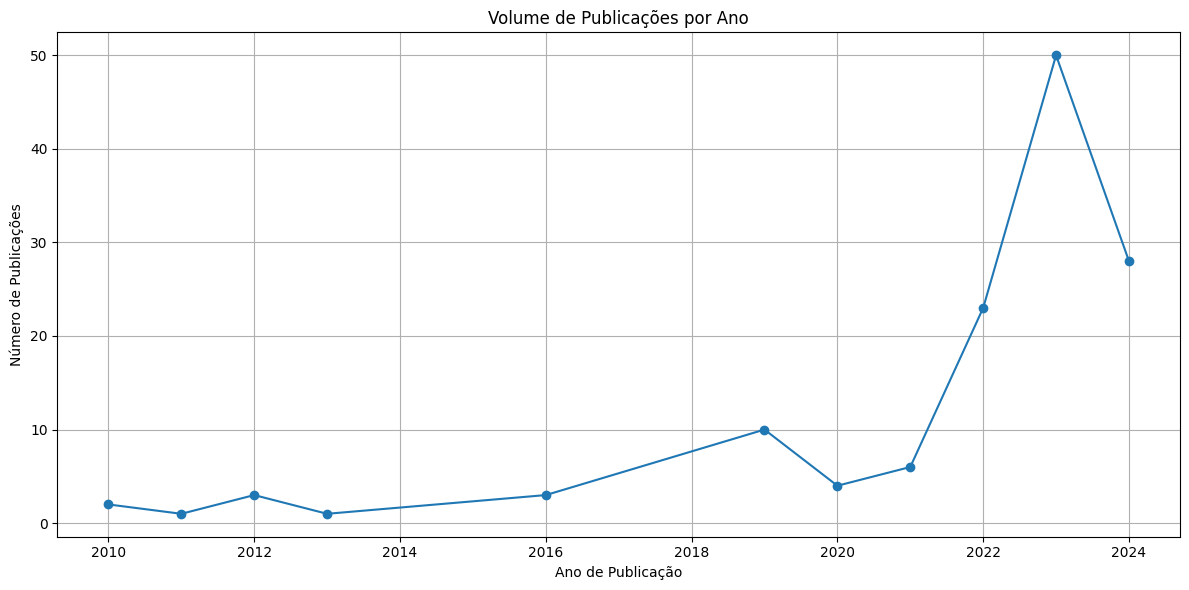

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3 = pd.read_csv('seu_arquivo.csv')

# Contar publicações por ano
publications_per_year = work_ids_a_max_fs_3['publication_year'].value_counts().reset_index()
publications_per_year.columns = ['publication_year', 'count']
publications_per_year = publications_per_year.sort_values(by='publication_year')

# Criar gráfico de linha
plt.figure(figsize=(12, 6))
plt.plot(publications_per_year['publication_year'], publications_per_year['count'], marker='o', linestyle='-')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Publicações')
plt.title('Volume de Publicações por Ano')
plt.grid(True)
plt.tight_layout()
plt.show()

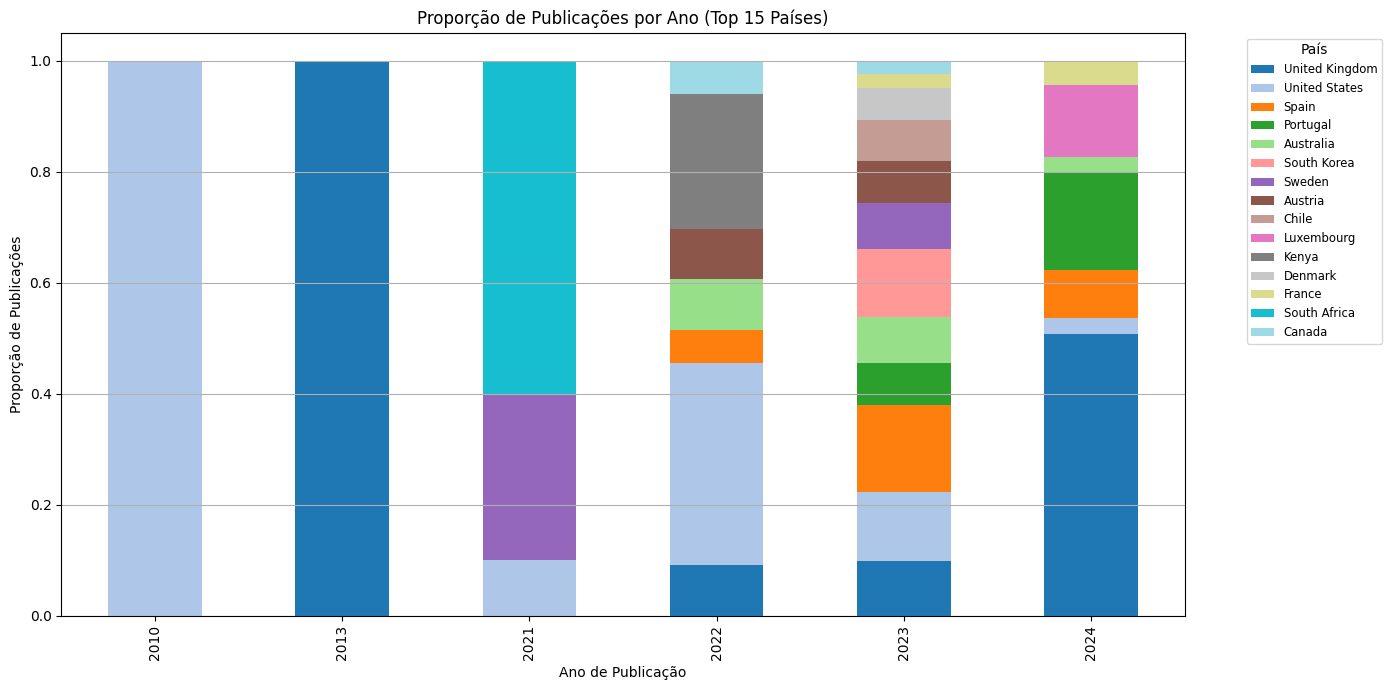

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_3_t = pd.read_csv('seu_arquivo.csv')

# Agrupar por ano e país
publications_by_year_country = (
    work_ids_a_max_fs_3_t
    .groupby(['publication_year', 'country'])
    .size()
    .reset_index(name='count')
)

# Selecionar os 20 países com mais publicações no total
top_countries = (
    publications_by_year_country.groupby('country')['count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Filtrar apenas esses países
filtered_df = publications_by_year_country[publications_by_year_country['country'].isin(top_countries)]

# Pivotar: linhas = ano, colunas = país, valores = contagem
pivot_table = filtered_df.pivot(
    index='publication_year',
    columns='country',
    values='count'
).fillna(0).sort_index()

# Ordenar colunas com os países mais produtivos na base
ordered_columns = pivot_table.sum().sort_values(ascending=False).index
pivot_table = pivot_table[ordered_columns]

# Normalizar por linha para criar gráfico 100% empilhado
pivot_relative = pivot_table.div(pivot_table.sum(axis=1), axis=0)

# Plotar gráfico de barras empilhadas relativas
pivot_relative.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)

plt.xlabel('Ano de Publicação')
plt.ylabel('Proporção de Publicações')
plt.title('Proporção de Publicações por Ano (Top 15 Países)')
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada área do conhecimento
count_by_field = work_ids_a_max_fs_3['publication_year'].value_counts().reset_index()
count_by_field.columns = ['Ano de publicação', 'Contagem']

# Exibir o DataFrame
print(count_by_field)

    Ano de publicação  Contagem
0                2023        50
1                2024        28
2                2022        23
3                2019        10
4                2021         6
5                2020         4
6                2016         3
7                2012         3
8                2010         2
9                2011         1
10               2013         1


###Distribuição de publicação por área ao longo do tempo

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

# Generate distinct colors for each field using Seaborn's color palette
num_fields = len(count_by_year_field_percentage.columns)
colors = sns.color_palette("tab20", num_fields)  # Using 'tab20' for better color distinction

# Plot stacked area chart with improved color distinction
fig, ax = plt.subplots(figsize=(12, 6))
count_by_year_field_percentage.plot(kind='area', stacked=True, ax=ax, color=colors, alpha=0.7)

# Labels and title
ax.set_xlabel('Publication Year')
ax.set_ylabel('Percentage')
ax.set_title('Stacked Percentage of Fields Over the Years')
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

NameError: name 'count_by_year_field_percentage' is not defined

###Publicações por país

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar o número total de ocorrências por país (quantidade de vezes que aparece no dataset)
count_by_country = work_ids_a_max_fs_yr_3['country'].value_counts().reset_index()
count_by_country.columns = ['country', 'count']
count_by_country = count_by_country.sort_values(by='count', ascending=False)

# Manter apenas os 20 países mais frequentes
top_20_countries = count_by_country.head(20).copy()

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)  # Total de linhas no dataset
top_20_countries['cumulative_percentage'] = top_20_countries['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para os 20 principais países
ax1.bar(top_20_countries['country'], top_20_countries['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('País')
ax1.set_ylabel('Número de Ocorrências', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(top_20_countries['country'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva de porcentagem cumulativa
ax2 = ax1.twinx()
ax2.plot(top_20_countries['country'], top_20_countries['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%) em relação ao total do dataset', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais na curva de porcentagem cumulativa
for i, txt in enumerate(top_20_countries['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Ocorrências por País e Porcentagem Cumulativa em relação ao Total do Dataset')
plt.show()


###Publicações por instituições

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Supondo que o dataframe já esteja carregado
# work_ids_a_max_fs_yr_3 = pd.read_csv('seu_arquivo.csv')

# Contar a ocorrência de cada institution
count_by_field = work_ids_a_max_fs_yr_3['institution'].value_counts().reset_index()
count_by_field.columns = ['institution', 'count']

# Manter somente os 20 primeiros
count_by_field = count_by_field.head(20)

# Calcular a porcentagem cumulativa em relação ao total de linhas do dataset
total_rows = len(work_ids_a_max_fs_yr_3)
count_by_field['cumulative_percentage'] = count_by_field['count'].cumsum() / total_rows * 100

# Criar gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras
ax1.bar(count_by_field['institution'], count_by_field['count'], color='royalblue', alpha=0.7)
ax1.set_xlabel('Institution')
ax1.set_ylabel('Frequência', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(count_by_field['institution'], rotation=45, ha='right')

# Criar um segundo eixo Y para a curva
ax2 = ax1.twinx()
ax2.plot(count_by_field['institution'], count_by_field['cumulative_percentage'], color='red', marker='o', linestyle='dashed')
ax2.set_ylabel('Porcentagem Cumulativa (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Adicionar rótulos sem casas decimais
for i, txt in enumerate(count_by_field['cumulative_percentage']):
    ax2.text(i, txt, f'{int(txt)}%', color='black', fontsize=10, ha='center', va='bottom')

# Exibir gráfico
plt.title('Distribuição de Institutions e Porcentagem Cumulativa')
plt.show()


## Análise de tópicos (BERTopic)

In [ ]:
%%bigquery bertopic --project insyspo

SELECT a.*, f.abstract as abstract, c.display_name as topic, e.display_name AS field--, d.display_name as subfield-- g.country,
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id



Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
len(bertopic)

348

###Seleção de área e export de .csv

In [ ]:
bertopic_df = bertopic[['title', 'abstract', 'publication_year','topic', 'field']]
df = bertopic_df[
    (bertopic_df['field'] == 'Economics, Econometrics and Finance')
]
df

title  \
2                                 Public and Private Firms in Natural Resource Industry: Comparing the Development of the Lithium Industry in South America   
3                                Küresel değer zincirleri içerisinde Türk gıda sektörünün konumu [Status of Turkish food sector within global value chains]   
7                                                                                  Two‐dimensional governances and industrial international competitiveness   
12                                                   Community and company capacity: the challenge of resource-led development in Zambia's 'New Copperbelt'   
23   Suppliers and Strategies for Upgrading in Global Production Networks: The Case of a Supplier to the Global Automotive Industry in a High-cost Location   
..                                                                                                                                                      ...   
318                                                             Development of Titanium Production in Ukraine: Evolving Prospects Based on National R&amp;D   
326                                                                                                                  Problems and prospects of green energy   
330                                                     Modernization of Strategic Industries of the National Economy in the Conditions of Decentralization   
341                      Climate and Energy Transitions in Times of Environmental Backlash? The European Union ‘Green Deal’ From Adoption to Implementation   
347                                                                  The European Green Deal: climate action, social impacts and just transition safeguards   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [ ]:
len(df)

66

In [ ]:
df.to_csv(folder + '/ANPEC (Economics)/bertopic_economics.csv', index=False)

### Compilador de tópicos a partir de .csv do Drive

In [ ]:
import pandas as pd
import os
from google.colab import drive

# Define folder path
folder_path = '/content/drive/MyDrive/cientometria_resultados/Tópicos compilados'

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Load and merge all CSVs, tagging with source filename
df_list = []
for file in csv_files:
    df = pd.read_csv(os.path.join(folder_path, file))
    df['source_file'] = file  # Add a column with the file name
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)

# Save merged DataFrame to CSV
output_path = os.path.join(folder_path, 'merged_result.csv')
merged_df.to_csv(output_path, index=False)

print(f"Merged CSV saved to: {output_path}")


#WIP

In [ ]:
%%bigquery work_ids_a_max_country --project insyspo

SELECT a.id, i.country, h.*
FROM insyspo.userdb_fernando_spolidorio.cm_work_ids_a_maxscores_3 AS a
--JOIN insyspo.publicdb_openalex_2024_10_rm.works_topics AS b ON a.id = b.work_id
--JOIN insyspo.publicdb_openalex_2024_10_rm.topics AS c ON b.topic_id = c.id
--JOIN insyspo.publicdb_openalex_2024_10_rm.subfields AS d ON c.subfield = d.id
--JOIN insyspo.publicdb_openalex_2024_10_rm.fields AS e ON c.field = e.id
--JOIN insyspo.projectdb_cwts_summer_school_2023.works_abstracts f ON a.id = f.id
--JOIN insyspo.publicdb_openalex_2024_10_rm.works g ON a.id = g.id
JOIN insyspo.publicdb_openalex_2024_10_rm.works_authorships AS h ON a.id = h.work_id
JOIN insyspo.publicdb_openalex_2024_10_rm.institutions AS i ON h.institution_id = i.id



Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
# 1. Filter IDs that appear at least twice
filtered_df = work_ids_a_max_country[
    work_ids_a_max_country['id'].isin(
        work_ids_a_max_country['id'].value_counts()[lambda x: x >= 2].index
    )
]

# 2. Sort by 'id'
filtered_df_sorted = filtered_df.sort_values('id')

filtered_df_sorted[['id','country']]

,id,country
17591,25084758,United States
2872,25084758,United States
15068,34317772,Australia
820,34317772,Australia
10220,34317772,Australia
...,...,...
18018,4402568861,Taiwan
6937,4402568861,India
22063,4402568861,China
10960,4402568861,India


In [ ]:
import pandas as pd

# 1) Read as strings
coords = pd.read_csv(
    '/content/drive/MyDrive/cientometria_resultados/Country networks (Gephi)/countries latlong 2.csv',
    dtype=str
)

# 2) Function to fix each coordinate value
def fix_coord(value):
    if pd.isna(value):
        return None
    # Remove all dots
    digits = value.replace('.', '')
    # If too short, return NaN
    if len(digits) <= 6:
        return None
    # Insert decimal before last 6 digits
    fixed = digits[:-6] + '.' + digits[-6:]
    return float(fixed)

# 3) Apply to both columns
coords['latitude'] = coords['latitude'].apply(fix_coord)
coords['longitude'] = coords['longitude'].apply(fix_coord)

# 4) Inspect
print(coords.head())


  country   latitude  longitude                  name
0      AD  42.546245   1.601554               Andorra
1      AE  23.424076  53.847818  United Arab Emirates
2      AF   3.393911  67.709953           Afghanistan
3      AG  17.060816 -61.796428   Antigua and Barbuda
4      AI  18.220554 -63.068615              Anguilla


In [ ]:
# ✅ Step 1: Clean coords (done previously)
# coords now has clean 'latitude', 'longitude', 'name'

# ✅ Step 2: Merge on country = name
merged_df = filtered_df_sorted.merge(
    coords[['name', 'latitude', 'longitude']],
    left_on='country',
    right_on='name',
    how='left'   # use 'left' to keep all rows from filtered_df_sorted
)

# ✅ Step 3: Drop redundant 'name' column if you don’t need it
merged_df = merged_df.drop(columns=['name'])

merged_df


,id,country,work_id,author_id,raw_affiliation_string,author_position,author_order,institution_id,latitude,longitude
0,25084758,United States,25084758,5102412187,None,last,3,2799863703,3.709024,-95.712891
1,25084758,United States,25084758,5050489657,None,first,1,4210103952,3.709024,-95.712891
2,34317772,Australia,34317772,5047994012,None,last,3,118347636,-25.274398,133.775136
3,34317772,Australia,34317772,5030590660,None,first,1,82951845,-25.274398,133.775136
4,34317772,Australia,34317772,5009264809,None,middle,2,149704539,-25.274398,133.775136
...,...,...,...,...,...,...,...,...,...,...
29426,4402568861,Taiwan,4402568861,5021656897,None,middle,3,107470533,2.369781,120.960515
29427,4402568861,India,4402568861,5003580682,None,first,1,85461943,20.593684,7.896288
29428,4402568861,China,4402568861,5029139156,None,middle,5,87445476,3.586166,104.195397
29429,4402568861,India,4402568861,5011900641,None,middle,2,85461943,20.593684,7.896288


In [ ]:
import pandas as pd
from itertools import combinations

# === 1) Load your data ===
# merged_df must have: 'id' and 'country'

# Example:
# merged_df = pd.read_csv('your_merged_df.csv')

# === 2) Get unique countries per ID ===
id_countries = merged_df.groupby('id')['country'].unique().reset_index()

# === 3) Build all unordered pairs within each ID ===
pairs = []
for row in id_countries.itertuples(index=False):
    countries = row.country
    if len(countries) < 2:
        continue
    for pair in combinations(sorted(countries), 2):
        pairs.append(pair)

# === 4) Make pairs DataFrame ===
pairs_df = pd.DataFrame(pairs, columns=['Source', 'Target'])

# === 5) Count co-occurrences ===
edges = pairs_df.groupby(['Source', 'Target']).size().reset_index(name='Weight')

# === 6) OPTIONAL: Filter weak edges ===
THRESHOLD = 5  # 👈 tweak this!
edges = edges[edges['Weight'] >= THRESHOLD]

# Or limit to top N strongest pairs:
# TOP_N = 200
# edges = edges.sort_values('weight', ascending=False).head(TOP_N)

# === 7) Save final edges for Kepler or Gephi ===
edges.to_csv(
    '/content/drive/MyDrive/cientometria_resultados/Country networks (Gephi)/edges_countries.csv',
    index=False
)

# === 8) Check ===
print(edges.head())
print(f"Total edges exported: {len(edges)}")


       Source      Target  Weight
15    Algeria      France       6
59  Australia  Bangladesh       6
62  Australia      Brazil       5
65  Australia      Canada       8
66  Australia       Chile       7
Total edges exported: 187


In [ ]:
import pandas as pd
from itertools import combinations

# === 1) Load your data ===
# merged_df must have: 'id' and 'country'
# coords must have: 'name', 'latitude', 'longitude'

# Example:
# merged_df = pd.read_csv('your_merged_df.csv')
# coords = pd.read_csv('your_coords.csv')

# === 2) Get unique countries per ID ===
id_countries = merged_df.groupby('id')['country'].unique().reset_index()

# === 3) Build all unordered pairs within each ID ===
pairs = []
for row in id_countries.itertuples(index=False):
    countries = row.country
    if len(countries) < 2:
        continue
    for pair in combinations(sorted(countries), 2):
        pairs.append(pair)

# === 4) Make pairs DataFrame ===
pairs_df = pd.DataFrame(pairs, columns=['source', 'target'])

# === 5) Count co-occurrences ===
edges = pairs_df.groupby(['source', 'target']).size().reset_index(name='weight')

# === 6) Merge source coordinates ===
edges = edges.merge(
    coords[['name', 'latitude', 'longitude']].rename(
        columns={'name': 'source', 'latitude': 'lat_source', 'longitude': 'lon_source'}
    ),
    on='source',
    how='left'
)

# === 7) Merge target coordinates ===
edges = edges.merge(
    coords[['name', 'latitude', 'longitude']].rename(
        columns={'name': 'target', 'latitude': 'lat_target', 'longitude': 'lon_target'}
    ),
    on='target',
    how='left'
)

# === 8) Keep only needed columns ===
edges_geo = edges[['lat_source', 'lon_source', 'lat_target', 'lon_target', 'weight']]

# === 9) OPTIONAL: Filter weak edges ===
# Keep only edges with weight >= threshold
THRESHOLD = 5  # 👈 tweak this!
edges_geo = edges_geo[edges_geo['weight'] >= THRESHOLD]

# Or limit to top N strongest connections:
# TOP_N = 200
# edges_geo = edges_geo.sort_values('weight', ascending=False).head(TOP_N)

# === 10) Save final edges for Kepler ===
edges_geo.to_csv(
    '/content/drive/MyDrive/cientometria_resultados/Country networks (Gephi)/edges_clean.csv',
    index=False
)

# === 11) Check ===
print(edges_geo.head())
print(f"Total edges exported: {len(edges_geo)}")


    lat_source  lon_source  lat_target  lon_target  weight
15   28.033886    1.659626   46.227638    2.213749       6
59  -25.274398  133.775136   23.684994   90.356331       6
62  -25.274398  133.775136  -14.235004   -5.192528       5
65  -25.274398  133.775136   56.130366 -106.346771       8
66  -25.274398  133.775136  -35.675147  -71.542969       7
Total edges exported: 187


In [ ]:
edges.to_csv('/content/drive/MyDrive/cientometria_resultados/Country networks (Gephi)/edges.csv', index=False)

In [ ]:
# Get unique nodes from both source and target
nodes_sources = edges[['source']].rename(columns={'source': 'id'})
nodes_targets = edges[['target']].rename(columns={'target': 'id'})
nodes_all = pd.concat([nodes_sources, nodes_targets]).drop_duplicates()

# Join back lat/long from merged_df (only once per id)
nodes = nodes_all.merge(
    merged_df[['country', 'latitude', 'longitude']],
    left_on='id',
    right_on='country',
    how='left'
).drop(columns=['country']).drop_duplicates()

nodes.to_csv('/content/drive/MyDrive/cientometria_resultados/Country networks (Gephi)/nodes.csv', index=False)